# Construccion de DATASET

## Arroto 2020

In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Arroto2020.csv')
df.columns

Index(['id', 'date', 'EVI2_S2', 'GNDVI_S2', 'MSI_S2', 'MTVI2_S2', 'NDRE_S2',
       'NDVI_S2', 'NDWI_S2', 'SAVI_S2', 'TCARIOSAVI_S2'],
      dtype='object')

In [2]:
df['date'].unique()

array(['29/05/2020', '05/06/2020', '20/06/2020', '23/06/2020',
       '25/06/2020', '28/06/2020', '30/06/2020', '03/07/2020',
       '05/07/2020', '10/07/2020', '13/07/2020', '15/07/2020',
       '18/07/2020', '20/07/2020', '23/07/2020', '25/07/2020',
       '28/07/2020', '30/07/2020', '04/08/2020', '07/08/2020',
       '14/08/2020', '19/08/2020', '24/08/2020', '27/08/2020',
       '01/09/2020', '03/09/2020', '06/09/2020', '11/09/2020',
       '13/09/2020', '28/09/2020', '11/10/2020', '13/10/2020',
       '16/10/2020', '28/10/2020', '17/11/2020'], dtype=object)

In [3]:
# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Arroto2020.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Arroto2020 = pd.DataFrame(rows_final)



In [4]:
Arroto2020

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2020-05-29,0.403660,0.863289,0.243832,0.372619,0.331661,2020-06-20,0.708623,0.551990,...,1.179469,0.270348,0.409969,0.124428,2020-11-17,0.371075,2.088133,0.122274,0.210416,0.123826
1,2,2020-05-29,0.409827,0.909288,0.255737,0.384997,0.318924,2020-06-20,0.721810,0.530257,...,1.172969,0.282731,0.423197,0.122831,2020-11-17,0.344917,2.088687,0.113747,0.186658,0.102002
2,3,2020-05-29,0.374150,0.955743,0.232308,0.335096,0.284215,2020-06-20,0.704790,0.540099,...,1.164003,0.286257,0.422815,0.114455,2020-11-17,0.337024,2.064182,0.119567,0.188923,0.097692
3,4,2020-05-29,0.386242,0.947306,0.241362,0.361014,0.312075,2020-06-20,0.707925,0.567421,...,1.262611,0.245553,0.377619,0.123177,2020-11-17,0.357292,2.061155,0.072358,0.182626,0.206533
4,5,2020-05-29,0.413170,0.962560,0.233826,0.387709,0.359420,2020-06-20,0.696555,0.576579,...,1.283076,0.237984,0.374255,0.133900,2020-11-17,0.364026,1.996360,0.088225,0.185796,0.164812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2020-05-29,0.348708,1.016069,0.191970,0.306243,0.350714,2020-06-20,0.654425,0.643490,...,1.025621,0.256967,0.441238,0.189442,2020-11-17,0.302472,1.853614,0.102990,0.173767,0.137519
2184,2185,2020-05-29,0.378896,0.991283,0.212933,0.342861,0.351825,2020-06-20,0.649739,0.623396,...,1.016876,0.276163,0.459798,0.178398,2020-11-17,0.327204,1.842169,0.099884,0.173975,0.128677
2185,2186,2020-05-29,0.396058,1.010923,0.208017,0.346095,0.353222,2020-06-20,0.639223,0.637748,...,0.994590,0.290660,0.497300,0.188481,2020-11-17,0.332799,1.829122,0.097754,0.181657,0.155223
2186,2187,2020-05-29,0.386847,1.023193,0.192935,0.345688,0.401979,2020-06-20,0.629497,0.661964,...,0.984719,0.300965,0.504088,0.183336,2020-11-17,0.332266,1.841742,0.094675,0.180223,0.161663


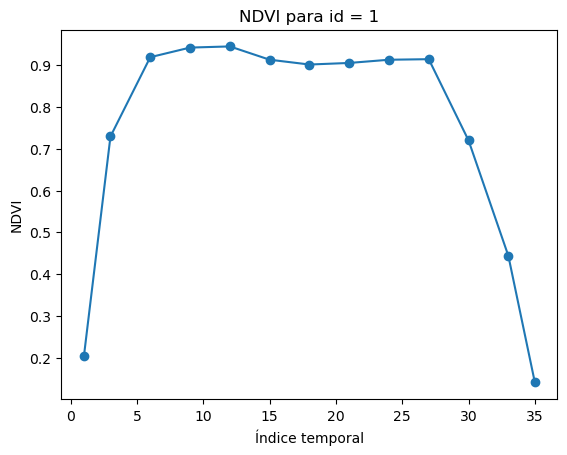

In [7]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Arroto2020[Arroto2020['id'] ==2000].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Arroto2020.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()


In [11]:
import geopandas as gpd

# Cargar el shapefile
Arroto2020_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\arroto_2020\Clean_Data2020/Puntos_Yield_Arroto2020_Final.shp")
Arroto2020_SHP = Arroto2020_SHP.drop(columns= 'geometry', axis=1)
Arroto2020_SHP

,value,id
0,18.835632,1
1,20.428005,2
2,18.750744,3
3,17.476028,4
4,16.053772,5
...,...,...
2183,23.169504,2184
2184,22.640181,2185
2185,22.664206,2186
2186,21.228947,2187


In [12]:
coe_Arroto2020 = (7.0144040920310315 / 10) * 14

In [13]:
coe_Arroto2020 

9.820165728843444

In [14]:
Arroto2020_SHP['biomasa'] = Arroto2020_SHP['value'] * coe_Arroto2020

In [15]:
Arroto2020_SHP = Arroto2020_SHP.drop('value', axis=1)
Arroto2020_SHP

,id,biomasa
0,1,184.969031
1,2,200.606397
2,3,184.135412
3,4,171.617496
4,5,157.650701
...,...,...
2183,2184,227.528371
2184,2185,222.330326
2185,2186,222.566255
2186,2187,208.471775


In [21]:
(Arroto2020_SHP['biomasa'].sum() / 1000) / 22


17.29704036502212

In [22]:
Arroto2020 = pd.merge(Arroto2020, Arroto2020_SHP, on='id', how='inner')
Arroto2020

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-05-29,0.403660,0.863289,0.243832,0.372619,0.331661,2020-06-20,0.708623,0.551990,...,0.270348,0.409969,0.124428,2020-11-17,0.371075,2.088133,0.122274,0.210416,0.123826,184.969031
1,2,2020-05-29,0.409827,0.909288,0.255737,0.384997,0.318924,2020-06-20,0.721810,0.530257,...,0.282731,0.423197,0.122831,2020-11-17,0.344917,2.088687,0.113747,0.186658,0.102002,200.606397
2,3,2020-05-29,0.374150,0.955743,0.232308,0.335096,0.284215,2020-06-20,0.704790,0.540099,...,0.286257,0.422815,0.114455,2020-11-17,0.337024,2.064182,0.119567,0.188923,0.097692,184.135412
3,4,2020-05-29,0.386242,0.947306,0.241362,0.361014,0.312075,2020-06-20,0.707925,0.567421,...,0.245553,0.377619,0.123177,2020-11-17,0.357292,2.061155,0.072358,0.182626,0.206533,171.617496
4,5,2020-05-29,0.413170,0.962560,0.233826,0.387709,0.359420,2020-06-20,0.696555,0.576579,...,0.237984,0.374255,0.133900,2020-11-17,0.364026,1.996360,0.088225,0.185796,0.164812,157.650701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2020-05-29,0.348708,1.016069,0.191970,0.306243,0.350714,2020-06-20,0.654425,0.643490,...,0.256967,0.441238,0.189442,2020-11-17,0.302472,1.853614,0.102990,0.173767,0.137519,227.528371
2184,2185,2020-05-29,0.378896,0.991283,0.212933,0.342861,0.351825,2020-06-20,0.649739,0.623396,...,0.276163,0.459798,0.178398,2020-11-17,0.327204,1.842169,0.099884,0.173975,0.128677,222.330326
2185,2186,2020-05-29,0.396058,1.010923,0.208017,0.346095,0.353222,2020-06-20,0.639223,0.637748,...,0.290660,0.497300,0.188481,2020-11-17,0.332799,1.829122,0.097754,0.181657,0.155223,222.566255
2186,2187,2020-05-29,0.386847,1.023193,0.192935,0.345688,0.401979,2020-06-20,0.629497,0.661964,...,0.300965,0.504088,0.183336,2020-11-17,0.332266,1.841742,0.094675,0.180223,0.161663,208.471775


### LST

In [25]:
LST_Arroto2020 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Arroto2020_2.csv')
LST_Arroto2020 = LST_Arroto2020.drop(columns=['geo','lon','lat'], axis=1)
LST_Arroto2020

,id,date,LST
0,1,2020-06-01,24.689748
1,2,2020-06-01,25.229318
2,3,2020-06-01,25.229318
3,4,2020-06-01,25.229318
4,5,2020-06-01,25.746245
...,...,...,...
43755,2184,2020-10-07,19.182884
43756,2185,2020-10-07,19.182884
43757,2186,2020-10-07,19.182884
43758,2187,2020-10-07,19.822461


In [27]:
import numpy as np
import pandas as pd

df = LST_Arroto2020

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Arroto2020 = pd.DataFrame(rows_final)


In [28]:
LST_Arroto2020

,id,date_1,LST_1,date_2,LST_2,date_3,LST_3,date_4,LST_4,date_5,...,date_16,LST_16,date_17,LST_17,date_18,LST_18,date_19,LST_19,date_20,LST_20
0,1,2020-06-01,24.689748,2020-06-09,19.737405,2020-06-16,19.505084,2020-07-03,20.049716,2020-07-10,...,2020-09-05,22.782444,2020-09-13,24.032331,2020-09-28,12.758708,2020-09-29,19.240086,2020-10-07,18.876623
1,2,2020-06-01,25.229318,2020-06-09,20.377030,2020-06-16,20.178973,2020-07-03,20.531702,2020-07-10,...,2020-09-05,22.770131,2020-09-13,24.131989,2020-09-28,12.758708,2020-09-29,19.328669,2020-10-07,18.902985
2,3,2020-06-01,25.229318,2020-06-09,20.377030,2020-06-16,20.178973,2020-07-03,20.531702,2020-07-10,...,2020-09-05,22.755709,2020-09-13,24.131989,2020-09-28,12.758708,2020-09-29,19.328669,2020-10-07,18.902985
3,4,2020-06-01,25.229318,2020-06-09,20.377030,2020-06-16,20.178973,2020-07-03,20.531702,2020-07-10,...,2020-09-05,22.753755,2020-09-13,24.131989,2020-09-28,12.737377,2020-09-29,19.328669,2020-10-07,18.902985
4,5,2020-06-01,25.746245,2020-06-09,21.030291,2020-06-16,21.139827,2020-07-03,21.103983,2020-07-10,...,2020-09-05,22.759449,2020-09-13,24.220008,2020-09-28,12.682728,2020-09-29,19.409395,2020-10-07,18.968955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2020-06-01,27.215112,2020-06-09,19.614016,2020-06-16,22.166839,2020-07-03,22.169085,2020-07-10,...,2020-09-05,23.225474,2020-09-13,24.494028,2020-09-28,13.987514,2020-09-29,19.842673,2020-10-07,19.182884
2184,2185,2020-06-01,27.215112,2020-06-09,19.614016,2020-06-16,22.205432,2020-07-03,22.169085,2020-07-10,...,2020-09-05,23.225474,2020-09-13,24.494028,2020-09-28,13.739250,2020-09-29,19.842673,2020-10-07,19.182884
2185,2186,2020-06-01,27.215112,2020-06-09,19.614016,2020-06-16,22.205432,2020-07-03,22.169085,2020-07-10,...,2020-09-05,23.225474,2020-09-13,24.494028,2020-09-28,13.739250,2020-09-29,19.842673,2020-10-07,19.182884
2186,2187,2020-06-01,27.389739,2020-06-09,19.821093,2020-06-16,22.305719,2020-07-03,22.209275,2020-07-10,...,2020-09-05,23.299734,2020-09-13,24.647330,2020-09-28,13.812216,2020-09-29,19.964782,2020-10-07,19.822461


In [29]:
LST_Arroto2020 = pd.merge(LST_Arroto2020, Arroto2020, on='id', how='inner')
LST_Arroto2020

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-01,24.689748,2020-06-09,19.737405,2020-06-16,19.505084,2020-07-03,20.049716,2020-07-10,...,0.270348,0.409969,0.124428,2020-11-17,0.371075,2.088133,0.122274,0.210416,0.123826,184.969031
1,2,2020-06-01,25.229318,2020-06-09,20.377030,2020-06-16,20.178973,2020-07-03,20.531702,2020-07-10,...,0.282731,0.423197,0.122831,2020-11-17,0.344917,2.088687,0.113747,0.186658,0.102002,200.606397
2,3,2020-06-01,25.229318,2020-06-09,20.377030,2020-06-16,20.178973,2020-07-03,20.531702,2020-07-10,...,0.286257,0.422815,0.114455,2020-11-17,0.337024,2.064182,0.119567,0.188923,0.097692,184.135412
3,4,2020-06-01,25.229318,2020-06-09,20.377030,2020-06-16,20.178973,2020-07-03,20.531702,2020-07-10,...,0.245553,0.377619,0.123177,2020-11-17,0.357292,2.061155,0.072358,0.182626,0.206533,171.617496
4,5,2020-06-01,25.746245,2020-06-09,21.030291,2020-06-16,21.139827,2020-07-03,21.103983,2020-07-10,...,0.237984,0.374255,0.133900,2020-11-17,0.364026,1.996360,0.088225,0.185796,0.164812,157.650701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2020-06-01,27.215112,2020-06-09,19.614016,2020-06-16,22.166839,2020-07-03,22.169085,2020-07-10,...,0.256967,0.441238,0.189442,2020-11-17,0.302472,1.853614,0.102990,0.173767,0.137519,227.528371
2184,2185,2020-06-01,27.215112,2020-06-09,19.614016,2020-06-16,22.205432,2020-07-03,22.169085,2020-07-10,...,0.276163,0.459798,0.178398,2020-11-17,0.327204,1.842169,0.099884,0.173975,0.128677,222.330326
2185,2186,2020-06-01,27.215112,2020-06-09,19.614016,2020-06-16,22.205432,2020-07-03,22.169085,2020-07-10,...,0.290660,0.497300,0.188481,2020-11-17,0.332799,1.829122,0.097754,0.181657,0.155223,222.566255
2186,2187,2020-06-01,27.389739,2020-06-09,19.821093,2020-06-16,22.305719,2020-07-03,22.209275,2020-07-10,...,0.300965,0.504088,0.183336,2020-11-17,0.332266,1.841742,0.094675,0.180223,0.161663,208.471775


## Arroto 2021

In [30]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Arroto2021.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Arroto2021 = pd.DataFrame(rows_final)



In [31]:
Arroto2021

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2021-06-05,0.398679,0.988798,0.241752,0.331279,0.234491,2021-06-10,0.503015,0.865226,...,0.982060,0.324457,0.479803,0.132973,2021-11-10,0.542787,1.443736,0.158770,0.308105,0.166658
1,2,2021-06-05,0.386089,1.007290,0.221182,0.315973,0.262615,2021-06-10,0.489544,0.865348,...,1.083305,0.294220,0.422825,0.107201,2021-11-10,0.526567,1.430157,0.201445,0.286522,0.055976
2,3,2021-06-05,0.373836,1.045499,0.203406,0.305955,0.296815,2021-06-10,0.497490,0.924545,...,1.091338,0.290842,0.412185,0.103029,2021-11-10,0.519859,1.436469,0.199331,0.277259,0.042988
3,4,2021-06-05,0.368782,1.055467,0.211915,0.309386,0.278834,2021-06-10,0.496823,0.882744,...,1.190221,0.251595,0.387510,0.127526,2021-11-10,0.485816,1.509366,0.163616,0.252331,0.078410
4,5,2021-06-05,0.361481,1.086132,0.198198,0.311622,0.331748,2021-06-10,0.485815,0.909671,...,1.194348,0.249973,0.384874,0.123091,2021-11-10,0.452934,1.533675,0.155831,0.264035,0.138200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2021-06-05,0.295961,1.148113,0.149877,0.212282,0.228086,2021-06-10,0.361579,1.016825,...,1.187927,0.252752,0.410927,0.163972,2021-11-10,0.528704,1.478298,0.196233,0.307190,0.109350
2184,2185,2021-06-05,0.317473,1.088711,0.176184,0.238270,0.207364,2021-06-10,0.390178,0.975446,...,1.214477,0.255799,0.390516,0.132739,2021-11-10,0.520534,1.511858,0.188879,0.290999,0.094991
2185,2186,2021-06-05,0.350489,1.087832,0.174017,0.277545,0.337420,2021-06-10,0.417559,0.989301,...,1.190656,0.269775,0.407476,0.127133,2021-11-10,0.507161,1.494816,0.197311,0.287005,0.077204
2186,2187,2021-06-05,0.364656,1.075802,0.167523,0.300432,0.419226,2021-06-10,0.406662,0.982409,...,1.196277,0.270935,0.419893,0.143417,2021-11-10,0.525549,1.481730,0.204198,0.285811,0.052473


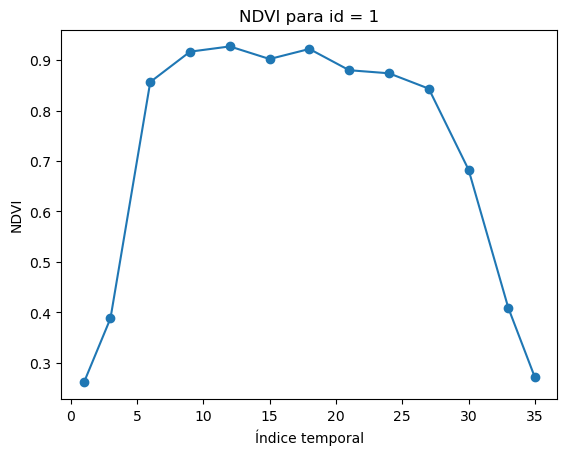

In [32]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Arroto2021[Arroto2021['id'] ==2000].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Arroto2021.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()


In [33]:
import geopandas as gpd

# Cargar el shapefile
Arroto2021_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\arroto_2021\Clean_Data2021/Puntos_Yield_Arroto2021_Final.shp")
Arroto2021_SHP = Arroto2021_SHP.drop(columns= 'geometry', axis=1)
Arroto2021_SHP

,id,value
0,1,15.670194
1,2,16.367364
2,3,15.786523
3,4,15.914178
4,5,15.475581
...,...,...
2183,2184,15.503592
2184,2185,16.209615
2185,2186,16.513622
2186,2187,16.276708


In [34]:
coe_Arroto2021 = (7.0144040920310315 / 10) * 14

In [35]:
coe_Arroto2021

9.820165728843444

In [39]:
Arroto2021_SHP['biomasa'] = Arroto2021_SHP['value'] * coe_Arroto2021
Arroto2021_SHP = Arroto2021_SHP.drop('value', axis=1)
Arroto2021_SHP

,id,biomasa
0,1,153.883902
1,2,160.730227
2,3,155.026272
3,4,156.279865
4,5,151.972770
...,...,...
2183,2184,152.247843
2184,2185,159.181106
2185,2186,162.166505
2186,2187,159.839970


In [40]:
Arroto2021 = pd.merge(Arroto2021, Arroto2021_SHP, on='id', how='inner')
Arroto2021

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2021-06-05,0.398679,0.988798,0.241752,0.331279,0.234491,2021-06-10,0.503015,0.865226,...,0.324457,0.479803,0.132973,2021-11-10,0.542787,1.443736,0.158770,0.308105,0.166658,153.883902
1,2,2021-06-05,0.386089,1.007290,0.221182,0.315973,0.262615,2021-06-10,0.489544,0.865348,...,0.294220,0.422825,0.107201,2021-11-10,0.526567,1.430157,0.201445,0.286522,0.055976,160.730227
2,3,2021-06-05,0.373836,1.045499,0.203406,0.305955,0.296815,2021-06-10,0.497490,0.924545,...,0.290842,0.412185,0.103029,2021-11-10,0.519859,1.436469,0.199331,0.277259,0.042988,155.026272
3,4,2021-06-05,0.368782,1.055467,0.211915,0.309386,0.278834,2021-06-10,0.496823,0.882744,...,0.251595,0.387510,0.127526,2021-11-10,0.485816,1.509366,0.163616,0.252331,0.078410,156.279865
4,5,2021-06-05,0.361481,1.086132,0.198198,0.311622,0.331748,2021-06-10,0.485815,0.909671,...,0.249973,0.384874,0.123091,2021-11-10,0.452934,1.533675,0.155831,0.264035,0.138200,151.972770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2021-06-05,0.295961,1.148113,0.149877,0.212282,0.228086,2021-06-10,0.361579,1.016825,...,0.252752,0.410927,0.163972,2021-11-10,0.528704,1.478298,0.196233,0.307190,0.109350,152.247843
2184,2185,2021-06-05,0.317473,1.088711,0.176184,0.238270,0.207364,2021-06-10,0.390178,0.975446,...,0.255799,0.390516,0.132739,2021-11-10,0.520534,1.511858,0.188879,0.290999,0.094991,159.181106
2185,2186,2021-06-05,0.350489,1.087832,0.174017,0.277545,0.337420,2021-06-10,0.417559,0.989301,...,0.269775,0.407476,0.127133,2021-11-10,0.507161,1.494816,0.197311,0.287005,0.077204,162.166505
2186,2187,2021-06-05,0.364656,1.075802,0.167523,0.300432,0.419226,2021-06-10,0.406662,0.982409,...,0.270935,0.419893,0.143417,2021-11-10,0.525549,1.481730,0.204198,0.285811,0.052473,159.839970


### LST

In [42]:
LST_Arroto2021 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Arroto2021_2.csv')
LST_Arroto2021 = LST_Arroto2021.drop(columns=['geo','lon','lat'], axis=1)
LST_Arroto2021

,id,date,LST
0,1,2021-06-03,26.048532
1,2,2021-06-03,27.210853
2,3,2021-06-03,27.210853
3,4,2021-06-03,27.210853
4,5,2021-06-03,28.755249
...,...,...,...
43755,2184,2021-11-22,9.015700
43756,2185,2021-11-22,9.212235
43757,2186,2021-11-22,9.212235
43758,2187,2021-11-22,9.260509


In [43]:
import numpy as np
import pandas as pd

df = LST_Arroto2021

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Arroto2021 = pd.DataFrame(rows_final)

In [44]:
LST_Arroto2021 = pd.merge(LST_Arroto2021, Arroto2021, on='id', how='inner')
LST_Arroto2021

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2021-06-03,26.048532,2021-06-12,27.165201,2021-07-05,22.955753,2021-07-13,17.378374,2021-07-21,...,0.324457,0.479803,0.132973,2021-11-10,0.542787,1.443736,0.158770,0.308105,0.166658,153.883902
1,2,2021-06-03,27.210853,2021-06-12,27.758890,2021-07-05,23.306435,2021-07-13,17.905926,2021-07-21,...,0.294220,0.422825,0.107201,2021-11-10,0.526567,1.430157,0.201445,0.286522,0.055976,160.730227
2,3,2021-06-03,27.210853,2021-06-12,27.758890,2021-07-05,23.306435,2021-07-13,17.905926,2021-07-21,...,0.290842,0.412185,0.103029,2021-11-10,0.519859,1.436469,0.199331,0.277259,0.042988,155.026272
3,4,2021-06-03,27.210853,2021-06-12,27.758890,2021-07-05,23.306435,2021-07-13,17.905926,2021-07-21,...,0.251595,0.387510,0.127526,2021-11-10,0.485816,1.509366,0.163616,0.252331,0.078410,156.279865
4,5,2021-06-03,28.755249,2021-06-12,28.434512,2021-07-05,24.132758,2021-07-13,19.654161,2021-07-21,...,0.249973,0.384874,0.123091,2021-11-10,0.452934,1.533675,0.155831,0.264035,0.138200,151.972770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2021-06-03,26.765151,2021-06-12,27.175069,2021-07-05,24.240242,2021-07-13,18.068745,2021-07-21,...,0.252752,0.410927,0.163972,2021-11-10,0.528704,1.478298,0.196233,0.307190,0.109350,152.247843
2184,2185,2021-06-03,26.927450,2021-06-12,27.175069,2021-07-05,24.281290,2021-07-13,19.242131,2021-07-21,...,0.255799,0.390516,0.132739,2021-11-10,0.520534,1.511858,0.188879,0.290999,0.094991,159.181106
2185,2186,2021-06-03,26.927450,2021-06-12,27.175069,2021-07-05,24.281290,2021-07-13,19.242131,2021-07-21,...,0.269775,0.407476,0.127133,2021-11-10,0.507161,1.494816,0.197311,0.287005,0.077204,162.166505
2186,2187,2021-06-03,26.858454,2021-06-12,27.538503,2021-07-05,24.329456,2021-07-13,19.255308,2021-07-21,...,0.270935,0.419893,0.143417,2021-11-10,0.525549,1.481730,0.204198,0.285811,0.052473,159.839970


## Arroto 2022

In [46]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Arroto2022.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Arroto2022 = pd.DataFrame(rows_final)



In [47]:
Arroto2022

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2022-05-29,0.434350,0.955461,0.266350,0.373290,0.214739,2022-06-05,0.511250,0.835396,...,1.204951,0.224961,0.336635,0.158076,2022-10-08,0.493990,1.372043,0.235449,0.327329,0.095896
1,2,2022-05-29,0.442841,1.011155,0.257647,0.395827,0.266960,2022-06-05,0.532373,0.839172,...,1.257831,0.203521,0.300940,0.139204,2022-10-08,0.480787,1.456069,0.211086,0.296767,0.085712
2,3,2022-05-29,0.444387,1.053054,0.238597,0.393525,0.293405,2022-06-05,0.524667,0.842835,...,1.227410,0.215226,0.302845,0.120117,2022-10-08,0.475710,1.475362,0.204789,0.289203,0.084388
3,4,2022-05-29,0.435538,1.061461,0.257046,0.380800,0.235434,2022-06-05,0.517269,0.871795,...,1.304340,0.175202,0.291999,0.192252,2022-10-08,0.456644,1.596171,0.152568,0.276763,0.177166
4,5,2022-05-29,0.441751,1.089962,0.244632,0.386328,0.262169,2022-06-05,0.510733,0.893298,...,1.315480,0.171077,0.281642,0.179227,2022-10-08,0.442517,1.630620,0.142124,0.267598,0.189480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2022-05-29,0.400284,1.205651,0.186143,0.338535,0.340350,2022-06-05,0.451885,1.016937,...,1.315444,0.170887,0.287541,0.201488,2022-10-08,0.447651,1.523651,0.147214,0.255152,0.162799
2184,2185,2022-05-29,0.364856,1.236332,0.172786,0.284674,0.292788,2022-06-05,0.427523,1.055185,...,1.360764,0.155353,0.283481,0.230451,2022-10-08,0.461691,1.553356,0.139397,0.235324,0.119023
2185,2186,2022-05-29,0.384037,1.215732,0.175839,0.293817,0.293814,2022-06-05,0.434713,1.073089,...,1.339482,0.163294,0.274227,0.191500,2022-10-08,0.465906,1.482582,0.163428,0.260168,0.118065
2186,2187,2022-05-29,0.376543,1.246139,0.158860,0.300924,0.366501,2022-06-05,0.419368,1.094542,...,1.335260,0.169797,0.266626,0.158579,2022-10-08,0.468857,1.521701,0.146775,0.264632,0.159083


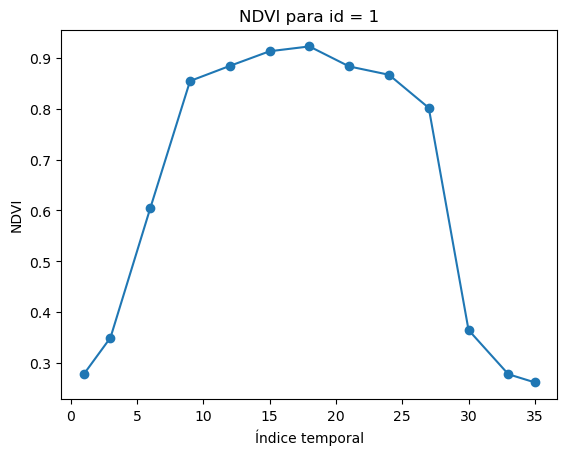

In [48]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Arroto2022[Arroto2022['id'] ==2000].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Arroto2022.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()


In [51]:
import geopandas as gpd

# Cargar el shapefile
Arroto2022_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\arroto_2022\Clean_Data2022/Puntos_Yield_Arroto2022_Final.shp")
Arroto2022_SHP = Arroto2022_SHP.drop(columns= 'geometry', axis=1)
Arroto2022_SHP

,id,value
0,1,14.368873
1,2,18.458905
2,3,18.526195
3,4,16.288725
4,5,14.319710
...,...,...
2183,2184,14.482727
2184,2185,11.466756
2185,2186,15.142337
2186,2187,15.481573


In [53]:
coe_Arroto2022 = (6.458324146371761 / 10) * 14

In [57]:
coe_Arroto2022

9.041653804920465

In [60]:
Arroto2022_SHP['biomasa'] = Arroto2022_SHP['value'] * coe_Arroto2022
Arroto2022_SHP = Arroto2022_SHP.drop('value', axis=1)
Arroto2022_SHP

,id,biomasa
0,1,129.918375
1,2,166.899029
2,3,167.507442
3,4,147.277012
4,5,129.473860
...,...,...
2183,2184,130.947804
2184,2185,103.678438
2185,2186,136.911769
2186,2187,139.979023


In [62]:
Arroto2022 = pd.merge(Arroto2022, Arroto2022_SHP, on='id', how='inner')
Arroto2022

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2022-05-29,0.434350,0.955461,0.266350,0.373290,0.214739,2022-06-05,0.511250,0.835396,...,0.224961,0.336635,0.158076,2022-10-08,0.493990,1.372043,0.235449,0.327329,0.095896,129.918375
1,2,2022-05-29,0.442841,1.011155,0.257647,0.395827,0.266960,2022-06-05,0.532373,0.839172,...,0.203521,0.300940,0.139204,2022-10-08,0.480787,1.456069,0.211086,0.296767,0.085712,166.899029
2,3,2022-05-29,0.444387,1.053054,0.238597,0.393525,0.293405,2022-06-05,0.524667,0.842835,...,0.215226,0.302845,0.120117,2022-10-08,0.475710,1.475362,0.204789,0.289203,0.084388,167.507442
3,4,2022-05-29,0.435538,1.061461,0.257046,0.380800,0.235434,2022-06-05,0.517269,0.871795,...,0.175202,0.291999,0.192252,2022-10-08,0.456644,1.596171,0.152568,0.276763,0.177166,147.277012
4,5,2022-05-29,0.441751,1.089962,0.244632,0.386328,0.262169,2022-06-05,0.510733,0.893298,...,0.171077,0.281642,0.179227,2022-10-08,0.442517,1.630620,0.142124,0.267598,0.189480,129.473860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2022-05-29,0.400284,1.205651,0.186143,0.338535,0.340350,2022-06-05,0.451885,1.016937,...,0.170887,0.287541,0.201488,2022-10-08,0.447651,1.523651,0.147214,0.255152,0.162799,130.947804
2184,2185,2022-05-29,0.364856,1.236332,0.172786,0.284674,0.292788,2022-06-05,0.427523,1.055185,...,0.155353,0.283481,0.230451,2022-10-08,0.461691,1.553356,0.139397,0.235324,0.119023,103.678438
2185,2186,2022-05-29,0.384037,1.215732,0.175839,0.293817,0.293814,2022-06-05,0.434713,1.073089,...,0.163294,0.274227,0.191500,2022-10-08,0.465906,1.482582,0.163428,0.260168,0.118065,136.911769
2186,2187,2022-05-29,0.376543,1.246139,0.158860,0.300924,0.366501,2022-06-05,0.419368,1.094542,...,0.169797,0.266626,0.158579,2022-10-08,0.468857,1.521701,0.146775,0.264632,0.159083,139.979023


### LST

In [64]:
LST_Arroto2022 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Arroto2022_2.csv')
LST_Arroto2022 = LST_Arroto2022.drop(columns=['.geo'], axis=1)
LST_Arroto2022

,id,date,LST
0,1,2022-06-07,20.885376
1,2,2022-06-07,21.444630
2,3,2022-06-07,21.444630
3,4,2022-06-07,21.444630
4,5,2022-06-07,21.936405
...,...,...,...
43755,2184,2022-10-04,23.914853
43756,2185,2022-10-04,23.983430
43757,2186,2022-10-04,23.983430
43758,2187,2022-10-04,24.047669


In [65]:
import numpy as np
import pandas as pd

df = LST_Arroto2022

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Arroto2022 = pd.DataFrame(rows_final)

In [67]:
LST_Arroto2022 = pd.merge(LST_Arroto2022, Arroto2022, on='id', how='inner')
LST_Arroto2022

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2022-06-07,20.885376,2022-06-15,23.496471,2022-06-30,20.717888,2022-07-01,23.057368,2022-07-09,...,0.224961,0.336635,0.158076,2022-10-08,0.493990,1.372043,0.235449,0.327329,0.095896,129.918375
1,2,2022-06-07,21.444630,2022-06-15,23.648327,2022-06-30,20.951857,2022-07-01,23.313407,2022-07-09,...,0.203521,0.300940,0.139204,2022-10-08,0.480787,1.456069,0.211086,0.296767,0.085712,166.899029
2,3,2022-06-07,21.444630,2022-06-15,23.648327,2022-06-30,20.951857,2022-07-01,23.313407,2022-07-09,...,0.215226,0.302845,0.120117,2022-10-08,0.475710,1.475362,0.204789,0.289203,0.084388,167.507442
3,4,2022-06-07,21.444630,2022-06-15,23.648327,2022-06-30,20.951857,2022-07-01,23.313407,2022-07-09,...,0.175202,0.291999,0.192252,2022-10-08,0.456644,1.596171,0.152568,0.276763,0.177166,147.277012
4,5,2022-06-07,21.936405,2022-06-15,24.695793,2022-06-30,21.552394,2022-07-01,23.504284,2022-07-09,...,0.171077,0.281642,0.179227,2022-10-08,0.442517,1.630620,0.142124,0.267598,0.189480,129.473860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2022-06-07,22.362481,2022-06-15,25.855191,2022-06-30,21.400822,2022-07-01,23.959951,2022-07-09,...,0.170887,0.287541,0.201488,2022-10-08,0.447651,1.523651,0.147214,0.255152,0.162799,130.947804
2184,2185,2022-06-07,22.362481,2022-06-15,25.875831,2022-06-30,21.410242,2022-07-01,23.959951,2022-07-09,...,0.155353,0.283481,0.230451,2022-10-08,0.461691,1.553356,0.139397,0.235324,0.119023,103.678438
2185,2186,2022-06-07,22.362481,2022-06-15,25.875831,2022-06-30,21.410242,2022-07-01,23.959951,2022-07-09,...,0.163294,0.274227,0.191500,2022-10-08,0.465906,1.482582,0.163428,0.260168,0.118065,136.911769
2186,2187,2022-06-07,22.512415,2022-06-15,25.780273,2022-06-30,21.447275,2022-07-01,23.945649,2022-07-09,...,0.169797,0.266626,0.158579,2022-10-08,0.468857,1.521701,0.146775,0.264632,0.159083,139.979023


## Arroto Final

In [68]:
Arroto = pd.concat([Arroto2020, Arroto2021, Arroto2022])
Arroto

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-05-29,0.403660,0.863289,0.243832,0.372619,0.331661,2020-06-20,0.708623,0.551990,...,0.270348,0.409969,0.124428,2020-11-17,0.371075,2.088133,0.122274,0.210416,0.123826,184.969031
1,2,2020-05-29,0.409827,0.909288,0.255737,0.384997,0.318924,2020-06-20,0.721810,0.530257,...,0.282731,0.423197,0.122831,2020-11-17,0.344917,2.088687,0.113747,0.186658,0.102002,200.606397
2,3,2020-05-29,0.374150,0.955743,0.232308,0.335096,0.284215,2020-06-20,0.704790,0.540099,...,0.286257,0.422815,0.114455,2020-11-17,0.337024,2.064182,0.119567,0.188923,0.097692,184.135412
3,4,2020-05-29,0.386242,0.947306,0.241362,0.361014,0.312075,2020-06-20,0.707925,0.567421,...,0.245553,0.377619,0.123177,2020-11-17,0.357292,2.061155,0.072358,0.182626,0.206533,171.617496
4,5,2020-05-29,0.413170,0.962560,0.233826,0.387709,0.359420,2020-06-20,0.696555,0.576579,...,0.237984,0.374255,0.133900,2020-11-17,0.364026,1.996360,0.088225,0.185796,0.164812,157.650701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2022-05-29,0.400284,1.205651,0.186143,0.338535,0.340350,2022-06-05,0.451885,1.016937,...,0.170887,0.287541,0.201488,2022-10-08,0.447651,1.523651,0.147214,0.255152,0.162799,130.947804
2184,2185,2022-05-29,0.364856,1.236332,0.172786,0.284674,0.292788,2022-06-05,0.427523,1.055185,...,0.155353,0.283481,0.230451,2022-10-08,0.461691,1.553356,0.139397,0.235324,0.119023,103.678438
2185,2186,2022-05-29,0.384037,1.215732,0.175839,0.293817,0.293814,2022-06-05,0.434713,1.073089,...,0.163294,0.274227,0.191500,2022-10-08,0.465906,1.482582,0.163428,0.260168,0.118065,136.911769
2186,2187,2022-05-29,0.376543,1.246139,0.158860,0.300924,0.366501,2022-06-05,0.419368,1.094542,...,0.169797,0.266626,0.158579,2022-10-08,0.468857,1.521701,0.146775,0.264632,0.159083,139.979023


In [71]:
cols_to_drop = [c for c in Arroto.columns if c.startswith('date_')]
Arroto = Arroto.drop(cols_to_drop, axis=1)


In [72]:
Arroto

,id,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,GNDVI_3,MSI_3,NDRE_3,NDVI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,0.403660,0.863289,0.243832,0.372619,0.331661,0.708623,0.551990,0.596162,0.776875,...,1.179469,0.270348,0.409969,0.124428,0.371075,2.088133,0.122274,0.210416,0.123826,184.969031
1,2,0.409827,0.909288,0.255737,0.384997,0.318924,0.721810,0.530257,0.615556,0.777448,...,1.172969,0.282731,0.423197,0.122831,0.344917,2.088687,0.113747,0.186658,0.102002,200.606397
2,3,0.374150,0.955743,0.232308,0.335096,0.284215,0.704790,0.540099,0.609813,0.786600,...,1.164003,0.286257,0.422815,0.114455,0.337024,2.064182,0.119567,0.188923,0.097692,184.135412
3,4,0.386242,0.947306,0.241362,0.361014,0.312075,0.707925,0.567421,0.589571,0.779416,...,1.262611,0.245553,0.377619,0.123177,0.357292,2.061155,0.072358,0.182626,0.206533,171.617496
4,5,0.413170,0.962560,0.233826,0.387709,0.359420,0.696555,0.576579,0.584324,0.764706,...,1.283076,0.237984,0.374255,0.133900,0.364026,1.996360,0.088225,0.185796,0.164812,157.650701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,0.400284,1.205651,0.186143,0.338535,0.340350,0.451885,1.016937,0.247642,0.401746,...,1.315444,0.170887,0.287541,0.201488,0.447651,1.523651,0.147214,0.255152,0.162799,130.947804
2184,2185,0.364856,1.236332,0.172786,0.284674,0.292788,0.427523,1.055185,0.229744,0.375263,...,1.360764,0.155353,0.283481,0.230451,0.461691,1.553356,0.139397,0.235324,0.119023,103.678438
2185,2186,0.384037,1.215732,0.175839,0.293817,0.293814,0.434713,1.073089,0.219500,0.398199,...,1.339482,0.163294,0.274227,0.191500,0.465906,1.482582,0.163428,0.260168,0.118065,136.911769
2186,2187,0.376543,1.246139,0.158860,0.300924,0.366501,0.419368,1.094542,0.206147,0.380357,...,1.335260,0.169797,0.266626,0.158579,0.468857,1.521701,0.146775,0.264632,0.159083,139.979023


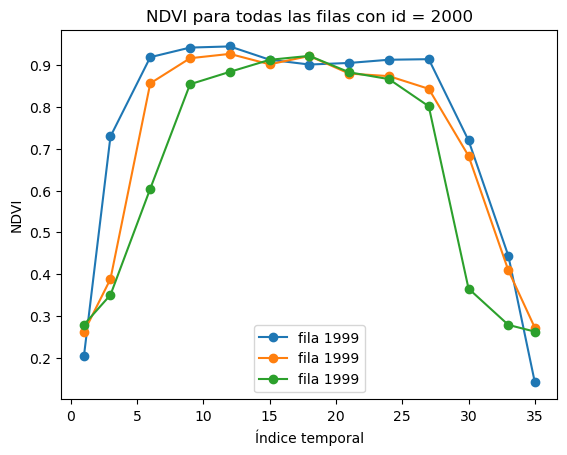

In [73]:
import matplotlib.pyplot as plt

# Filtrar todas las filas con id == 2000
rows = Arroto[Arroto['id'] == 2000]

# Columnas NDVI_*
ndvi_cols = [c for c in Arroto.columns if c.startswith('NDVI_')]
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Eje X = número de NDVI
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Graficar todas las filas
plt.figure()
for idx, row in rows.iterrows():
    ndvi_values = row[ndvi_cols].values
    plt.plot(x, ndvi_values, marker='o', label=f'fila {idx}')

plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para todas las filas con id = 2000')
plt.legend()
plt.show()


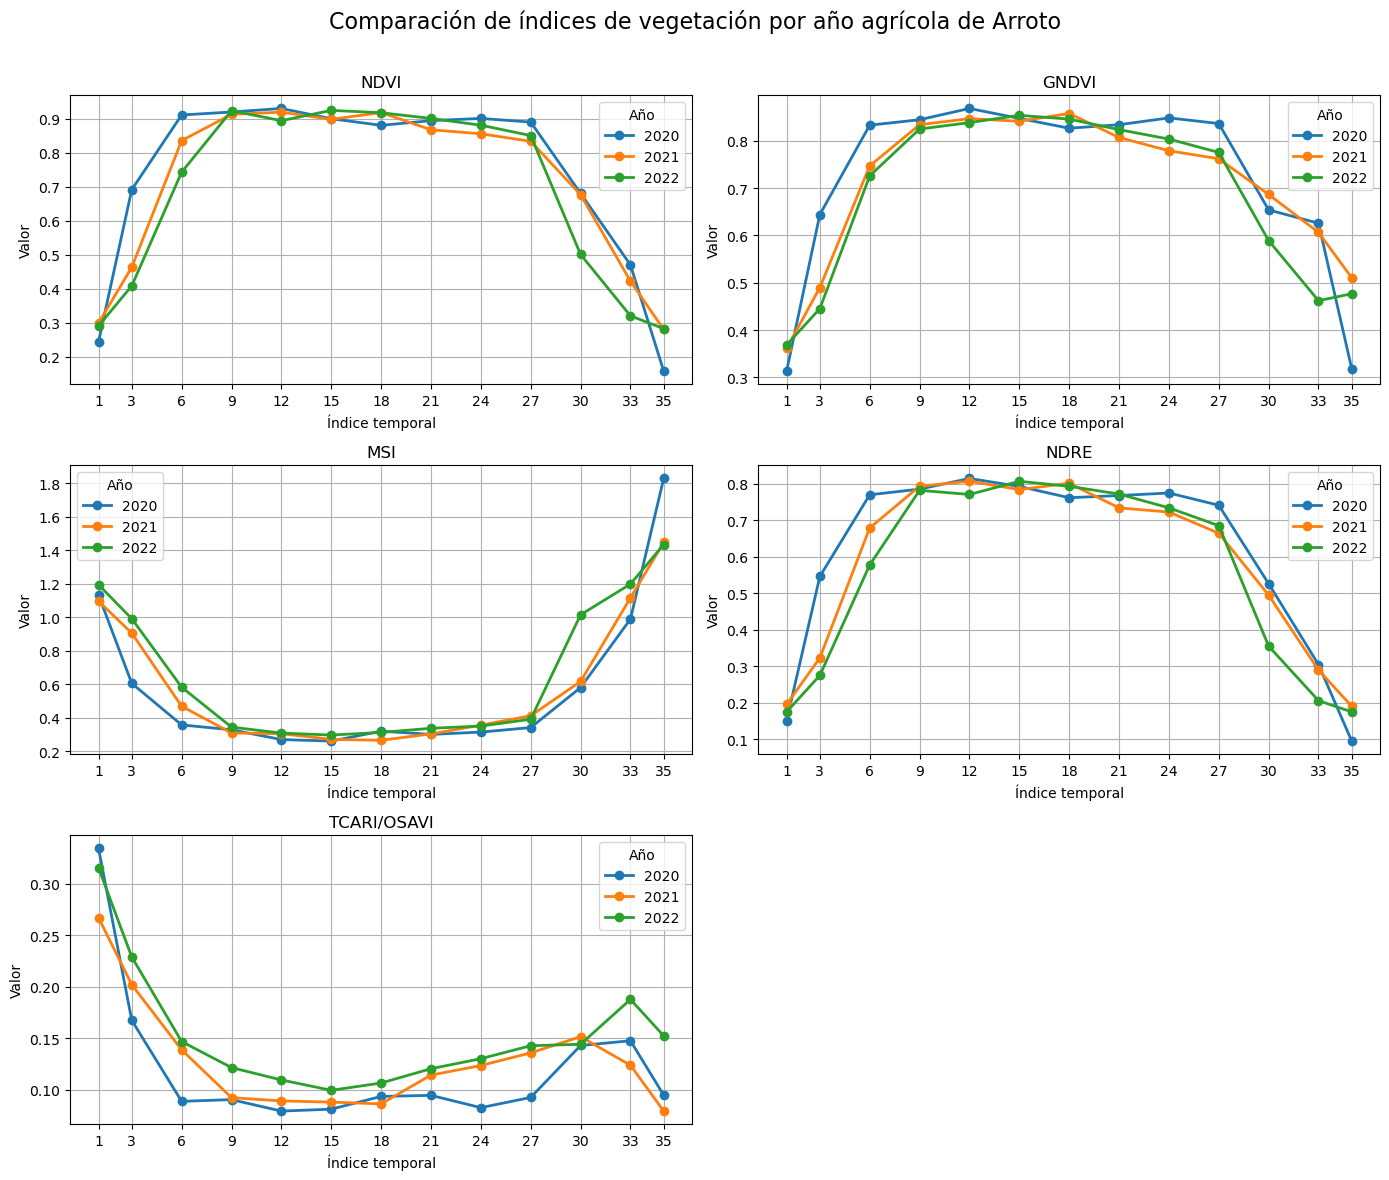

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================

# 2. Reconstruir años
# =========================
n_ids = Arroto["id"].nunique()
years_real = [2020, 2021, 2022]   # ajusta si corresponde
Arroto = Arroto.copy()
Arroto["year"] = np.repeat(years_real, n_ids)

# =========================
# 3. Tiempos
# =========================
times = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

# =========================
# 4. Índices a graficar
# =========================
indices = {
    "NDVI": [f"NDVI_{t}" for t in times],
    "GNDVI": [f"GNDVI_{t}" for t in times],
    "MSI": [f"MSI_{t}" for t in times],
    "NDRE": [f"NDRE_{t}" for t in times],
    "TCARI/OSAVI": [f"TCARIOSAVI_{t}" for t in times]
}

# =========================
# 5. Figura con 5 subgráficas
# =========================
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (indice, cols) in enumerate(indices.items()):
    ax = axes[i]

    for year in years_real:
        data_year = Arroto[Arroto["year"] == year]

        media = data_year[cols].mean().values

        ax.plot(times, media, marker='o', linewidth=2, label=str(year))

    ax.set_title(indice)
    ax.set_xlabel("Índice temporal")
    ax.set_ylabel("Valor")
    ax.set_xticks(times)
    ax.grid(True)
    ax.legend(title="Año")

# Eliminar el sexto subplot vacío
fig.delaxes(axes[5])

fig.suptitle("Comparación de índices de vegetación por año agrícola de Arroto", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])


plt.savefig(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\Figuras\Arroto_Indices.png", dpi=300)
plt.show()

In [122]:
import pandas as pd
import numpy as np

# =========================
# 1. Reconstruir años
# =========================
n_ids = Arroto["id"].nunique()
years_real = [2020, 2021, 2022]
Arroto = Arroto.copy()
Arroto["year"] = np.repeat(years_real, n_ids)

# =========================
# 2. Tiempos
# =========================
times = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

# =========================
# 3. Índices
# =========================
indices = {
    "NDVI": [f"NDVI_{t}" for t in times],
    "GNDVI": [f"GNDVI_{t}" for t in times],
    "MSI": [f"MSI_{t}" for t in times],
    "NDRE": [f"NDRE_{t}" for t in times],
    "TCARIOSAVI": [f"TCARIOSAVI_{t}" for t in times]
}

# =========================
# 4. Extraer series
# =========================
resultados = []

for indice, cols in indices.items():
    for year in years_real:
        data_year = Arroto[Arroto["year"] == year]

        # ESTA es la serie que graficas
        media = data_year[cols].mean().values

        # guardar cada punto temporal
        for t, valor in zip(times, media):
            resultados.append({
                "year": year,
                "indice": indice,
                "tiempo": t,
                "valor": valor
            })

# =========================
# 5. DataFrame final
# =========================
df_series = pd.DataFrame(resultados)

df_series

,year,indice,tiempo,valor
0,2020,NDVI,1,0.244288
1,2020,NDVI,3,0.691568
2,2020,NDVI,6,0.911097
3,2020,NDVI,9,0.919825
4,2020,NDVI,12,0.930240
...,...,...,...,...
190,2022,TCARIOSAVI,24,0.129986
191,2022,TCARIOSAVI,27,0.142577
192,2022,TCARIOSAVI,30,0.143960
193,2022,TCARIOSAVI,33,0.187543


In [128]:
valores_eliminar = [1, 3, 6, 30, 33, 35]

df_filtrado = df_series[~df_series["tiempo"].isin(valores_eliminar)]

In [130]:
df_filtrado

,year,indice,tiempo,valor
3,2020,NDVI,9,0.919825
4,2020,NDVI,12,0.930240
5,2020,NDVI,15,0.900119
6,2020,NDVI,18,0.880616
7,2020,NDVI,21,0.894412
...,...,...,...,...
187,2022,TCARIOSAVI,15,0.099282
188,2022,TCARIOSAVI,18,0.106360
189,2022,TCARIOSAVI,21,0.120239
190,2022,TCARIOSAVI,24,0.129986


In [134]:
resumen = df_filtrado.groupby(["year", "indice"])["valor"].agg(
    mean="mean",
    std="std",
    min="min",
    max="max"
).reset_index()

resumen

,year,indice,mean,std,min,max
0,2020,GNDVI,0.843631,0.013430,0.826545,0.868293
1,2020,MSI,0.305374,0.029939,0.261129,0.341701
2,2020,NDRE,0.776337,0.023587,0.740595,0.814013
3,2020,NDVI,0.902336,0.017193,0.880616,0.930240
4,2020,TCARIOSAVI,0.087533,0.006473,0.079083,0.094377
5,2021,GNDVI,0.818230,0.036455,0.762033,0.857651
6,2021,MSI,0.317752,0.051034,0.266025,0.412184
7,2021,NDRE,0.757581,0.052873,0.664016,0.806381
8,2021,NDVI,0.886551,0.034199,0.833628,0.919349
9,2021,TCARIOSAVI,0.104005,0.020109,0.086088,0.135637


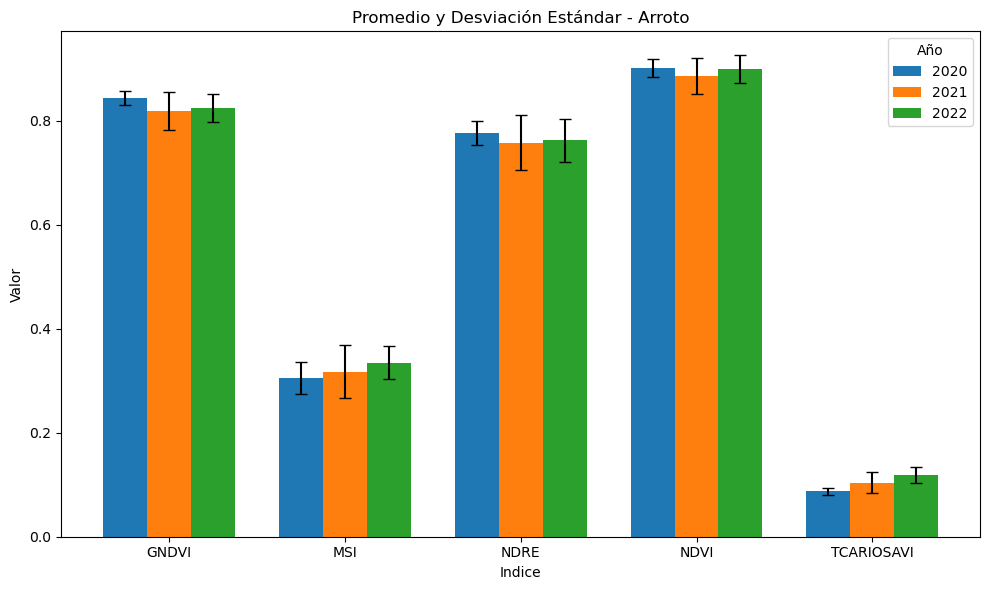

In [172]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

df_mean = resumen.pivot(index="indice", columns="year", values="mean")
df_std = resumen.pivot(index="indice", columns="year", values="std")

x = np.arange(len(df_mean.index))
width = 0.25

for i, year in enumerate(df_mean.columns):
    ax.bar(
        x + i*width,
        df_mean[year],
        width,
        yerr=df_std[year],
        capsize=4,
        label=str(year)
    )

ax.set_xticks(x + width)
ax.set_xticklabels(df_mean.index)
ax.set_ylabel("Valor")
ax.set_xlabel("Indice")
ax.set_title("Promedio y Desviación Estándar - Arroto")
ax.legend(title="Año")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Figuras\Arroto_Metricas.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [136]:
resumen.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Series_Tiempo/Arroto_SerieTiempo.csv', index=False)

In [276]:
Arroto.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/Arroto_BiomasaIV.csv', index=False)

### LST 

In [95]:
LST_Arroto = pd.concat([LST_Arroto2020, LST_Arroto2021, LST_Arroto2022])
LST_Arroto

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-01,24.689748,2020-06-09,19.737405,2020-06-16,19.505084,2020-07-03,20.049716,2020-07-10,...,0.270348,0.409969,0.124428,2020-11-17,0.371075,2.088133,0.122274,0.210416,0.123826,184.969031
1,2,2020-06-01,25.229318,2020-06-09,20.377030,2020-06-16,20.178973,2020-07-03,20.531702,2020-07-10,...,0.282731,0.423197,0.122831,2020-11-17,0.344917,2.088687,0.113747,0.186658,0.102002,200.606397
2,3,2020-06-01,25.229318,2020-06-09,20.377030,2020-06-16,20.178973,2020-07-03,20.531702,2020-07-10,...,0.286257,0.422815,0.114455,2020-11-17,0.337024,2.064182,0.119567,0.188923,0.097692,184.135412
3,4,2020-06-01,25.229318,2020-06-09,20.377030,2020-06-16,20.178973,2020-07-03,20.531702,2020-07-10,...,0.245553,0.377619,0.123177,2020-11-17,0.357292,2.061155,0.072358,0.182626,0.206533,171.617496
4,5,2020-06-01,25.746245,2020-06-09,21.030291,2020-06-16,21.139827,2020-07-03,21.103983,2020-07-10,...,0.237984,0.374255,0.133900,2020-11-17,0.364026,1.996360,0.088225,0.185796,0.164812,157.650701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,2022-06-07,22.362481,2022-06-15,25.855191,2022-06-30,21.400822,2022-07-01,23.959951,2022-07-09,...,0.170887,0.287541,0.201488,2022-10-08,0.447651,1.523651,0.147214,0.255152,0.162799,130.947804
2184,2185,2022-06-07,22.362481,2022-06-15,25.875831,2022-06-30,21.410242,2022-07-01,23.959951,2022-07-09,...,0.155353,0.283481,0.230451,2022-10-08,0.461691,1.553356,0.139397,0.235324,0.119023,103.678438
2185,2186,2022-06-07,22.362481,2022-06-15,25.875831,2022-06-30,21.410242,2022-07-01,23.959951,2022-07-09,...,0.163294,0.274227,0.191500,2022-10-08,0.465906,1.482582,0.163428,0.260168,0.118065,136.911769
2186,2187,2022-06-07,22.512415,2022-06-15,25.780273,2022-06-30,21.447275,2022-07-01,23.945649,2022-07-09,...,0.169797,0.266626,0.158579,2022-10-08,0.468857,1.521701,0.146775,0.264632,0.159083,139.979023


In [97]:
cols_to_drop = [c for c in LST_Arroto.columns if c.startswith('date_')]
LST_Arroto = LST_Arroto.drop(cols_to_drop, axis=1)
LST_Arroto

,id,LST_1,LST_2,LST_3,LST_4,LST_5,LST_6,LST_7,LST_8,LST_9,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,24.689748,19.737405,19.505084,20.049716,22.118897,23.487733,25.000370,24.151211,27.446460,...,1.179469,0.270348,0.409969,0.124428,0.371075,2.088133,0.122274,0.210416,0.123826,184.969031
1,2,25.229318,20.377030,20.178973,20.531702,22.658056,23.607284,25.259192,24.157989,27.583861,...,1.172969,0.282731,0.423197,0.122831,0.344917,2.088687,0.113747,0.186658,0.102002,200.606397
2,3,25.229318,20.377030,20.178973,20.531702,22.658056,23.607284,25.259192,24.157989,27.583861,...,1.164003,0.286257,0.422815,0.114455,0.337024,2.064182,0.119567,0.188923,0.097692,184.135412
3,4,25.229318,20.377030,20.178973,20.531702,22.658056,23.607284,25.259192,24.157989,27.583861,...,1.262611,0.245553,0.377619,0.123177,0.357292,2.061155,0.072358,0.182626,0.206533,171.617496
4,5,25.746245,21.030291,21.139827,21.103983,23.269788,23.799664,25.852171,24.695416,27.632876,...,1.283076,0.237984,0.374255,0.133900,0.364026,1.996360,0.088225,0.185796,0.164812,157.650701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2184,22.362481,25.855191,21.400822,23.959951,28.107916,29.775260,27.772608,26.125758,22.175781,...,1.315444,0.170887,0.287541,0.201488,0.447651,1.523651,0.147214,0.255152,0.162799,130.947804
2184,2185,22.362481,25.875831,21.410242,23.959951,28.107916,29.775260,27.803013,26.125758,22.175781,...,1.360764,0.155353,0.283481,0.230451,0.461691,1.553356,0.139397,0.235324,0.119023,103.678438
2185,2186,22.362481,25.875831,21.410242,23.959951,28.107916,29.775260,27.803013,26.125758,22.175781,...,1.339482,0.163294,0.274227,0.191500,0.465906,1.482582,0.163428,0.260168,0.118065,136.911769
2186,2187,22.512415,25.780273,21.447275,23.945649,27.997623,29.722183,27.865023,26.027342,22.222680,...,1.335260,0.169797,0.266626,0.158579,0.468857,1.521701,0.146775,0.264632,0.159083,139.979023


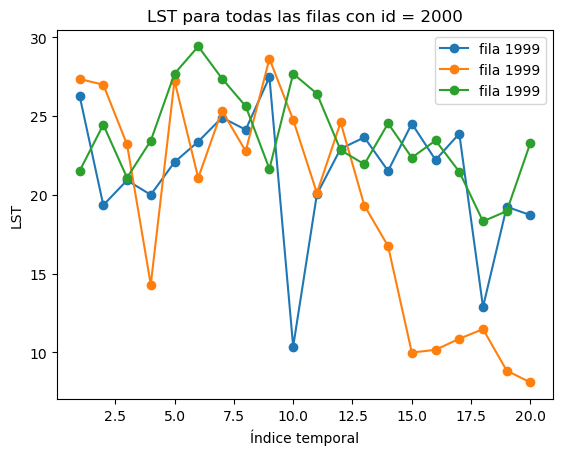

In [99]:
import matplotlib.pyplot as plt

# Filtrar todas las filas con id == 2000
rows = LST_Arroto[LST_Arroto['id'] == 2000]

# Columnas NDVI_*
ndvi_cols = [c for c in LST_Arroto.columns if c.startswith('LST_')]
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Eje X = número de NDVI
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Graficar todas las filas
plt.figure()
for idx, row in rows.iterrows():
    ndvi_values = row[ndvi_cols].values
    plt.plot(x, ndvi_values, marker='o', label=f'fila {idx}')

plt.xlabel('Índice temporal')
plt.ylabel('LST')
plt.title('LST para todas las filas con id = 2000')
plt.legend()
plt.show()

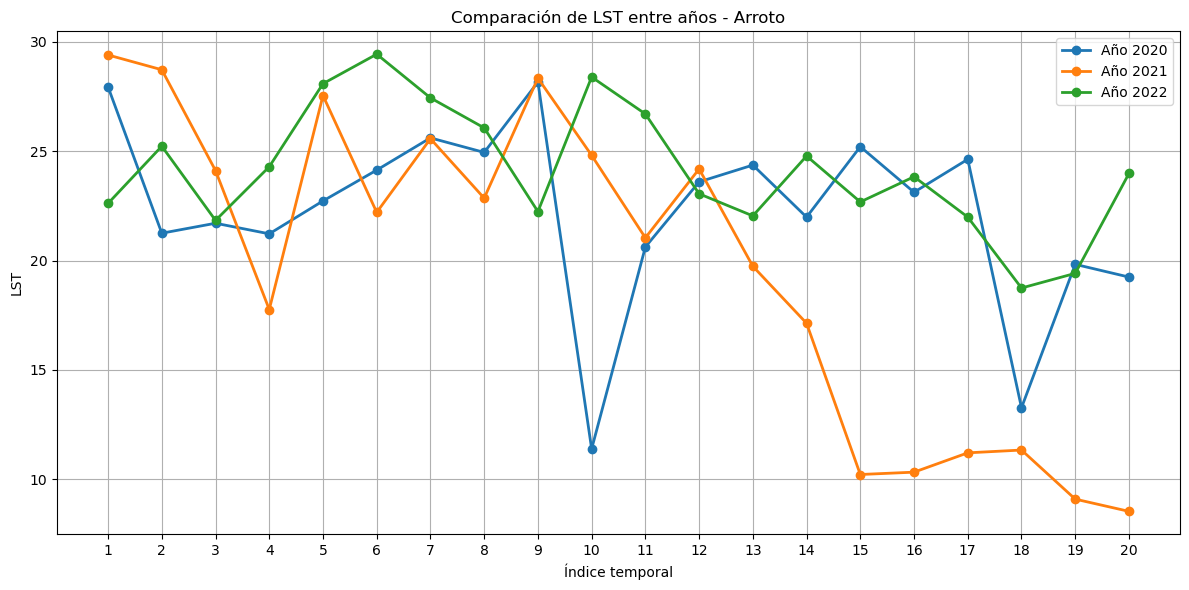

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Cargar datos

# =========================
# 2. Detectar columnas LST
# =========================
lst_cols = [c for c in LST_Arroto.columns if c.startswith("LST_")]
lst_cols = sorted(lst_cols, key=lambda x: int(x.split("_")[1]))

# Eje X
x = [int(c.split("_")[1]) for c in lst_cols]

# =========================
# 3. Reconstruir años
# =========================
n_ids = LST_Arroto["id"].nunique()
n_rows = len(LST_Arroto)
n_years = n_rows // n_ids

years_real = [2020, 2021, 2022]  # AJUSTA si es necesario

LST_Arroto = LST_Arroto.copy()
LST_Arroto["year"] = np.repeat(years_real, n_ids)

# =========================
# 4. Promedio y desviación estándar
# =========================
mean_by_year = LST_Arroto.groupby("year")[lst_cols].mean()


# =========================
# 5. Graficar comparación
# =========================
plt.figure(figsize=(12, 6))

for year in mean_by_year.index:
    mean_vals = mean_by_year.loc[year].values
 

    plt.plot(
        x,
        mean_vals,
        marker='o',
        linewidth=2,
        label=f"Año {year}"
    )

plt.xlabel("Índice temporal")
plt.ylabel("LST")
plt.title("Comparación de LST entre años - Arroto")
plt.xticks(x)
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\Figuras\Arroto_LST.png", dpi=300)
plt.show()

In [174]:
import pandas as pd
import numpy as np

# =========================
# 1. Reconstruir años
# =========================
n_ids = LST_Arroto["id"].nunique()
years_real = [2020, 2021, 2022]

LST_Arroto = LST_Arroto.copy()
LST_Arroto["year"] = np.repeat(years_real, n_ids)

# =========================
# 2. Columnas LST
# =========================
lst_cols = [c for c in LST_Arroto.columns if c.startswith("LST_")]
lst_cols = sorted(lst_cols, key=lambda x: int(x.split("_")[1]))

# tiempos (1, 3, 6, ...)
times = [int(c.split("_")[1]) for c in lst_cols]

# =========================
# 3. Extraer series
# =========================
resultados = []

for year in years_real:
    data_year = LST_Arroto[LST_Arroto["year"] == year]

    # ESTA es la serie que graficas
    serie_promedio = data_year[lst_cols].mean().values

    # guardar cada punto
    for t, valor in zip(times, serie_promedio):
        resultados.append({
            "year": year,
            "tiempo": t,
            "LST": valor
        })

# =========================
# 4. DataFrame final
# =========================
df_LST_series = pd.DataFrame(resultados)

df_LST_series

,year,tiempo,LST
0,2020,1,27.935659
1,2020,2,21.251716
2,2020,3,21.706928
3,2020,4,21.222786
4,2020,5,22.726955
5,2020,6,24.136495
6,2020,7,25.608340
7,2020,8,24.944341
8,2020,9,28.161435
9,2020,10,11.389882


#### Graficas combinadas

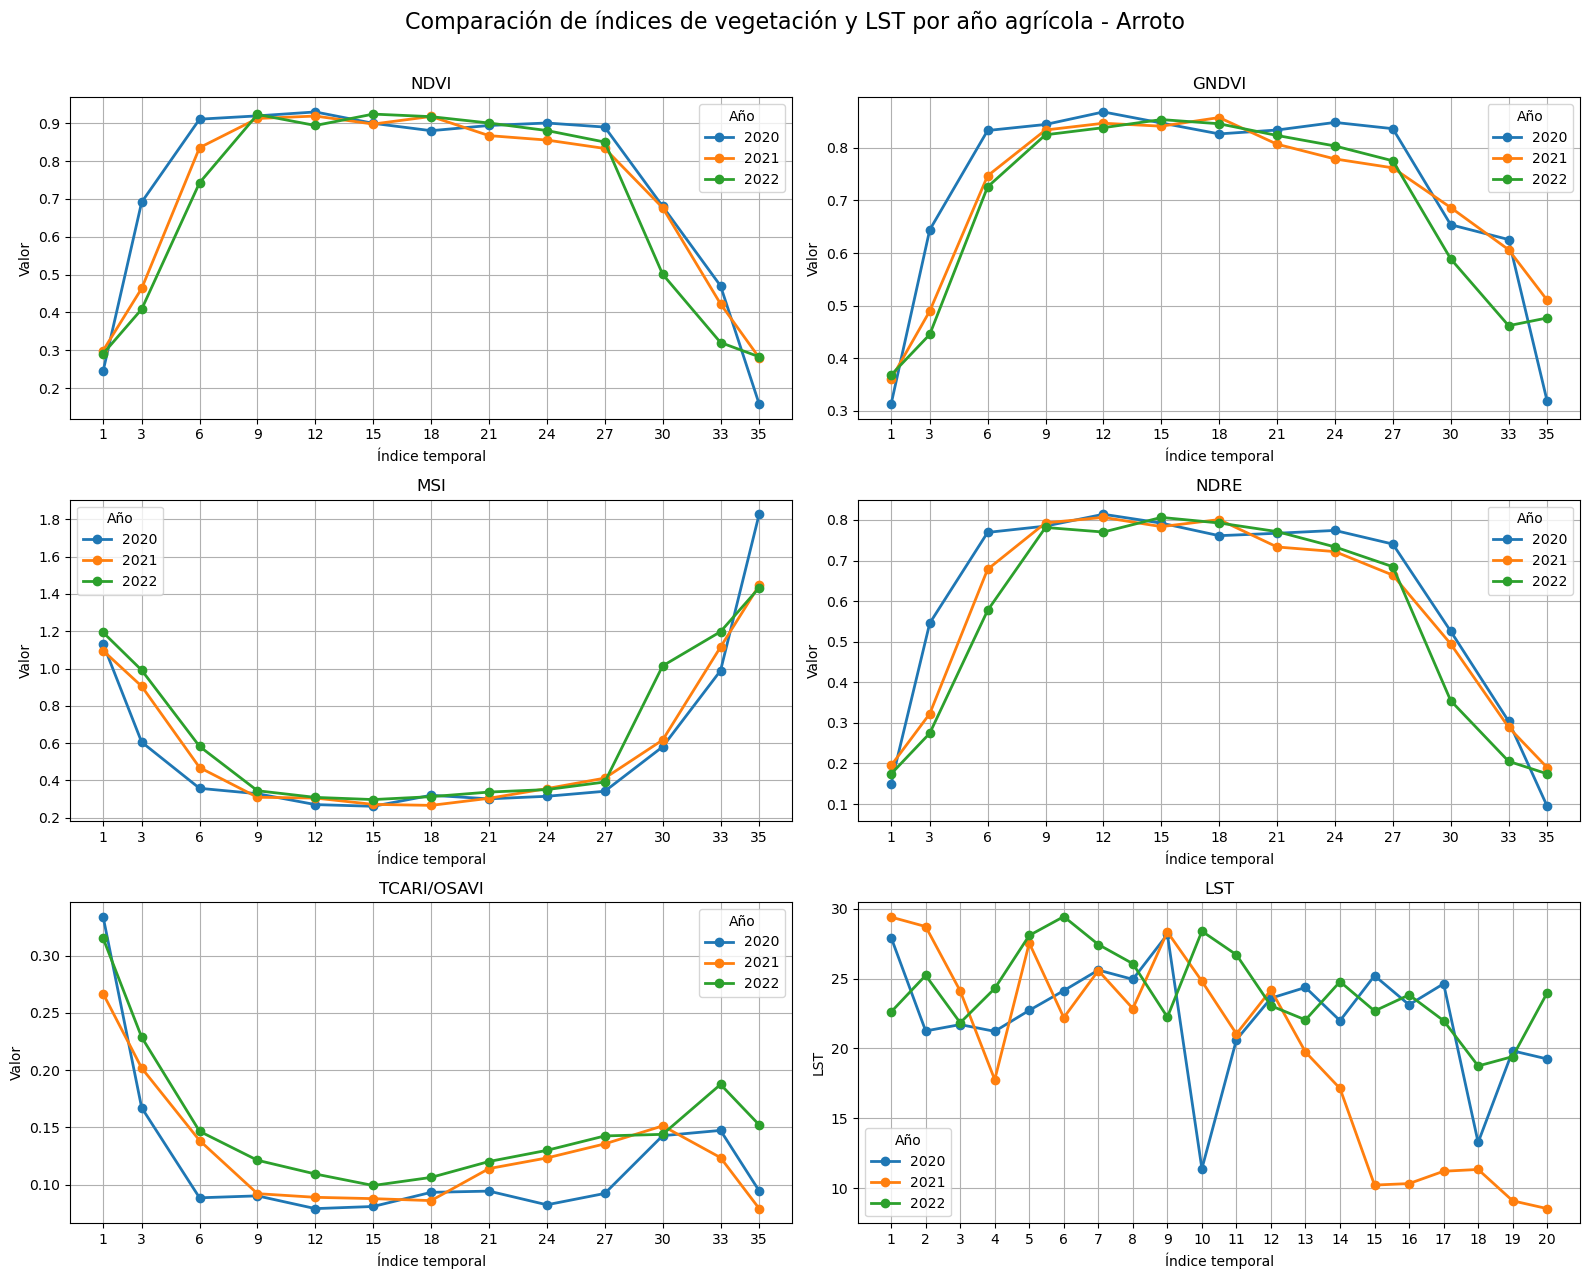

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Reconstruir años en Arroto
# =========================
years_real = [2020, 2021, 2022]
times = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

Arroto = Arroto.copy()
n_ids_vi = Arroto["id"].nunique()
Arroto["year"] = np.repeat(years_real, n_ids_vi)

# =========================
# 2. Reconstruir años en LST_Arroto
# =========================
LST_Arroto = LST_Arroto.copy()
n_ids_lst = LST_Arroto["id"].nunique()
LST_Arroto["year"] = np.repeat(years_real, n_ids_lst)

# =========================
# 3. Índices de vegetación
# =========================
indices = {
    "NDVI": [f"NDVI_{t}" for t in times],
    "GNDVI": [f"GNDVI_{t}" for t in times],
    "MSI": [f"MSI_{t}" for t in times],
    "NDRE": [f"NDRE_{t}" for t in times],
    "TCARI/OSAVI": [f"TCARIOSAVI_{t}" for t in times]
}

# =========================
# 4. Columnas LST
# =========================
lst_cols = [c for c in LST_Arroto.columns if c.startswith("LST_")]
lst_cols = sorted(lst_cols, key=lambda x: int(x.split("_")[1]))
x_lst = [int(c.split("_")[1]) for c in lst_cols]

# =========================
# 5. Colores consistentes por año
# =========================
colors = {
    2020: "tab:blue",
    2021: "tab:orange",
    2022: "tab:green"
}

# =========================
# 6. Crear figura combinada
# =========================
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
axes = axes.flatten()

# ---- Paneles de índices de vegetación
for i, (indice, cols) in enumerate(indices.items()):
    ax = axes[i]

    for year in years_real:
        data_year = Arroto[Arroto["year"] == year]
        media = data_year[cols].mean().values

        ax.plot(
            times,
            media,
            marker='o',
            linewidth=2,
            color=colors[year],
            label=str(year)
        )

    ax.set_title(indice)
    ax.set_xlabel("Índice temporal")
    ax.set_ylabel("Valor")
    ax.set_xticks(times)
    ax.grid(True)
    ax.legend(title="Año")

# ---- Panel LST
ax = axes[5]

mean_lst_by_year = LST_Arroto.groupby("year")[lst_cols].mean()

for year in mean_lst_by_year.index:
    mean_vals = mean_lst_by_year.loc[year].values

    ax.plot(
        x_lst,
        mean_vals,
        marker='o',
        linewidth=2,
        color=colors[year],
        label=str(year)
    )

ax.set_title("LST")
ax.set_xlabel("Índice temporal")
ax.set_ylabel("LST")
ax.set_xticks(x_lst)
ax.grid(True)
ax.legend(title="Año")

# =========================
# 7. Título general y guardado
# =========================
fig.suptitle("Comparación de índices de vegetación y LST por año agrícola - Arroto", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Figuras\Arroto_Indices_LST_Combinado.png",
    dpi=300,
    bbox_inches='tight'
)


plt.show()

In [284]:
LST_Arroto.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/Arroto_BiomasaLST.csv', index=False)

### Analisis

In [116]:
import pandas as pd
import numpy as np

# =========================
# 1. Copia del dataframe correcto
# =========================
df = Arroto.copy()   # usa Arroto si aquí están NDVI, GNDVI, MSI, NDRE, TCARIOSAVI

# =========================
# 2. Reconstruir años
# =========================
n_ids = df["id"].nunique()
years_real = [2020, 2021, 2022]
df["year"] = np.repeat(years_real, n_ids)

# =========================
# 3. Días a usar
# =========================
dias_objetivo = [6, 9, 12, 15, 18, 21, 24, 27]

# =========================
# 4. Índices
# =========================
indices = ["NDVI", "GNDVI", "MSI", "NDRE", "TCARIOSAVI"]

# =========================
# 5. Crear resumen ancho
# =========================
resultados = []

for year in years_real:
    fila_resultado = {"year": year}
    data_year = df[df["year"] == year]

    for indice in indices:
        cols_rango = [f"{indice}_{d}" for d in dias_objetivo]

        faltantes = [c for c in cols_rango if c not in df.columns]
        if faltantes:
            raise ValueError(f"Faltan columnas para {indice}: {faltantes}")

        valores = data_year[cols_rango].to_numpy().flatten()
        valores = valores[~pd.isna(valores)]

        fila_resultado[f"{indice}_mean_6_27"] = valores.mean()
        fila_resultado[f"{indice}_std_6_27"] = valores.std(ddof=1)
        fila_resultado[f"{indice}_min_6_27"] = valores.min()
        fila_resultado[f"{indice}_max_6_27"] = valores.max()

    resultados.append(fila_resultado)

# =========================
# 6. DataFrame final
# =========================
resumen_anual = pd.DataFrame(resultados)



# Mostrar dataframe
resumen_anual

,year,NDVI_mean_6_27,NDVI_std_6_27,NDVI_min_6_27,NDVI_max_6_27,GNDVI_mean_6_27,GNDVI_std_6_27,GNDVI_min_6_27,GNDVI_max_6_27,MSI_mean_6_27,...,MSI_min_6_27,MSI_max_6_27,NDRE_mean_6_27,NDRE_std_6_27,NDRE_min_6_27,NDRE_max_6_27,TCARIOSAVI_mean_6_27,TCARIOSAVI_std_6_27,TCARIOSAVI_min_6_27,TCARIOSAVI_max_6_27
0,2020,0.903431,0.029661,0.545319,0.958240,0.842306,0.029135,0.573150,0.897589,0.311898,...,0.228628,0.632579,0.775460,0.045204,0.341196,0.857190,0.087658,0.016597,0.024271,0.246168
1,2021,0.880205,0.050680,0.409456,0.945592,0.809318,0.050964,0.397509,0.883100,0.336634,...,0.242050,0.923362,0.747684,0.069271,0.272837,0.839775,0.108327,0.027010,-0.101450,0.317418
2,2022,0.879465,0.065916,0.472275,0.946056,0.811419,0.050361,0.500000,0.869822,0.365638,...,0.252801,0.873203,0.739658,0.082462,0.315490,0.827929,0.121965,0.022398,0.042795,0.254954


In [ ]:
# =========================
# 7. Exportar a CSV
# =========================
ruta = r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\Figuras\resumen_6_27_20columnas.csv"
resumen_anual.to_csv(ruta, index=False)

## Camino 2020

In [87]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Camino2020.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Camino2020 = pd.DataFrame(rows_final)


In [88]:
Camino2020

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2019-06-01,0.280483,1.259758,0.078570,0.123629,0.083454,2019-06-16,0.419506,1.013297,...,0.747100,0.363527,0.583635,0.237287,2019-11-08,0.444985,1.493935,0.161644,0.226953,0.040185
1,2,2019-06-01,0.279472,1.294137,0.087406,0.139083,0.165195,2019-06-16,0.448052,0.976191,...,0.710399,0.379723,0.595465,0.234526,2019-11-08,0.446597,1.522665,0.152355,0.225074,0.058554
2,3,2019-06-01,0.290938,1.236761,0.109858,0.138451,-0.064625,2019-06-16,0.450025,0.964448,...,0.687076,0.379504,0.614016,0.244322,2019-11-08,0.448479,1.489837,0.149085,0.236181,0.098243
3,4,2019-06-01,0.304009,1.272417,0.062372,0.162860,0.400878,2019-06-16,0.394866,1.103542,...,0.809765,0.315414,0.510104,0.229949,2019-11-08,0.451327,1.668022,0.112283,0.260461,0.239538
4,5,2019-06-01,0.303143,1.218316,0.083980,0.160342,0.266403,2019-06-16,0.400811,1.093587,...,0.795382,0.323460,0.548405,0.253284,2019-11-08,0.451327,1.668022,0.112283,0.260461,0.239538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2019-06-01,0.482114,0.786094,0.269609,0.366001,0.130623,2019-06-16,0.582609,0.728002,...,0.769776,0.402407,0.580888,0.169644,2019-11-08,0.461117,1.564468,0.191071,0.281460,0.093778
941,942,2019-06-01,0.648086,0.572631,0.424195,0.612465,0.189515,2019-06-16,0.525249,0.679816,...,0.675638,0.426503,0.604640,0.184388,2019-11-08,0.471620,1.485975,0.153722,0.286423,0.176864
942,943,2019-06-01,0.748162,0.385910,0.636481,0.721656,0.072431,2019-06-16,0.633748,0.538822,...,0.595303,0.508129,0.684089,0.174671,2019-11-08,0.521598,1.308913,0.211538,0.345380,0.150892
943,944,2019-06-01,0.705449,0.422568,0.608706,0.653498,0.032855,2019-06-16,0.580619,0.561946,...,0.618755,0.493657,0.663935,0.168971,2019-11-08,0.480299,1.444744,0.163922,0.308642,0.191199


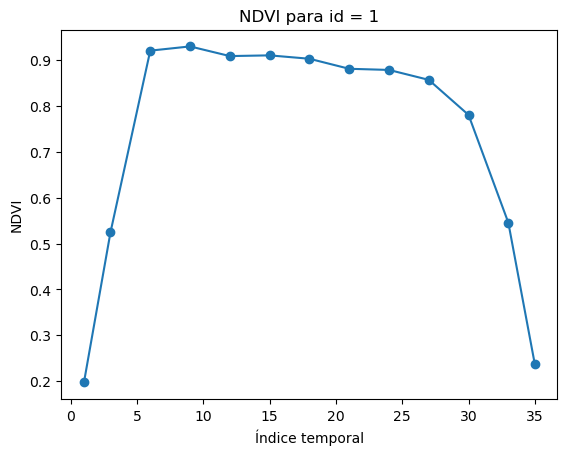

In [91]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Camino2020[Camino2020['id'] == 500].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Camino2020.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()

In [96]:
import geopandas as gpd

# Cargar el shapefile
Camino2020_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\camino_2020\Clean_Data2020/Puntos_Yield_Camino2020_Final.shp")
Camino2020_SHP = Camino2020_SHP.drop(columns= 'geometry', axis=1)
Camino2020_SHP

,id,value
0,1.0,16.126388
1,2.0,15.175583
2,3.0,15.778950
3,4.0,15.726726
4,5.0,15.289876
...,...,...
940,941.0,21.098816
941,942.0,18.609881
942,943.0,19.841206
943,944.0,26.672810


In [99]:
coe_Camino2020 = (5.421034687007729 / 10) * 15

In [100]:
coe_Camino2020

8.131552030511592

In [101]:
Camino2020_SHP['biomasa'] = Camino2020_SHP['value'] * coe_Camino2020
Camino2020_SHP = Camino2020_SHP.drop('value', axis=1)
Camino2020_SHP

,id,biomasa
0,1.0,131.132563
1,2.0,123.401043
2,3.0,128.307353
3,4.0,127.882691
4,5.0,124.330422
...,...,...
940,941.0,171.566120
941,942.0,151.327216
942,943.0,161.339799
943,944.0,216.891342


In [102]:
Camino2020 = pd.merge(Camino2020, Camino2020_SHP, on='id', how='inner')
Camino2020

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2019-06-01,0.280483,1.259758,0.078570,0.123629,0.083454,2019-06-16,0.419506,1.013297,...,0.363527,0.583635,0.237287,2019-11-08,0.444985,1.493935,0.161644,0.226953,0.040185,131.132563
1,2,2019-06-01,0.279472,1.294137,0.087406,0.139083,0.165195,2019-06-16,0.448052,0.976191,...,0.379723,0.595465,0.234526,2019-11-08,0.446597,1.522665,0.152355,0.225074,0.058554,123.401043
2,3,2019-06-01,0.290938,1.236761,0.109858,0.138451,-0.064625,2019-06-16,0.450025,0.964448,...,0.379504,0.614016,0.244322,2019-11-08,0.448479,1.489837,0.149085,0.236181,0.098243,128.307353
3,4,2019-06-01,0.304009,1.272417,0.062372,0.162860,0.400878,2019-06-16,0.394866,1.103542,...,0.315414,0.510104,0.229949,2019-11-08,0.451327,1.668022,0.112283,0.260461,0.239538,127.882691
4,5,2019-06-01,0.303143,1.218316,0.083980,0.160342,0.266403,2019-06-16,0.400811,1.093587,...,0.323460,0.548405,0.253284,2019-11-08,0.451327,1.668022,0.112283,0.260461,0.239538,124.330422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2019-06-01,0.482114,0.786094,0.269609,0.366001,0.130623,2019-06-16,0.582609,0.728002,...,0.402407,0.580888,0.169644,2019-11-08,0.461117,1.564468,0.191071,0.281460,0.093778,171.566120
941,942,2019-06-01,0.648086,0.572631,0.424195,0.612465,0.189515,2019-06-16,0.525249,0.679816,...,0.426503,0.604640,0.184388,2019-11-08,0.471620,1.485975,0.153722,0.286423,0.176864,151.327216
942,943,2019-06-01,0.748162,0.385910,0.636481,0.721656,0.072431,2019-06-16,0.633748,0.538822,...,0.508129,0.684089,0.174671,2019-11-08,0.521598,1.308913,0.211538,0.345380,0.150892,161.339799
943,944,2019-06-01,0.705449,0.422568,0.608706,0.653498,0.032855,2019-06-16,0.580619,0.561946,...,0.493657,0.663935,0.168971,2019-11-08,0.480299,1.444744,0.163922,0.308642,0.191199,216.891342


### LST

In [104]:
LST_Camino2020 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Camino2020_2.csv')
LST_Camino2020 = LST_Camino2020.drop(columns=['geo','lon','lat'], axis=1)
LST_Camino2020

,id,date,LST
0,1,14/06/2019,32.908181
1,2,14/06/2019,33.115844
2,3,14/06/2019,33.115844
3,4,14/06/2019,32.908181
4,5,14/06/2019,32.908181
...,...,...,...
18895,941,13/11/2019,10.501071
18896,942,13/11/2019,10.501071
18897,943,13/11/2019,10.510396
18898,944,13/11/2019,10.501071


In [105]:
import numpy as np
import pandas as pd

df = LST_Camino2020

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Camino2020 = pd.DataFrame(rows_final)

In [106]:
LST_Camino2020 = pd.merge(LST_Camino2020, Camino2020, on='id', how='inner')
LST_Camino2020

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2019-06-14,32.908181,2019-06-22,28.656309,2019-07-01,25.258272,2019-07-09,21.716871,2019-07-16,...,0.363527,0.583635,0.237287,2019-11-08,0.444985,1.493935,0.161644,0.226953,0.040185,131.132563
1,2,2019-06-14,33.115844,2019-06-22,29.424776,2019-07-01,24.688611,2019-07-09,21.477885,2019-07-16,...,0.379723,0.595465,0.234526,2019-11-08,0.446597,1.522665,0.152355,0.225074,0.058554,123.401043
2,3,2019-06-14,33.115844,2019-06-22,29.424776,2019-07-01,24.688611,2019-07-09,21.477885,2019-07-16,...,0.379504,0.614016,0.244322,2019-11-08,0.448479,1.489837,0.149085,0.236181,0.098243,128.307353
3,4,2019-06-14,32.908181,2019-06-22,28.656309,2019-07-01,25.258272,2019-07-09,21.716871,2019-07-16,...,0.315414,0.510104,0.229949,2019-11-08,0.451327,1.668022,0.112283,0.260461,0.239538,127.882691
4,5,2019-06-14,32.908181,2019-06-22,28.656309,2019-07-01,25.258272,2019-07-09,21.716871,2019-07-16,...,0.323460,0.548405,0.253284,2019-11-08,0.451327,1.668022,0.112283,0.260461,0.239538,124.330422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2019-06-14,27.068043,2019-06-22,23.010748,2019-07-01,23.638879,2019-07-09,21.326171,2019-07-16,...,0.402407,0.580888,0.169644,2019-11-08,0.461117,1.564468,0.191071,0.281460,0.093778,171.566120
941,942,2019-06-14,27.068043,2019-06-22,23.010748,2019-07-01,23.638879,2019-07-09,21.326171,2019-07-16,...,0.426503,0.604640,0.184388,2019-11-08,0.471620,1.485975,0.153722,0.286423,0.176864,151.327216
942,943,2019-06-14,26.956283,2019-06-22,22.438729,2019-07-01,23.618621,2019-07-09,21.356029,2019-07-16,...,0.508129,0.684089,0.174671,2019-11-08,0.521598,1.308913,0.211538,0.345380,0.150892,161.339799
943,944,2019-06-14,27.068043,2019-06-22,23.010748,2019-07-01,23.638879,2019-07-09,21.326171,2019-07-16,...,0.493657,0.663935,0.168971,2019-11-08,0.480299,1.444744,0.163922,0.308642,0.191199,216.891342


## Camino 2021

In [118]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Camino2021.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Camino2021 = pd.DataFrame(rows_final)


In [119]:
Camino2021

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2020-06-10,0.307229,1.135369,0.117657,0.213986,0.422671,2020-06-20,0.406677,1.076328,...,1.251854,0.215745,0.344856,0.148436,2020-11-17,0.367288,1.927597,0.116252,0.190506,0.090914
1,2,2020-06-10,0.341921,1.081185,0.141694,0.239293,0.370555,2020-06-20,0.463488,1.026598,...,1.243810,0.226716,0.341468,0.120951,2020-11-17,0.351168,2.015616,0.130161,0.158643,-0.053082
2,3,2020-06-10,0.331174,1.107896,0.129678,0.231025,0.417550,2020-06-20,0.469293,0.999211,...,1.261091,0.225817,0.339481,0.120231,2020-11-17,0.352812,1.956264,0.121744,0.200259,0.109767
3,4,2020-06-10,0.274013,1.176797,0.080518,0.173928,0.514177,2020-06-20,0.370923,1.224767,...,1.227948,0.190384,0.357278,0.217721,2020-11-17,0.344204,2.037447,0.023758,0.170370,0.341598
4,5,2020-06-10,0.274013,1.176797,0.080518,0.173928,0.514177,2020-06-20,0.374753,1.220425,...,1.271024,0.173717,0.353936,0.235426,2020-11-17,0.351237,2.020397,0.027957,0.174447,0.330033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2020-06-10,0.438546,0.937593,0.289272,0.405499,0.284219,2020-06-20,0.592158,0.697564,...,0.990695,0.313417,0.462795,0.147259,2020-11-17,0.365089,1.819559,0.133195,0.188216,0.040889
941,942,2020-06-10,0.439204,0.991281,0.245926,0.382377,0.299881,2020-06-20,0.564878,0.863622,...,0.928000,0.295001,0.469940,0.177705,2020-11-17,0.352060,1.861034,0.092836,0.189456,0.175461
942,943,2020-06-10,0.418876,0.965869,0.268647,0.354251,0.220644,2020-06-20,0.561632,0.770984,...,1.012993,0.291999,0.469438,0.177058,2020-11-17,0.359798,1.859129,0.123958,0.171553,0.012935
943,944,2020-06-10,0.418274,0.995123,0.254750,0.367018,0.294485,2020-06-20,0.565661,0.786058,...,0.993832,0.300709,0.476400,0.176237,2020-11-17,0.338200,1.823636,0.133436,0.190476,0.066410


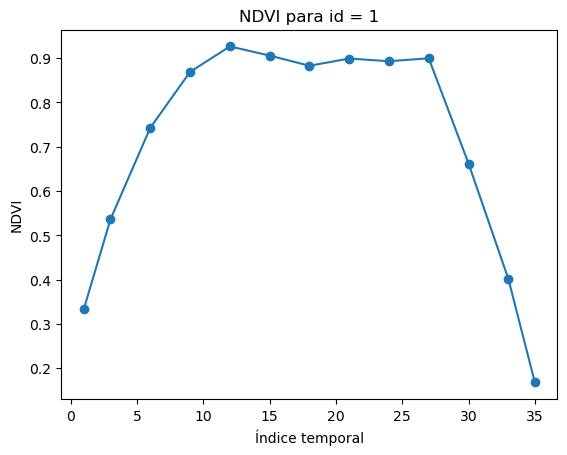

In [120]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Camino2021[Camino2021['id'] == 500].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Camino2021.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()

In [121]:
import geopandas as gpd

# Cargar el shapefile
Camino2021_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\camino_2021\Clean_Data2021/Puntos_Yield_Camino2021_Final.shp")
Camino2021_SHP = Camino2021_SHP.drop(columns= 'geometry', axis=1)
Camino2021_SHP

,id,value
0,1.0,18.986894
1,2.0,13.503236
2,3.0,16.833386
3,4.0,16.692323
4,5.0,16.601511
...,...,...
940,941.0,17.467529
941,942.0,17.697421
942,943.0,17.258361
943,944.0,23.830979


In [122]:
coe_Camino2021 = (6.8134780982469385 / 10) * 15

In [123]:
coe_Camino2021

10.220217147370409

In [124]:
Camino2021_SHP['biomasa'] = Camino2021_SHP['value'] * coe_Camino2021
Camino2021_SHP = Camino2021_SHP.drop('value', axis=1)
Camino2021_SHP

,id,biomasa
0,1.0,194.050180
1,2.0,138.006004
2,3.0,172.040860
3,4.0,170.599166
4,5.0,169.671047
...,...,...
940,941.0,178.521939
941,942.0,180.871486
942,943.0,176.384197
943,944.0,243.557780


In [125]:
Camino2021 = pd.merge(Camino2021, Camino2021_SHP, on='id', how='inner')
Camino2021

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-10,0.307229,1.135369,0.117657,0.213986,0.422671,2020-06-20,0.406677,1.076328,...,0.215745,0.344856,0.148436,2020-11-17,0.367288,1.927597,0.116252,0.190506,0.090914,194.050180
1,2,2020-06-10,0.341921,1.081185,0.141694,0.239293,0.370555,2020-06-20,0.463488,1.026598,...,0.226716,0.341468,0.120951,2020-11-17,0.351168,2.015616,0.130161,0.158643,-0.053082,138.006004
2,3,2020-06-10,0.331174,1.107896,0.129678,0.231025,0.417550,2020-06-20,0.469293,0.999211,...,0.225817,0.339481,0.120231,2020-11-17,0.352812,1.956264,0.121744,0.200259,0.109767,172.040860
3,4,2020-06-10,0.274013,1.176797,0.080518,0.173928,0.514177,2020-06-20,0.370923,1.224767,...,0.190384,0.357278,0.217721,2020-11-17,0.344204,2.037447,0.023758,0.170370,0.341598,170.599166
4,5,2020-06-10,0.274013,1.176797,0.080518,0.173928,0.514177,2020-06-20,0.374753,1.220425,...,0.173717,0.353936,0.235426,2020-11-17,0.351237,2.020397,0.027957,0.174447,0.330033,169.671047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2020-06-10,0.438546,0.937593,0.289272,0.405499,0.284219,2020-06-20,0.592158,0.697564,...,0.313417,0.462795,0.147259,2020-11-17,0.365089,1.819559,0.133195,0.188216,0.040889,178.521939
941,942,2020-06-10,0.439204,0.991281,0.245926,0.382377,0.299881,2020-06-20,0.564878,0.863622,...,0.295001,0.469940,0.177705,2020-11-17,0.352060,1.861034,0.092836,0.189456,0.175461,180.871486
942,943,2020-06-10,0.418876,0.965869,0.268647,0.354251,0.220644,2020-06-20,0.561632,0.770984,...,0.291999,0.469438,0.177058,2020-11-17,0.359798,1.859129,0.123958,0.171553,0.012935,176.384197
943,944,2020-06-10,0.418274,0.995123,0.254750,0.367018,0.294485,2020-06-20,0.565661,0.786058,...,0.300709,0.476400,0.176237,2020-11-17,0.338200,1.823636,0.133436,0.190476,0.066410,243.557780


### LST

In [127]:
LST_Camino2021 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Camino2021_2.csv')
LST_Camino2021 = LST_Camino2021.drop(columns=['geo','lon','lat'], axis=1)
LST_Camino2021

,id,date,LST
0,1,01/06/2020,29.555319
1,2,01/06/2020,29.061909
2,3,01/06/2020,29.061909
3,4,01/06/2020,29.555319
4,5,01/06/2020,29.555319
...,...,...,...
18895,941,15/10/2020,12.622434
18896,942,15/10/2020,12.622434
18897,943,15/10/2020,12.548381
18898,944,15/10/2020,12.622434


In [130]:
import numpy as np
import pandas as pd

df = LST_Camino2021

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Camino2021 = pd.DataFrame(rows_final)

In [132]:
LST_Camino2021 = pd.merge(LST_Camino2021, Camino2021, on='id', how='inner')
LST_Camino2021

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-01,29.555319,2020-06-09,29.877222,2020-06-16,19.351422,2020-06-25,22.089245,2020-07-02,...,0.215745,0.344856,0.148436,2020-11-17,0.367288,1.927597,0.116252,0.190506,0.090914,194.050180
1,2,2020-06-01,29.061909,2020-06-09,30.524397,2020-06-16,20.323883,2020-06-25,22.359693,2020-07-02,...,0.226716,0.341468,0.120951,2020-11-17,0.351168,2.015616,0.130161,0.158643,-0.053082,138.006004
2,3,2020-06-01,29.061909,2020-06-09,30.524397,2020-06-16,20.323883,2020-06-25,22.359693,2020-07-02,...,0.225817,0.339481,0.120231,2020-11-17,0.352812,1.956264,0.121744,0.200259,0.109767,172.040860
3,4,2020-06-01,29.555319,2020-06-09,29.877222,2020-06-16,19.351422,2020-06-25,22.089245,2020-07-02,...,0.190384,0.357278,0.217721,2020-11-17,0.344204,2.037447,0.023758,0.170370,0.341598,170.599166
4,5,2020-06-01,29.555319,2020-06-09,29.877222,2020-06-16,19.351422,2020-06-25,22.089245,2020-07-02,...,0.173717,0.353936,0.235426,2020-11-17,0.351237,2.020397,0.027957,0.174447,0.330033,169.671047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2020-06-01,26.767056,2020-06-09,28.453668,2020-06-16,21.970111,2020-06-25,21.851724,2020-07-02,...,0.313417,0.462795,0.147259,2020-11-17,0.365089,1.819559,0.133195,0.188216,0.040889,178.521939
941,942,2020-06-01,26.767056,2020-06-09,28.453668,2020-06-16,21.970111,2020-06-25,21.851724,2020-07-02,...,0.295001,0.469940,0.177705,2020-11-17,0.352060,1.861034,0.092836,0.189456,0.175461,180.871486
942,943,2020-06-01,26.794892,2020-06-09,28.949695,2020-06-16,21.717765,2020-06-25,21.769764,2020-07-02,...,0.291999,0.469438,0.177058,2020-11-17,0.359798,1.859129,0.123958,0.171553,0.012935,176.384197
943,944,2020-06-01,26.767056,2020-06-09,28.453668,2020-06-16,21.970111,2020-06-25,21.851724,2020-07-02,...,0.300709,0.476400,0.176237,2020-11-17,0.338200,1.823636,0.133436,0.190476,0.066410,243.557780


## Camino 2022

In [141]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Camino2022.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Camino2022 = pd.DataFrame(rows_final)

In [142]:
Camino2022

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2022-06-03,0.286391,1.224595,0.061076,0.137036,0.272140,2022-06-13,0.356390,1.169982,...,1.046719,0.255833,0.405191,0.203143,2022-10-18,0.479222,1.477884,0.171774,0.283960,0.145609
1,2,2022-06-03,0.323754,1.158199,0.091230,0.172488,0.237484,2022-06-13,0.378247,1.058946,...,1.068253,0.255723,0.372387,0.158120,2022-10-18,0.468560,1.525783,0.172997,0.258644,0.089276
2,3,2022-06-03,0.328963,1.137444,0.104370,0.196031,0.273030,2022-06-13,0.386922,1.061404,...,1.093175,0.238082,0.352155,0.159893,2022-10-18,0.444037,1.588628,0.142857,0.251192,0.159182
3,4,2022-06-03,0.256188,1.281986,0.030183,0.122666,0.455657,2022-06-13,0.307713,1.306531,...,1.018366,0.256091,0.456349,0.247621,2022-10-18,0.508493,1.420182,0.163130,0.347676,0.249490
4,5,2022-06-03,0.264725,1.254382,0.041053,0.118141,0.336016,2022-06-13,0.310252,1.311348,...,1.035894,0.248101,0.444731,0.252928,2022-10-18,0.476660,1.444896,0.154722,0.317287,0.242447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2022-06-03,0.401281,1.110294,0.199237,0.301267,0.216674,2022-06-13,0.615489,0.770160,...,1.127214,0.231547,0.358568,0.199137,2022-10-18,0.483146,1.531194,0.178778,0.285223,0.131003
941,942,2022-06-03,0.388763,1.017368,0.216959,0.315945,0.209955,2022-06-13,0.577439,0.881716,...,1.103261,0.216609,0.366607,0.235126,2022-10-18,0.470202,1.483354,0.174511,0.298119,0.168735
942,943,2022-06-03,0.369631,1.097283,0.195320,0.294878,0.235872,2022-06-13,0.606642,0.805900,...,1.101848,0.234974,0.371648,0.201874,2022-10-18,0.473961,1.514549,0.188846,0.283537,0.110169
943,944,2022-06-03,0.403212,1.103012,0.192814,0.308460,0.248532,2022-06-13,0.589158,0.821962,...,1.106126,0.233143,0.360728,0.197209,2022-10-18,0.457635,1.524507,0.185684,0.275152,0.107087


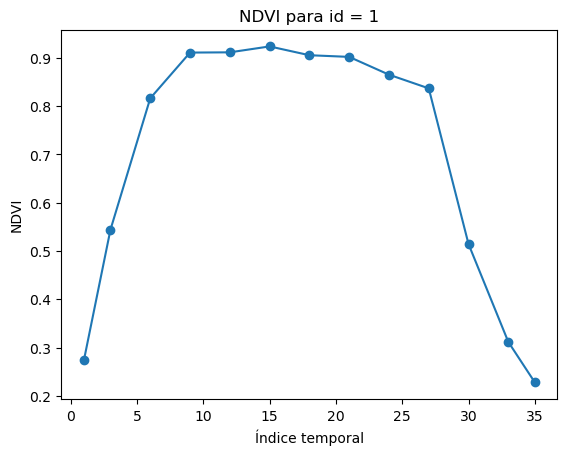

In [143]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Camino2022[Camino2022['id'] == 500].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Camino2022.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()

In [144]:
import geopandas as gpd

# Cargar el shapefile
Camino2022_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\camino_2022\Clean_Data2022/Puntos_Yield_Camino2022_Final.shp")
Camino2022_SHP = Camino2022_SHP.drop(columns= 'geometry', axis=1)
Camino2022_SHP

,id,value
0,1.0,14.990175
1,2.0,15.519938
2,3.0,15.020378
3,4.0,11.099218
4,5.0,14.128673
...,...,...
940,941.0,16.175603
941,942.0,14.886004
942,943.0,18.552598
943,944.0,16.810277


In [145]:
coe_Camino2022 = (6.257222286270027 / 10) * 15

In [146]:
coe_Camino2022

9.38583342940504

In [147]:
Camino2022_SHP['biomasa'] = Camino2022_SHP['value'] * coe_Camino2022
Camino2022_SHP = Camino2022_SHP.drop('value', axis=1)
Camino2022_SHP

,id,biomasa
0,1.0,140.695286
1,2.0,145.667553
2,3.0,140.978766
3,4.0,104.175411
4,5.0,132.609371
...,...,...
940,941.0,151.821515
941,942.0,139.717554
942,943.0,174.131595
943,944.0,157.778460


In [148]:
Camino2022 = pd.merge(Camino2022, Camino2022_SHP, on='id', how='inner')
Camino2022

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2022-06-03,0.286391,1.224595,0.061076,0.137036,0.272140,2022-06-13,0.356390,1.169982,...,0.255833,0.405191,0.203143,2022-10-18,0.479222,1.477884,0.171774,0.283960,0.145609,140.695286
1,2,2022-06-03,0.323754,1.158199,0.091230,0.172488,0.237484,2022-06-13,0.378247,1.058946,...,0.255723,0.372387,0.158120,2022-10-18,0.468560,1.525783,0.172997,0.258644,0.089276,145.667553
2,3,2022-06-03,0.328963,1.137444,0.104370,0.196031,0.273030,2022-06-13,0.386922,1.061404,...,0.238082,0.352155,0.159893,2022-10-18,0.444037,1.588628,0.142857,0.251192,0.159182,140.978766
3,4,2022-06-03,0.256188,1.281986,0.030183,0.122666,0.455657,2022-06-13,0.307713,1.306531,...,0.256091,0.456349,0.247621,2022-10-18,0.508493,1.420182,0.163130,0.347676,0.249490,104.175411
4,5,2022-06-03,0.264725,1.254382,0.041053,0.118141,0.336016,2022-06-13,0.310252,1.311348,...,0.248101,0.444731,0.252928,2022-10-18,0.476660,1.444896,0.154722,0.317287,0.242447,132.609371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2022-06-03,0.401281,1.110294,0.199237,0.301267,0.216674,2022-06-13,0.615489,0.770160,...,0.231547,0.358568,0.199137,2022-10-18,0.483146,1.531194,0.178778,0.285223,0.131003,151.821515
941,942,2022-06-03,0.388763,1.017368,0.216959,0.315945,0.209955,2022-06-13,0.577439,0.881716,...,0.216609,0.366607,0.235126,2022-10-18,0.470202,1.483354,0.174511,0.298119,0.168735,139.717554
942,943,2022-06-03,0.369631,1.097283,0.195320,0.294878,0.235872,2022-06-13,0.606642,0.805900,...,0.234974,0.371648,0.201874,2022-10-18,0.473961,1.514549,0.188846,0.283537,0.110169,174.131595
943,944,2022-06-03,0.403212,1.103012,0.192814,0.308460,0.248532,2022-06-13,0.589158,0.821962,...,0.233143,0.360728,0.197209,2022-10-18,0.457635,1.524507,0.185684,0.275152,0.107087,157.778460


### LST

In [150]:
LST_Camino2022 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Camino2022_2.csv')
LST_Camino2022 = LST_Camino2022.drop(columns=['.geo'], axis=1)
LST_Camino2022

,id,date,LST
0,1,07/06/2022,20.436133
1,2,07/06/2022,20.335664
2,3,07/06/2022,20.335664
3,4,07/06/2022,20.436133
4,5,07/06/2022,20.436133
...,...,...,...
18895,941,05/10/2022,22.239923
18896,942,05/10/2022,22.239923
18897,943,05/10/2022,22.195928
18898,944,05/10/2022,22.239923


In [152]:
import numpy as np
import pandas as pd

df = LST_Camino2022

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Camino2022 = pd.DataFrame(rows_final)

In [155]:
LST_Camino2022 = pd.merge(LST_Camino2022, Camino2022, on='id', how='inner')
LST_Camino2022

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2022-06-07,20.436133,2022-06-15,26.937359,2022-06-22,20.052951,2022-06-27,20.690734,2022-07-01,...,0.255833,0.405191,0.203143,2022-10-18,0.479222,1.477884,0.171774,0.283960,0.145609,140.695286
1,2,2022-06-07,20.335664,2022-06-15,26.672467,2022-06-22,20.128757,2022-06-27,20.095923,2022-07-01,...,0.255723,0.372387,0.158120,2022-10-18,0.468560,1.525783,0.172997,0.258644,0.089276,145.667553
2,3,2022-06-07,20.335664,2022-06-15,26.672467,2022-06-22,20.128757,2022-06-27,20.095923,2022-07-01,...,0.238082,0.352155,0.159893,2022-10-18,0.444037,1.588628,0.142857,0.251192,0.159182,140.978766
3,4,2022-06-07,20.436133,2022-06-15,26.937359,2022-06-22,20.052951,2022-06-27,20.690734,2022-07-01,...,0.256091,0.456349,0.247621,2022-10-18,0.508493,1.420182,0.163130,0.347676,0.249490,104.175411
4,5,2022-06-07,20.436133,2022-06-15,26.937359,2022-06-22,20.052951,2022-06-27,20.690734,2022-07-01,...,0.248101,0.444731,0.252928,2022-10-18,0.476660,1.444896,0.154722,0.317287,0.242447,132.609371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2022-06-07,19.241368,2022-06-15,25.695884,2022-06-22,19.638246,2022-06-27,18.443891,2022-07-01,...,0.231547,0.358568,0.199137,2022-10-18,0.483146,1.531194,0.178778,0.285223,0.131003,151.821515
941,942,2022-06-07,19.241368,2022-06-15,25.695884,2022-06-22,19.638246,2022-06-27,18.443891,2022-07-01,...,0.216609,0.366607,0.235126,2022-10-18,0.470202,1.483354,0.174511,0.298119,0.168735,139.717554
942,943,2022-06-07,19.452018,2022-06-15,25.908643,2022-06-22,19.656928,2022-06-27,18.450416,2022-07-01,...,0.234974,0.371648,0.201874,2022-10-18,0.473961,1.514549,0.188846,0.283537,0.110169,174.131595
943,944,2022-06-07,19.241368,2022-06-15,25.695884,2022-06-22,19.638246,2022-06-27,18.443891,2022-07-01,...,0.233143,0.360728,0.197209,2022-10-18,0.457635,1.524507,0.185684,0.275152,0.107087,157.778460


## Camino Final

In [162]:
Camino = pd.concat([Camino2020, Camino2021, Camino2022])
Camino

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2019-06-01,0.280483,1.259758,0.078570,0.123629,0.083454,2019-06-16,0.419506,1.013297,...,0.363527,0.583635,0.237287,2019-11-08,0.444985,1.493935,0.161644,0.226953,0.040185,131.132563
1,2,2019-06-01,0.279472,1.294137,0.087406,0.139083,0.165195,2019-06-16,0.448052,0.976191,...,0.379723,0.595465,0.234526,2019-11-08,0.446597,1.522665,0.152355,0.225074,0.058554,123.401043
2,3,2019-06-01,0.290938,1.236761,0.109858,0.138451,-0.064625,2019-06-16,0.450025,0.964448,...,0.379504,0.614016,0.244322,2019-11-08,0.448479,1.489837,0.149085,0.236181,0.098243,128.307353
3,4,2019-06-01,0.304009,1.272417,0.062372,0.162860,0.400878,2019-06-16,0.394866,1.103542,...,0.315414,0.510104,0.229949,2019-11-08,0.451327,1.668022,0.112283,0.260461,0.239538,127.882691
4,5,2019-06-01,0.303143,1.218316,0.083980,0.160342,0.266403,2019-06-16,0.400811,1.093587,...,0.323460,0.548405,0.253284,2019-11-08,0.451327,1.668022,0.112283,0.260461,0.239538,124.330422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2022-06-03,0.401281,1.110294,0.199237,0.301267,0.216674,2022-06-13,0.615489,0.770160,...,0.231547,0.358568,0.199137,2022-10-18,0.483146,1.531194,0.178778,0.285223,0.131003,151.821515
941,942,2022-06-03,0.388763,1.017368,0.216959,0.315945,0.209955,2022-06-13,0.577439,0.881716,...,0.216609,0.366607,0.235126,2022-10-18,0.470202,1.483354,0.174511,0.298119,0.168735,139.717554
942,943,2022-06-03,0.369631,1.097283,0.195320,0.294878,0.235872,2022-06-13,0.606642,0.805900,...,0.234974,0.371648,0.201874,2022-10-18,0.473961,1.514549,0.188846,0.283537,0.110169,174.131595
943,944,2022-06-03,0.403212,1.103012,0.192814,0.308460,0.248532,2022-06-13,0.589158,0.821962,...,0.233143,0.360728,0.197209,2022-10-18,0.457635,1.524507,0.185684,0.275152,0.107087,157.778460


In [166]:
cols_to_drop = [c for c in Camino.columns if c.startswith('date_')]
Camino = Camino.drop(cols_to_drop, axis=1)

In [168]:
Camino

,id,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,GNDVI_3,MSI_3,NDRE_3,NDVI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,0.280483,1.259758,0.078570,0.123629,0.083454,0.419506,1.013297,0.236042,0.330988,...,0.747100,0.363527,0.583635,0.237287,0.444985,1.493935,0.161644,0.226953,0.040185,131.132563
1,2,0.279472,1.294137,0.087406,0.139083,0.165195,0.448052,0.976191,0.258480,0.366200,...,0.710399,0.379723,0.595465,0.234526,0.446597,1.522665,0.152355,0.225074,0.058554,123.401043
2,3,0.290938,1.236761,0.109858,0.138451,-0.064625,0.450025,0.964448,0.268396,0.372566,...,0.687076,0.379504,0.614016,0.244322,0.448479,1.489837,0.149085,0.236181,0.098243,128.307353
3,4,0.304009,1.272417,0.062372,0.162860,0.400878,0.394866,1.103542,0.176286,0.315058,...,0.809765,0.315414,0.510104,0.229949,0.451327,1.668022,0.112283,0.260461,0.239538,127.882691
4,5,0.303143,1.218316,0.083980,0.160342,0.266403,0.400811,1.093587,0.182001,0.324007,...,0.795382,0.323460,0.548405,0.253284,0.451327,1.668022,0.112283,0.260461,0.239538,124.330422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,0.401281,1.110294,0.199237,0.301267,0.216674,0.615489,0.770160,0.473108,0.611860,...,1.127214,0.231547,0.358568,0.199137,0.483146,1.531194,0.178778,0.285223,0.131003,151.821515
941,942,0.388763,1.017368,0.216959,0.315945,0.209955,0.577439,0.881716,0.377896,0.561255,...,1.103261,0.216609,0.366607,0.235126,0.470202,1.483354,0.174511,0.298119,0.168735,139.717554
942,943,0.369631,1.097283,0.195320,0.294878,0.235872,0.606642,0.805900,0.442081,0.602771,...,1.101848,0.234974,0.371648,0.201874,0.473961,1.514549,0.188846,0.283537,0.110169,174.131595
943,944,0.403212,1.103012,0.192814,0.308460,0.248532,0.589158,0.821962,0.434107,0.575483,...,1.106126,0.233143,0.360728,0.197209,0.457635,1.524507,0.185684,0.275152,0.107087,157.778460


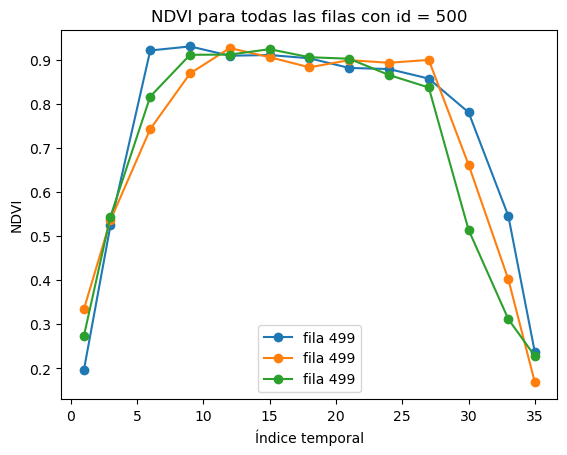

In [170]:
import matplotlib.pyplot as plt

# Filtrar todas las filas con id == 2000
rows = Camino[Camino['id'] == 500]

# Columnas NDVI_*
ndvi_cols = [c for c in Camino.columns if c.startswith('NDVI_')]
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Eje X = número de NDVI
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Graficar todas las filas
plt.figure()
for idx, row in rows.iterrows():
    ndvi_values = row[ndvi_cols].values
    plt.plot(x, ndvi_values, marker='o', label=f'fila {idx}')

plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para todas las filas con id = 500')
plt.legend()
plt.show()

In [442]:
Camino.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/Camino_BiomasaIV.csv', index=False)

### LST

In [172]:
LST_Camino = pd.concat([LST_Camino2020, LST_Camino2021, LST_Camino2022])
LST_Camino

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2019-06-14,32.908181,2019-06-22,28.656309,2019-07-01,25.258272,2019-07-09,21.716871,2019-07-16,...,0.363527,0.583635,0.237287,2019-11-08,0.444985,1.493935,0.161644,0.226953,0.040185,131.132563
1,2,2019-06-14,33.115844,2019-06-22,29.424776,2019-07-01,24.688611,2019-07-09,21.477885,2019-07-16,...,0.379723,0.595465,0.234526,2019-11-08,0.446597,1.522665,0.152355,0.225074,0.058554,123.401043
2,3,2019-06-14,33.115844,2019-06-22,29.424776,2019-07-01,24.688611,2019-07-09,21.477885,2019-07-16,...,0.379504,0.614016,0.244322,2019-11-08,0.448479,1.489837,0.149085,0.236181,0.098243,128.307353
3,4,2019-06-14,32.908181,2019-06-22,28.656309,2019-07-01,25.258272,2019-07-09,21.716871,2019-07-16,...,0.315414,0.510104,0.229949,2019-11-08,0.451327,1.668022,0.112283,0.260461,0.239538,127.882691
4,5,2019-06-14,32.908181,2019-06-22,28.656309,2019-07-01,25.258272,2019-07-09,21.716871,2019-07-16,...,0.323460,0.548405,0.253284,2019-11-08,0.451327,1.668022,0.112283,0.260461,0.239538,124.330422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,2022-06-07,19.241368,2022-06-15,25.695884,2022-06-22,19.638246,2022-06-27,18.443891,2022-07-01,...,0.231547,0.358568,0.199137,2022-10-18,0.483146,1.531194,0.178778,0.285223,0.131003,151.821515
941,942,2022-06-07,19.241368,2022-06-15,25.695884,2022-06-22,19.638246,2022-06-27,18.443891,2022-07-01,...,0.216609,0.366607,0.235126,2022-10-18,0.470202,1.483354,0.174511,0.298119,0.168735,139.717554
942,943,2022-06-07,19.452018,2022-06-15,25.908643,2022-06-22,19.656928,2022-06-27,18.450416,2022-07-01,...,0.234974,0.371648,0.201874,2022-10-18,0.473961,1.514549,0.188846,0.283537,0.110169,174.131595
943,944,2022-06-07,19.241368,2022-06-15,25.695884,2022-06-22,19.638246,2022-06-27,18.443891,2022-07-01,...,0.233143,0.360728,0.197209,2022-10-18,0.457635,1.524507,0.185684,0.275152,0.107087,157.778460


In [173]:
cols_to_drop = [c for c in LST_Camino.columns if c.startswith('date_')]
LST_Camino = LST_Camino.drop(cols_to_drop, axis=1)
LST_Camino

,id,LST_1,LST_2,LST_3,LST_4,LST_5,LST_6,LST_7,LST_8,LST_9,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,32.908181,28.656309,25.258272,21.716871,22.264918,25.155831,19.695093,23.641509,23.652389,...,0.747100,0.363527,0.583635,0.237287,0.444985,1.493935,0.161644,0.226953,0.040185,131.132563
1,2,33.115844,29.424776,24.688611,21.477885,22.219085,24.610423,19.350028,23.553245,23.104216,...,0.710399,0.379723,0.595465,0.234526,0.446597,1.522665,0.152355,0.225074,0.058554,123.401043
2,3,33.115844,29.424776,24.688611,21.477885,22.219085,24.610423,19.350028,23.553245,23.104216,...,0.687076,0.379504,0.614016,0.244322,0.448479,1.489837,0.149085,0.236181,0.098243,128.307353
3,4,32.908181,28.656309,25.258272,21.716871,22.264918,25.155831,19.695093,23.641509,23.652389,...,0.809765,0.315414,0.510104,0.229949,0.451327,1.668022,0.112283,0.260461,0.239538,127.882691
4,5,32.908181,28.656309,25.258272,21.716871,22.264918,25.155831,19.695093,23.641509,23.652389,...,0.795382,0.323460,0.548405,0.253284,0.451327,1.668022,0.112283,0.260461,0.239538,124.330422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,19.241368,25.695884,19.638246,18.443891,23.559746,27.352605,26.482604,27.314311,22.155696,...,1.127214,0.231547,0.358568,0.199137,0.483146,1.531194,0.178778,0.285223,0.131003,151.821515
941,942,19.241368,25.695884,19.638246,18.443891,23.559746,27.352605,26.482604,27.314311,22.155696,...,1.103261,0.216609,0.366607,0.235126,0.470202,1.483354,0.174511,0.298119,0.168735,139.717554
942,943,19.452018,25.908643,19.656928,18.450416,23.471798,27.242749,26.386953,27.133296,22.135620,...,1.101848,0.234974,0.371648,0.201874,0.473961,1.514549,0.188846,0.283537,0.110169,174.131595
943,944,19.241368,25.695884,19.638246,18.443891,23.559746,27.352605,26.482604,27.314311,22.155696,...,1.106126,0.233143,0.360728,0.197209,0.457635,1.524507,0.185684,0.275152,0.107087,157.778460


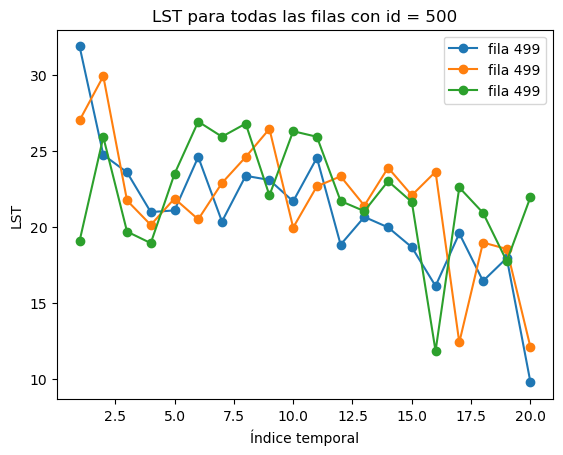

In [176]:
import matplotlib.pyplot as plt

# Filtrar todas las filas con id == 2000
rows = LST_Camino[LST_Camino['id'] == 500]

# Columnas NDVI_*
ndvi_cols = [c for c in LST_Camino.columns if c.startswith('LST_')]
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Eje X = número de NDVI
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Graficar todas las filas
plt.figure()
for idx, row in rows.iterrows():
    ndvi_values = row[ndvi_cols].values
    plt.plot(x, ndvi_values, marker='o', label=f'fila {idx}')

plt.xlabel('Índice temporal')
plt.ylabel('LST')
plt.title('LST para todas las filas con id = 500')
plt.legend()
plt.show()

In [450]:
LST_Camino.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/Camino_BiomasaLST.csv', index=False)

## Grande 2020

In [178]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Grande2020.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Grande2020 = pd.DataFrame(rows_final)

In [179]:
Grande2020

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2020-06-05,0.354573,1.071984,0.120153,0.219382,0.367733,2020-06-20,0.489158,0.819929,...,1.118685,0.205724,0.318782,0.141066,2020-10-26,0.380783,1.456701,0.103527,0.206218,0.195592
1,2,2020-06-05,0.322264,1.093893,0.111088,0.202333,0.383997,2020-06-20,0.466000,0.846436,...,1.078308,0.226502,0.327404,0.117494,2020-10-26,0.397138,1.452653,0.112232,0.209340,0.166479
2,3,2020-06-05,0.330394,1.117591,0.103139,0.205708,0.438665,2020-06-20,0.470625,0.872370,...,1.061081,0.235594,0.346859,0.135041,2020-10-26,0.395349,1.384906,0.139172,0.206373,0.076046
3,4,2020-06-05,0.317250,1.128392,0.098910,0.183646,0.367762,2020-06-20,0.455172,0.903769,...,1.060221,0.233607,0.337901,0.121134,2020-10-26,0.388468,1.475844,0.104532,0.198968,0.169383
4,5,2020-06-05,0.337676,0.975360,0.186161,0.214286,-0.007681,2020-06-20,0.566371,0.664225,...,1.022960,0.223937,0.322668,0.116498,2020-10-26,0.397295,1.224743,0.179661,0.209660,-0.045798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2020-06-05,0.281816,1.160983,0.075092,0.150661,0.399862,2020-06-20,0.428280,0.848020,...,1.023664,0.234139,0.372725,0.179948,2020-10-26,0.399313,1.362298,0.118321,0.212885,0.171292
467,468,2020-06-05,0.279605,1.161081,0.075591,0.151936,0.410290,2020-06-20,0.424509,0.832980,...,1.061491,0.226978,0.354459,0.164146,2020-10-26,0.394261,1.408841,0.121751,0.207214,0.140265
468,469,2020-06-05,0.297519,1.027921,0.153477,0.170584,-0.097449,2020-06-20,0.481560,0.938780,...,0.945458,0.230259,0.382851,0.200466,2020-10-26,0.405319,1.391577,0.137585,0.228242,0.151930
469,470,2020-06-05,0.301022,1.152078,0.086350,0.165792,0.372090,2020-06-20,0.457171,0.961590,...,0.969882,0.246259,0.381113,0.166038,2020-10-26,0.428338,1.368782,0.145946,0.223505,0.093408


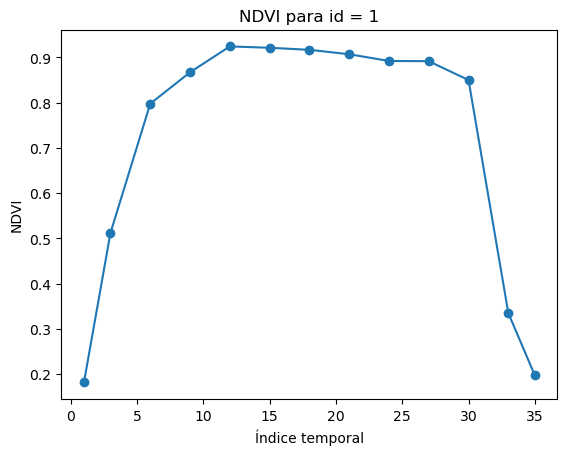

In [180]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Grande2020[Grande2020['id'] == 100].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Grande2020.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()

In [184]:
import geopandas as gpd

# Cargar el shapefile
Grande2020_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\grande_2020\Clean_Data2020/Puntos_Yield_Grande2020_Final.shp")
Grande2020_SHP = Grande2020_SHP.drop(columns= 'geometry', axis=1)
Grande2020_SHP

,id,value
0,1.0,14.645684
1,2.0,17.435793
2,3.0,16.217045
3,4.0,17.172660
4,5.0,16.028810
...,...,...
466,467.0,15.436272
467,468.0,15.397686
468,469.0,15.805475
469,470.0,13.940990


In [186]:
coe_Grande2020 = (6.455175278390021 / 10) * 15

In [188]:
coe_Grande2020

9.68276291758503

In [190]:
Grande2020_SHP['biomasa'] = Grande2020_SHP['value'] * coe_Grande2020
Grande2020_SHP = Grande2020_SHP.drop('value', axis=1)
Grande2020_SHP

,id,biomasa
0,1.0,141.810686
1,2.0,168.826650
2,3.0,157.025802
3,4.0,166.278795
4,5.0,155.203167
...,...,...
466,467.0,149.465762
467,468.0,149.092143
468,469.0,153.040667
469,470.0,134.987301


In [192]:
Grande2020 = pd.merge(Grande2020, Grande2020_SHP, on='id', how='inner')
Grande2020

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-05,0.354573,1.071984,0.120153,0.219382,0.367733,2020-06-20,0.489158,0.819929,...,0.205724,0.318782,0.141066,2020-10-26,0.380783,1.456701,0.103527,0.206218,0.195592,141.810686
1,2,2020-06-05,0.322264,1.093893,0.111088,0.202333,0.383997,2020-06-20,0.466000,0.846436,...,0.226502,0.327404,0.117494,2020-10-26,0.397138,1.452653,0.112232,0.209340,0.166479,168.826650
2,3,2020-06-05,0.330394,1.117591,0.103139,0.205708,0.438665,2020-06-20,0.470625,0.872370,...,0.235594,0.346859,0.135041,2020-10-26,0.395349,1.384906,0.139172,0.206373,0.076046,157.025802
3,4,2020-06-05,0.317250,1.128392,0.098910,0.183646,0.367762,2020-06-20,0.455172,0.903769,...,0.233607,0.337901,0.121134,2020-10-26,0.388468,1.475844,0.104532,0.198968,0.169383,166.278795
4,5,2020-06-05,0.337676,0.975360,0.186161,0.214286,-0.007681,2020-06-20,0.566371,0.664225,...,0.223937,0.322668,0.116498,2020-10-26,0.397295,1.224743,0.179661,0.209660,-0.045798,155.203167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2020-06-05,0.281816,1.160983,0.075092,0.150661,0.399862,2020-06-20,0.428280,0.848020,...,0.234139,0.372725,0.179948,2020-10-26,0.399313,1.362298,0.118321,0.212885,0.171292,149.465762
467,468,2020-06-05,0.279605,1.161081,0.075591,0.151936,0.410290,2020-06-20,0.424509,0.832980,...,0.226978,0.354459,0.164146,2020-10-26,0.394261,1.408841,0.121751,0.207214,0.140265,149.092143
468,469,2020-06-05,0.297519,1.027921,0.153477,0.170584,-0.097449,2020-06-20,0.481560,0.938780,...,0.230259,0.382851,0.200466,2020-10-26,0.405319,1.391577,0.137585,0.228242,0.151930,153.040667
469,470,2020-06-05,0.301022,1.152078,0.086350,0.165792,0.372090,2020-06-20,0.457171,0.961590,...,0.246259,0.381113,0.166038,2020-10-26,0.428338,1.368782,0.145946,0.223505,0.093408,134.987301


### LST

In [195]:
LST_Grande2020 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Grande2020_2.csv')
LST_Grande2020 = LST_Grande2020.drop(columns=['geo','lon','lat'], axis=1)
LST_Grande2020

,id,date,LST
0,1,01/06/2020,28.461417
1,2,01/06/2020,28.461417
2,3,01/06/2020,28.461417
3,4,01/06/2020,29.012634
4,5,01/06/2020,29.853021
...,...,...,...
9415,467,15/10/2020,14.922014
9416,468,15/10/2020,14.922014
9417,469,15/10/2020,15.059733
9418,470,15/10/2020,15.059733


In [197]:
import numpy as np
import pandas as pd

df = LST_Grande2020

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Grande2020 = pd.DataFrame(rows_final)

In [198]:
LST_Grande2020 = pd.merge(LST_Grande2020, Grande2020, on='id', how='inner')
LST_Grande2020

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-01,28.461417,2020-06-09,22.780833,2020-06-16,20.300790,2020-07-03,21.574322,2020-07-10,...,0.205724,0.318782,0.141066,2020-10-26,0.380783,1.456701,0.103527,0.206218,0.195592,141.810686
1,2,2020-06-01,28.461417,2020-06-09,22.780833,2020-06-16,20.300790,2020-07-03,21.574322,2020-07-10,...,0.226502,0.327404,0.117494,2020-10-26,0.397138,1.452653,0.112232,0.209340,0.166479,168.826650
2,3,2020-06-01,28.461417,2020-06-09,22.780833,2020-06-16,20.300790,2020-07-03,21.574322,2020-07-10,...,0.235594,0.346859,0.135041,2020-10-26,0.395349,1.384906,0.139172,0.206373,0.076046,157.025802
3,4,2020-06-01,29.012634,2020-06-09,22.946816,2020-06-16,20.893353,2020-07-03,22.135620,2020-07-10,...,0.233607,0.337901,0.121134,2020-10-26,0.388468,1.475844,0.104532,0.198968,0.169383,166.278795
4,5,2020-06-01,29.853021,2020-06-09,24.047553,2020-06-16,20.261439,2020-07-03,21.681024,2020-07-10,...,0.223937,0.322668,0.116498,2020-10-26,0.397295,1.224743,0.179661,0.209660,-0.045798,155.203167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2020-06-01,31.325533,2020-06-09,23.527510,2020-06-16,14.417893,2020-07-03,21.135011,2020-07-10,...,0.234139,0.372725,0.179948,2020-10-26,0.399313,1.362298,0.118321,0.212885,0.171292,149.465762
467,468,2020-06-01,32.363626,2020-06-09,23.527510,2020-06-16,14.316831,2020-07-03,21.135181,2020-07-10,...,0.226978,0.354459,0.164146,2020-10-26,0.394261,1.408841,0.121751,0.207214,0.140265,149.092143
468,469,2020-06-01,29.803274,2020-06-09,23.038299,2020-06-16,14.614748,2020-07-03,21.117276,2020-07-10,...,0.230259,0.382851,0.200466,2020-10-26,0.405319,1.391577,0.137585,0.228242,0.151930,153.040667
469,470,2020-06-01,29.803274,2020-06-09,23.038299,2020-06-16,14.614748,2020-07-03,21.117276,2020-07-10,...,0.246259,0.381113,0.166038,2020-10-26,0.428338,1.368782,0.145946,0.223505,0.093408,134.987301


## Grande 2021

In [201]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Grande2021.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Grande2021 = pd.DataFrame(rows_final)

In [202]:
Grande2021

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2021-06-05,0.352706,1.328679,0.096988,0.197428,0.307686,2021-06-10,0.388393,1.181301,...,1.418496,0.205026,0.292199,0.085843,2021-11-10,0.460991,1.564558,0.180110,0.225866,-0.024330
1,2,2021-06-05,0.359522,1.299334,0.108323,0.211486,0.302492,2021-06-10,0.411974,1.189104,...,1.445531,0.190753,0.288465,0.110002,2021-11-10,0.448926,1.603951,0.159745,0.229877,0.051909
2,3,2021-06-05,0.377990,1.242798,0.129494,0.231549,0.271102,2021-06-10,0.443040,1.143802,...,1.415982,0.201381,0.295056,0.094184,2021-11-10,0.456924,1.558257,0.173930,0.235891,0.027762
3,4,2021-06-05,0.383686,1.248009,0.138554,0.234306,0.238691,2021-06-10,0.443499,1.124459,...,1.428137,0.204595,0.299336,0.095201,2021-11-10,0.436145,1.595078,0.173382,0.228866,0.019386
4,5,2021-06-05,0.352249,1.324718,0.107474,0.203573,0.292684,2021-06-10,0.404997,1.182144,...,1.415985,0.191614,0.297929,0.118920,2021-11-10,0.451304,1.763510,0.058629,0.231404,0.330710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2021-06-05,0.296528,1.219041,0.096376,0.160803,0.268877,2021-06-10,0.361753,1.165051,...,1.330057,0.215532,0.279709,0.016552,2021-11-10,0.428749,1.490299,0.164804,0.217680,0.011170
467,468,2021-06-05,0.295576,1.202251,0.103920,0.167963,0.264416,2021-06-10,0.353154,1.134983,...,1.376283,0.196509,0.275233,0.066391,2021-11-10,0.408740,1.530571,0.156137,0.214801,0.039936
468,469,2021-06-05,0.310769,1.232688,0.100834,0.164730,0.227448,2021-06-10,0.350702,1.179560,...,1.369506,0.194426,0.297202,0.123786,2021-11-10,0.448418,1.537752,0.154441,0.229690,0.067025
469,470,2021-06-05,0.307907,1.270103,0.074593,0.170295,0.475546,2021-06-10,0.362032,1.178642,...,1.376952,0.197678,0.278485,0.062600,2021-11-10,0.428261,1.494020,0.168297,0.235460,0.059193


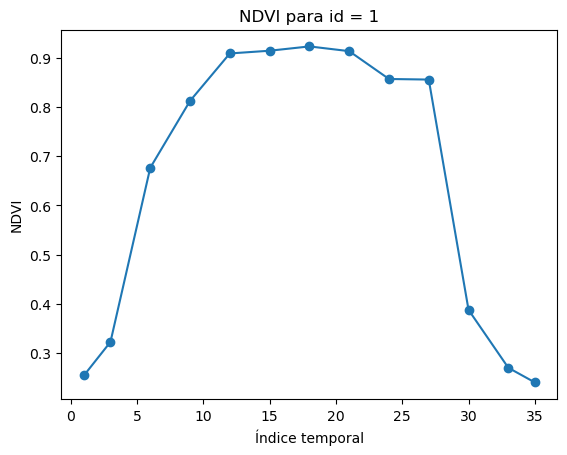

In [205]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Grande2021[Grande2021['id'] == 100].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Grande2021.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()

In [207]:
import geopandas as gpd

# Cargar el shapefile
Grande2021_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\grande_2021\Clean_Data2021/Puntos_Yield_Grande2021_Final.shp")
Grande2021_SHP = Grande2021_SHP.drop(columns= 'geometry', axis=1)
Grande2021_SHP

,id,value
0,1.0,14.364097
1,2.0,12.092672
2,3.0,13.394433
3,4.0,15.053823
4,5.0,15.039466
...,...,...
466,467.0,16.524151
467,468.0,11.535646
468,469.0,12.783294
469,470.0,17.229250


In [209]:
coe_Grande2021 = (5.929368507098011 / 10) * 15

In [211]:
coe_Grande2021

8.894052760647016

In [213]:
Grande2021_SHP['biomasa'] = Grande2021_SHP['value'] * coe_Grande2021
Grande2021_SHP = Grande2021_SHP.drop('value', axis=1)
Grande2021_SHP

,id,biomasa
0,1.0,127.755037
1,2.0,107.552863
2,3.0,119.130794
3,4.0,133.889496
4,5.0,133.761804
...,...,...
466,467.0,146.966671
467,468.0,102.598644
468,469.0,113.695291
469,470.0,153.237859


In [215]:
Grande2021 = pd.merge(Grande2021, Grande2021_SHP, on='id', how='inner')
Grande2021

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2021-06-05,0.352706,1.328679,0.096988,0.197428,0.307686,2021-06-10,0.388393,1.181301,...,0.205026,0.292199,0.085843,2021-11-10,0.460991,1.564558,0.180110,0.225866,-0.024330,127.755037
1,2,2021-06-05,0.359522,1.299334,0.108323,0.211486,0.302492,2021-06-10,0.411974,1.189104,...,0.190753,0.288465,0.110002,2021-11-10,0.448926,1.603951,0.159745,0.229877,0.051909,107.552863
2,3,2021-06-05,0.377990,1.242798,0.129494,0.231549,0.271102,2021-06-10,0.443040,1.143802,...,0.201381,0.295056,0.094184,2021-11-10,0.456924,1.558257,0.173930,0.235891,0.027762,119.130794
3,4,2021-06-05,0.383686,1.248009,0.138554,0.234306,0.238691,2021-06-10,0.443499,1.124459,...,0.204595,0.299336,0.095201,2021-11-10,0.436145,1.595078,0.173382,0.228866,0.019386,133.889496
4,5,2021-06-05,0.352249,1.324718,0.107474,0.203573,0.292684,2021-06-10,0.404997,1.182144,...,0.191614,0.297929,0.118920,2021-11-10,0.451304,1.763510,0.058629,0.231404,0.330710,133.761804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2021-06-05,0.296528,1.219041,0.096376,0.160803,0.268877,2021-06-10,0.361753,1.165051,...,0.215532,0.279709,0.016552,2021-11-10,0.428749,1.490299,0.164804,0.217680,0.011170,146.966671
467,468,2021-06-05,0.295576,1.202251,0.103920,0.167963,0.264416,2021-06-10,0.353154,1.134983,...,0.196509,0.275233,0.066391,2021-11-10,0.408740,1.530571,0.156137,0.214801,0.039936,102.598644
468,469,2021-06-05,0.310769,1.232688,0.100834,0.164730,0.227448,2021-06-10,0.350702,1.179560,...,0.194426,0.297202,0.123786,2021-11-10,0.448418,1.537752,0.154441,0.229690,0.067025,113.695291
469,470,2021-06-05,0.307907,1.270103,0.074593,0.170295,0.475546,2021-06-10,0.362032,1.178642,...,0.197678,0.278485,0.062600,2021-11-10,0.428261,1.494020,0.168297,0.235460,0.059193,153.237859


### LST

In [218]:
LST_Grande2021 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Grande2021_2.csv')
LST_Grande2021 = LST_Grande2021.drop(columns=['geo','lon','lat'], axis=1)
LST_Grande2021

,id,date,LST
0,1,04/06/2021,26.184926
1,2,04/06/2021,26.184926
2,3,04/06/2021,26.184926
3,4,04/06/2021,26.171084
4,5,04/06/2021,27.403737
...,...,...,...
9415,467,10/11/2021,10.441584
9416,468,10/11/2021,10.441584
9417,469,10/11/2021,10.243748
9418,470,10/11/2021,10.308868


In [220]:
import numpy as np
import pandas as pd

df = LST_Grande2021

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Grande2021 = pd.DataFrame(rows_final)

In [221]:
LST_Grande2021 = pd.merge(LST_Grande2021, Grande2021, on='id', how='inner')
LST_Grande2021

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2021-06-04,26.184926,2021-06-12,29.463168,2021-06-19,20.549878,2021-07-05,24.153871,2021-07-13,...,0.205026,0.292199,0.085843,2021-11-10,0.460991,1.564558,0.180110,0.225866,-0.024330,127.755037
1,2,2021-06-04,26.184926,2021-06-12,29.463168,2021-06-19,20.549878,2021-07-05,24.153871,2021-07-13,...,0.190753,0.288465,0.110002,2021-11-10,0.448926,1.603951,0.159745,0.229877,0.051909,107.552863
2,3,2021-06-04,26.184926,2021-06-12,29.463168,2021-06-19,20.549878,2021-07-05,24.153871,2021-07-13,...,0.201381,0.295056,0.094184,2021-11-10,0.456924,1.558257,0.173930,0.235891,0.027762,119.130794
3,4,2021-06-04,26.171084,2021-06-12,29.909239,2021-06-19,20.520108,2021-07-05,24.252651,2021-07-13,...,0.204595,0.299336,0.095201,2021-11-10,0.436145,1.595078,0.173382,0.228866,0.019386,133.889496
4,5,2021-06-04,27.403737,2021-06-12,30.203192,2021-06-19,20.497856,2021-07-05,24.232777,2021-07-13,...,0.191614,0.297929,0.118920,2021-11-10,0.451304,1.763510,0.058629,0.231404,0.330710,133.761804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2021-06-04,23.944663,2021-06-12,31.779853,2021-06-19,20.500839,2021-07-05,24.038426,2021-07-13,...,0.215532,0.279709,0.016552,2021-11-10,0.428749,1.490299,0.164804,0.217680,0.011170,146.966671
467,468,2021-06-04,23.957146,2021-06-12,31.779853,2021-06-19,20.500839,2021-07-05,24.038426,2021-07-13,...,0.196509,0.275233,0.066391,2021-11-10,0.408740,1.530571,0.156137,0.214801,0.039936,102.598644
468,469,2021-06-04,23.761479,2021-06-12,31.678321,2021-06-19,20.302833,2021-07-05,24.170171,2021-07-13,...,0.194426,0.297202,0.123786,2021-11-10,0.448418,1.537752,0.154441,0.229690,0.067025,113.695291
469,470,2021-06-04,23.761479,2021-06-12,31.678321,2021-06-19,20.381056,2021-07-05,24.109201,2021-07-13,...,0.197678,0.278485,0.062600,2021-11-10,0.428261,1.494020,0.168297,0.235460,0.059193,153.237859


## Grande Final

In [224]:
Grande = pd.concat([Grande2020, Grande2021])
Grande

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-05,0.354573,1.071984,0.120153,0.219382,0.367733,2020-06-20,0.489158,0.819929,...,0.205724,0.318782,0.141066,2020-10-26,0.380783,1.456701,0.103527,0.206218,0.195592,141.810686
1,2,2020-06-05,0.322264,1.093893,0.111088,0.202333,0.383997,2020-06-20,0.466000,0.846436,...,0.226502,0.327404,0.117494,2020-10-26,0.397138,1.452653,0.112232,0.209340,0.166479,168.826650
2,3,2020-06-05,0.330394,1.117591,0.103139,0.205708,0.438665,2020-06-20,0.470625,0.872370,...,0.235594,0.346859,0.135041,2020-10-26,0.395349,1.384906,0.139172,0.206373,0.076046,157.025802
3,4,2020-06-05,0.317250,1.128392,0.098910,0.183646,0.367762,2020-06-20,0.455172,0.903769,...,0.233607,0.337901,0.121134,2020-10-26,0.388468,1.475844,0.104532,0.198968,0.169383,166.278795
4,5,2020-06-05,0.337676,0.975360,0.186161,0.214286,-0.007681,2020-06-20,0.566371,0.664225,...,0.223937,0.322668,0.116498,2020-10-26,0.397295,1.224743,0.179661,0.209660,-0.045798,155.203167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2021-06-05,0.296528,1.219041,0.096376,0.160803,0.268877,2021-06-10,0.361753,1.165051,...,0.215532,0.279709,0.016552,2021-11-10,0.428749,1.490299,0.164804,0.217680,0.011170,146.966671
467,468,2021-06-05,0.295576,1.202251,0.103920,0.167963,0.264416,2021-06-10,0.353154,1.134983,...,0.196509,0.275233,0.066391,2021-11-10,0.408740,1.530571,0.156137,0.214801,0.039936,102.598644
468,469,2021-06-05,0.310769,1.232688,0.100834,0.164730,0.227448,2021-06-10,0.350702,1.179560,...,0.194426,0.297202,0.123786,2021-11-10,0.448418,1.537752,0.154441,0.229690,0.067025,113.695291
469,470,2021-06-05,0.307907,1.270103,0.074593,0.170295,0.475546,2021-06-10,0.362032,1.178642,...,0.197678,0.278485,0.062600,2021-11-10,0.428261,1.494020,0.168297,0.235460,0.059193,153.237859


In [226]:
cols_to_drop = [c for c in Grande.columns if c.startswith('date_')]
Grande = Grande.drop(cols_to_drop, axis=1)

In [228]:
Grande

,id,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,GNDVI_3,MSI_3,NDRE_3,NDVI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,0.354573,1.071984,0.120153,0.219382,0.367733,0.489158,0.819929,0.302603,0.409883,...,1.118685,0.205724,0.318782,0.141066,0.380783,1.456701,0.103527,0.206218,0.195592,141.810686
1,2,0.322264,1.093893,0.111088,0.202333,0.383997,0.466000,0.846436,0.287801,0.397688,...,1.078308,0.226502,0.327404,0.117494,0.397138,1.452653,0.112232,0.209340,0.166479,168.826650
2,3,0.330394,1.117591,0.103139,0.205708,0.438665,0.470625,0.872370,0.262692,0.414912,...,1.061081,0.235594,0.346859,0.135041,0.395349,1.384906,0.139172,0.206373,0.076046,157.025802
3,4,0.317250,1.128392,0.098910,0.183646,0.367762,0.455172,0.903769,0.244886,0.371559,...,1.060221,0.233607,0.337901,0.121134,0.388468,1.475844,0.104532,0.198968,0.169383,166.278795
4,5,0.337676,0.975360,0.186161,0.214286,-0.007681,0.566371,0.664225,0.392954,0.537162,...,1.022960,0.223937,0.322668,0.116498,0.397295,1.224743,0.179661,0.209660,-0.045798,155.203167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,0.296528,1.219041,0.096376,0.160803,0.268877,0.361753,1.165051,0.122254,0.234949,...,1.330057,0.215532,0.279709,0.016552,0.428749,1.490299,0.164804,0.217680,0.011170,146.966671
467,468,0.295576,1.202251,0.103920,0.167963,0.264416,0.353154,1.134983,0.129661,0.226336,...,1.376283,0.196509,0.275233,0.066391,0.408740,1.530571,0.156137,0.214801,0.039936,102.598644
468,469,0.310769,1.232688,0.100834,0.164730,0.227448,0.350702,1.179560,0.144674,0.221112,...,1.369506,0.194426,0.297202,0.123786,0.448418,1.537752,0.154441,0.229690,0.067025,113.695291
469,470,0.307907,1.270103,0.074593,0.170295,0.475546,0.362032,1.178642,0.125684,0.233265,...,1.376952,0.197678,0.278485,0.062600,0.428261,1.494020,0.168297,0.235460,0.059193,153.237859


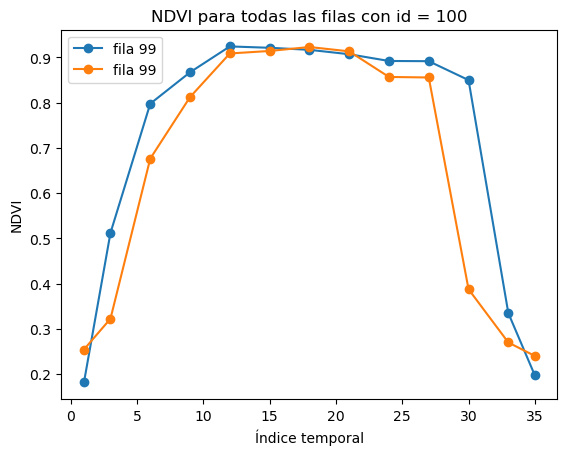

In [230]:
import matplotlib.pyplot as plt

# Filtrar todas las filas con id == 2000
rows = Grande[Grande['id'] == 100]

# Columnas NDVI_*
ndvi_cols = [c for c in Grande.columns if c.startswith('NDVI_')]
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Eje X = número de NDVI
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Graficar todas las filas
plt.figure()
for idx, row in rows.iterrows():
    ndvi_values = row[ndvi_cols].values
    plt.plot(x, ndvi_values, marker='o', label=f'fila {idx}')

plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para todas las filas con id = 100')
plt.legend()
plt.show()

In [643]:
Grande.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/Grande_BiomasaIV.csv', index=False)

### LST

In [232]:
LST_Grande = pd.concat([LST_Grande2020, LST_Grande2021])
LST_Grande

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-01,28.461417,2020-06-09,22.780833,2020-06-16,20.300790,2020-07-03,21.574322,2020-07-10,...,0.205724,0.318782,0.141066,2020-10-26,0.380783,1.456701,0.103527,0.206218,0.195592,141.810686
1,2,2020-06-01,28.461417,2020-06-09,22.780833,2020-06-16,20.300790,2020-07-03,21.574322,2020-07-10,...,0.226502,0.327404,0.117494,2020-10-26,0.397138,1.452653,0.112232,0.209340,0.166479,168.826650
2,3,2020-06-01,28.461417,2020-06-09,22.780833,2020-06-16,20.300790,2020-07-03,21.574322,2020-07-10,...,0.235594,0.346859,0.135041,2020-10-26,0.395349,1.384906,0.139172,0.206373,0.076046,157.025802
3,4,2020-06-01,29.012634,2020-06-09,22.946816,2020-06-16,20.893353,2020-07-03,22.135620,2020-07-10,...,0.233607,0.337901,0.121134,2020-10-26,0.388468,1.475844,0.104532,0.198968,0.169383,166.278795
4,5,2020-06-01,29.853021,2020-06-09,24.047553,2020-06-16,20.261439,2020-07-03,21.681024,2020-07-10,...,0.223937,0.322668,0.116498,2020-10-26,0.397295,1.224743,0.179661,0.209660,-0.045798,155.203167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2021-06-04,23.944663,2021-06-12,31.779853,2021-06-19,20.500839,2021-07-05,24.038426,2021-07-13,...,0.215532,0.279709,0.016552,2021-11-10,0.428749,1.490299,0.164804,0.217680,0.011170,146.966671
467,468,2021-06-04,23.957146,2021-06-12,31.779853,2021-06-19,20.500839,2021-07-05,24.038426,2021-07-13,...,0.196509,0.275233,0.066391,2021-11-10,0.408740,1.530571,0.156137,0.214801,0.039936,102.598644
468,469,2021-06-04,23.761479,2021-06-12,31.678321,2021-06-19,20.302833,2021-07-05,24.170171,2021-07-13,...,0.194426,0.297202,0.123786,2021-11-10,0.448418,1.537752,0.154441,0.229690,0.067025,113.695291
469,470,2021-06-04,23.761479,2021-06-12,31.678321,2021-06-19,20.381056,2021-07-05,24.109201,2021-07-13,...,0.197678,0.278485,0.062600,2021-11-10,0.428261,1.494020,0.168297,0.235460,0.059193,153.237859


In [233]:
cols_to_drop = [c for c in LST_Grande.columns if c.startswith('date_')]
LST_Grande = LST_Grande.drop(cols_to_drop, axis=1)
LST_Grande

,id,LST_1,LST_2,LST_3,LST_4,LST_5,LST_6,LST_7,LST_8,LST_9,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,28.461417,22.780833,20.300790,21.574322,23.090763,23.535177,25.258464,25.108102,27.384076,...,1.118685,0.205724,0.318782,0.141066,0.380783,1.456701,0.103527,0.206218,0.195592,141.810686
1,2,28.461417,22.780833,20.300790,21.574322,23.090763,23.535177,25.258464,25.108102,27.384076,...,1.078308,0.226502,0.327404,0.117494,0.397138,1.452653,0.112232,0.209340,0.166479,168.826650
2,3,28.461417,22.780833,20.300790,21.574322,23.090763,23.535177,25.258464,25.108102,27.384076,...,1.061081,0.235594,0.346859,0.135041,0.395349,1.384906,0.139172,0.206373,0.076046,157.025802
3,4,29.012634,22.946816,20.893353,22.135620,23.422112,23.693219,25.517415,25.135370,27.402819,...,1.060221,0.233607,0.337901,0.121134,0.388468,1.475844,0.104532,0.198968,0.169383,166.278795
4,5,29.853021,24.047553,20.261439,21.681024,22.617786,23.363029,24.823205,24.661400,27.215345,...,1.022960,0.223937,0.322668,0.116498,0.397295,1.224743,0.179661,0.209660,-0.045798,155.203167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,23.944663,31.779853,20.500839,24.038426,16.696062,6.503895,26.282763,24.113976,21.497616,...,1.330057,0.215532,0.279709,0.016552,0.428749,1.490299,0.164804,0.217680,0.011170,146.966671
467,468,23.957146,31.779853,20.500839,24.038426,16.893236,6.503895,26.282763,24.113976,21.497616,...,1.376283,0.196509,0.275233,0.066391,0.408740,1.530571,0.156137,0.214801,0.039936,102.598644
468,469,23.761479,31.678321,20.302833,24.170171,15.284941,6.498153,26.085780,23.870836,21.256483,...,1.369506,0.194426,0.297202,0.123786,0.448418,1.537752,0.154441,0.229690,0.067025,113.695291
469,470,23.761479,31.678321,20.381056,24.109201,15.787830,6.498153,26.125308,23.870836,21.309545,...,1.376952,0.197678,0.278485,0.062600,0.428261,1.494020,0.168297,0.235460,0.059193,153.237859


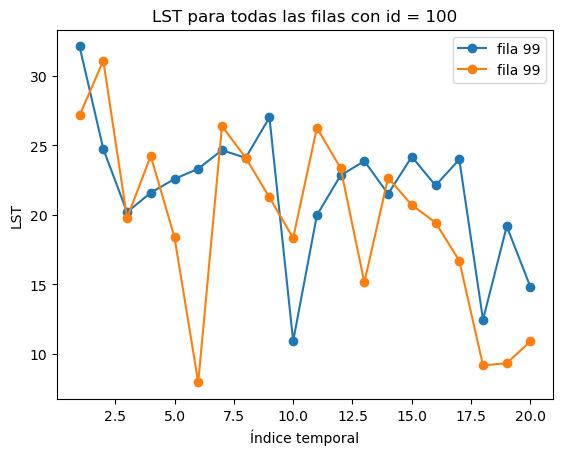

In [236]:
import matplotlib.pyplot as plt

# Filtrar todas las filas con id == 2000
rows = LST_Grande[LST_Grande['id'] == 100]

# Columnas NDVI_*
ndvi_cols = [c for c in LST_Grande.columns if c.startswith('LST_')]
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Eje X = número de NDVI
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Graficar todas las filas
plt.figure()
for idx, row in rows.iterrows():
    ndvi_values = row[ndvi_cols].values
    plt.plot(x, ndvi_values, marker='o', label=f'fila {idx}')

plt.xlabel('Índice temporal')
plt.ylabel('LST')
plt.title('LST para todas las filas con id = 100')
plt.legend()
plt.show()

In [652]:
LST_Grande.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/Grande_BiomasaLST.csv', index=False)

## Bodega 2020

In [323]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Bodega2020.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Bodega2020 = pd.DataFrame(rows_final)

In [325]:
Bodega2020

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2020-06-05,0.366031,1.279498,0.100531,0.252702,0.460497,2020-06-23,0.454062,1.097622,...,1.252316,0.192333,0.289529,0.142698,2020-10-28,0.361783,1.302152,0.218234,0.279473,0.114502
1,2,2020-06-05,0.371378,1.279770,0.103809,0.254618,0.443947,2020-06-23,0.455777,1.040377,...,1.214020,0.208116,0.301313,0.106370,2020-10-28,0.393760,1.311970,0.214654,0.287621,0.124290
2,3,2020-06-05,0.384801,1.223996,0.130729,0.253988,0.336813,2020-06-23,0.454906,0.992197,...,1.179267,0.225601,0.327470,0.130043,2020-10-28,0.438442,1.180786,0.256861,0.328306,0.101983
3,4,2020-06-05,0.389646,1.187745,0.138075,0.251726,0.301844,2020-06-23,0.516519,0.946592,...,1.162962,0.231577,0.317555,0.093110,2020-10-28,0.448082,1.164513,0.263330,0.381321,0.192071
4,5,2020-06-05,0.413333,1.149473,0.152499,0.278909,0.305446,2020-06-23,0.504879,0.939818,...,1.174647,0.225687,0.325932,0.125153,2020-10-28,0.454914,1.168988,0.241499,0.390126,0.230421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2020-06-05,0.433933,1.325320,0.097062,0.221135,0.303390,2020-06-23,0.586944,0.931442,...,1.173784,0.216165,0.318665,0.128226,2020-10-28,0.348021,1.564770,0.123427,0.197101,0.138857
213,214,2020-06-05,0.421287,1.244857,0.127980,0.222512,0.203435,2020-06-23,0.591164,0.896677,...,1.190961,0.209230,0.324340,0.147884,2020-10-28,0.338302,1.599629,0.112565,0.192620,0.169829
214,215,2020-06-05,0.428225,1.232784,0.129090,0.215264,0.165311,2020-06-23,0.575747,0.919388,...,1.191886,0.210945,0.318736,0.137821,2020-10-28,0.343946,1.618454,0.129577,0.196122,0.113944
215,216,2020-06-05,0.419355,1.249140,0.122604,0.209510,0.176855,2020-06-23,0.568496,0.953577,...,1.147484,0.229008,0.320970,0.110226,2020-10-28,0.354523,1.561974,0.146998,0.202605,0.069334


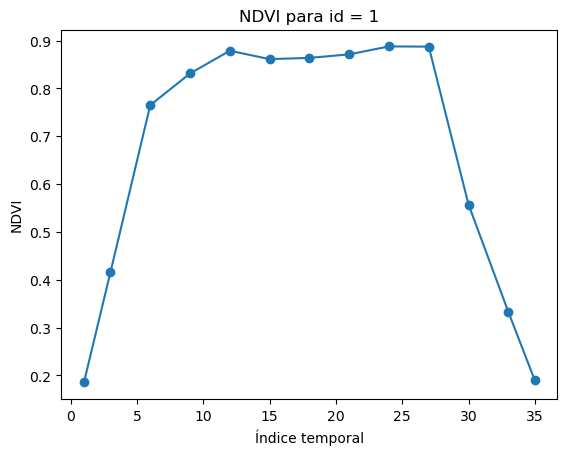

In [327]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Bodega2020[Bodega2020['id'] == 100].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Bodega2020.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()

In [329]:
import geopandas as gpd

# Cargar el shapefile
Bodega2020_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\bodegas_2020\Clean_Data2020/Puntos_Yield_Bodega2020_Final.shp")
Bodega2020_SHP = Bodega2020_SHP.drop(columns= 'geometry', axis=1)
Bodega2020_SHP

,id,value
0,1.0,11.871689
1,2.0,11.043060
2,3.0,11.382820
3,4.0,10.429980
4,5.0,13.198873
...,...,...
212,213.0,8.841825
213,214.0,8.794938
214,215.0,7.749779
215,216.0,6.674577


In [331]:
coe_Bodega2020 = (5.511073017345288 / 10) * 15

In [332]:
coe_Bodega2020

8.266609526017932

In [335]:
Bodega2020_SHP['biomasa'] = Bodega2020_SHP['value'] * coe_Bodega2020
Bodega2020_SHP = Bodega2020_SHP.drop('value', axis=1)
Bodega2020_SHP

,id,biomasa
0,1.0,98.138616
1,2.0,91.288667
2,3.0,94.097329
3,4.0,86.220574
4,5.0,109.109926
...,...,...
212,213.0,73.091919
213,214.0,72.704319
214,215.0,64.064395
215,216.0,55.176120


In [337]:
Bodega2020 = pd.merge(Bodega2020, Bodega2020_SHP, on='id', how='inner')
Bodega2020

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-05,0.366031,1.279498,0.100531,0.252702,0.460497,2020-06-23,0.454062,1.097622,...,0.192333,0.289529,0.142698,2020-10-28,0.361783,1.302152,0.218234,0.279473,0.114502,98.138616
1,2,2020-06-05,0.371378,1.279770,0.103809,0.254618,0.443947,2020-06-23,0.455777,1.040377,...,0.208116,0.301313,0.106370,2020-10-28,0.393760,1.311970,0.214654,0.287621,0.124290,91.288667
2,3,2020-06-05,0.384801,1.223996,0.130729,0.253988,0.336813,2020-06-23,0.454906,0.992197,...,0.225601,0.327470,0.130043,2020-10-28,0.438442,1.180786,0.256861,0.328306,0.101983,94.097329
3,4,2020-06-05,0.389646,1.187745,0.138075,0.251726,0.301844,2020-06-23,0.516519,0.946592,...,0.231577,0.317555,0.093110,2020-10-28,0.448082,1.164513,0.263330,0.381321,0.192071,86.220574
4,5,2020-06-05,0.413333,1.149473,0.152499,0.278909,0.305446,2020-06-23,0.504879,0.939818,...,0.225687,0.325932,0.125153,2020-10-28,0.454914,1.168988,0.241499,0.390126,0.230421,109.109926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2020-06-05,0.433933,1.325320,0.097062,0.221135,0.303390,2020-06-23,0.586944,0.931442,...,0.216165,0.318665,0.128226,2020-10-28,0.348021,1.564770,0.123427,0.197101,0.138857,73.091919
213,214,2020-06-05,0.421287,1.244857,0.127980,0.222512,0.203435,2020-06-23,0.591164,0.896677,...,0.209230,0.324340,0.147884,2020-10-28,0.338302,1.599629,0.112565,0.192620,0.169829,72.704319
214,215,2020-06-05,0.428225,1.232784,0.129090,0.215264,0.165311,2020-06-23,0.575747,0.919388,...,0.210945,0.318736,0.137821,2020-10-28,0.343946,1.618454,0.129577,0.196122,0.113944,64.064395
215,216,2020-06-05,0.419355,1.249140,0.122604,0.209510,0.176855,2020-06-23,0.568496,0.953577,...,0.229008,0.320970,0.110226,2020-10-28,0.354523,1.561974,0.146998,0.202605,0.069334,55.176120


In [338]:
Bodega2020

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-05,0.366031,1.279498,0.100531,0.252702,0.460497,2020-06-23,0.454062,1.097622,...,0.192333,0.289529,0.142698,2020-10-28,0.361783,1.302152,0.218234,0.279473,0.114502,98.138616
1,2,2020-06-05,0.371378,1.279770,0.103809,0.254618,0.443947,2020-06-23,0.455777,1.040377,...,0.208116,0.301313,0.106370,2020-10-28,0.393760,1.311970,0.214654,0.287621,0.124290,91.288667
2,3,2020-06-05,0.384801,1.223996,0.130729,0.253988,0.336813,2020-06-23,0.454906,0.992197,...,0.225601,0.327470,0.130043,2020-10-28,0.438442,1.180786,0.256861,0.328306,0.101983,94.097329
3,4,2020-06-05,0.389646,1.187745,0.138075,0.251726,0.301844,2020-06-23,0.516519,0.946592,...,0.231577,0.317555,0.093110,2020-10-28,0.448082,1.164513,0.263330,0.381321,0.192071,86.220574
4,5,2020-06-05,0.413333,1.149473,0.152499,0.278909,0.305446,2020-06-23,0.504879,0.939818,...,0.225687,0.325932,0.125153,2020-10-28,0.454914,1.168988,0.241499,0.390126,0.230421,109.109926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2020-06-05,0.433933,1.325320,0.097062,0.221135,0.303390,2020-06-23,0.586944,0.931442,...,0.216165,0.318665,0.128226,2020-10-28,0.348021,1.564770,0.123427,0.197101,0.138857,73.091919
213,214,2020-06-05,0.421287,1.244857,0.127980,0.222512,0.203435,2020-06-23,0.591164,0.896677,...,0.209230,0.324340,0.147884,2020-10-28,0.338302,1.599629,0.112565,0.192620,0.169829,72.704319
214,215,2020-06-05,0.428225,1.232784,0.129090,0.215264,0.165311,2020-06-23,0.575747,0.919388,...,0.210945,0.318736,0.137821,2020-10-28,0.343946,1.618454,0.129577,0.196122,0.113944,64.064395
215,216,2020-06-05,0.419355,1.249140,0.122604,0.209510,0.176855,2020-06-23,0.568496,0.953577,...,0.229008,0.320970,0.110226,2020-10-28,0.354523,1.561974,0.146998,0.202605,0.069334,55.176120


### LST

In [341]:
LST_Bodega2020 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Bodega2020_2.csv')
LST_Bodega2020 = LST_Bodega2020.drop(columns=['.geo'], axis=1)
LST_Bodega2020

,id,date,LST
0,1,01/06/2020,26.697537
1,2,01/06/2020,26.697537
2,3,01/06/2020,26.662817
3,4,01/06/2020,26.662817
4,5,01/06/2020,27.166333
...,...,...,...
4335,213,07/10/2020,19.782769
4336,214,07/10/2020,19.782769
4337,215,07/10/2020,19.782769
4338,216,07/10/2020,19.782769


In [343]:
import numpy as np
import pandas as pd

df = LST_Bodega2020

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Bodega2020 = pd.DataFrame(rows_final)

In [345]:
LST_Bodega2020 = pd.merge(LST_Bodega2020, Bodega2020, on='id', how='inner')
LST_Bodega2020

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-01,26.697537,2020-06-16,24.498526,2020-07-02,24.390802,2020-07-03,23.360582,2020-07-10,...,0.192333,0.289529,0.142698,2020-10-28,0.361783,1.302152,0.218234,0.279473,0.114502,98.138616
1,2,2020-06-01,26.697537,2020-06-16,24.498526,2020-07-02,24.390802,2020-07-03,23.360582,2020-07-10,...,0.208116,0.301313,0.106370,2020-10-28,0.393760,1.311970,0.214654,0.287621,0.124290,91.288667
2,3,2020-06-01,26.662817,2020-06-16,24.454817,2020-07-02,24.303648,2020-07-03,23.360582,2020-07-10,...,0.225601,0.327470,0.130043,2020-10-28,0.438442,1.180786,0.256861,0.328306,0.101983,94.097329
3,4,2020-06-01,26.662817,2020-06-16,24.454817,2020-07-02,24.303648,2020-07-03,23.360582,2020-07-10,...,0.231577,0.317555,0.093110,2020-10-28,0.448082,1.164513,0.263330,0.381321,0.192071,86.220574
4,5,2020-06-01,27.166333,2020-06-16,24.816498,2020-07-02,24.499253,2020-07-03,23.950617,2020-07-10,...,0.225687,0.325932,0.125153,2020-10-28,0.454914,1.168988,0.241499,0.390126,0.230421,109.109926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2020-06-01,28.700167,2020-06-16,26.432396,2020-07-02,25.102654,2020-07-03,23.719999,2020-07-10,...,0.216165,0.318665,0.128226,2020-10-28,0.348021,1.564770,0.123427,0.197101,0.138857,73.091919
213,214,2020-06-01,28.700167,2020-06-16,26.432396,2020-07-02,25.102654,2020-07-03,23.719999,2020-07-10,...,0.209230,0.324340,0.147884,2020-10-28,0.338302,1.599629,0.112565,0.192620,0.169829,72.704319
214,215,2020-06-01,28.700167,2020-06-16,26.356065,2020-07-02,25.103628,2020-07-03,23.719999,2020-07-10,...,0.210945,0.318736,0.137821,2020-10-28,0.343946,1.618454,0.129577,0.196122,0.113944,64.064395
215,216,2020-06-01,28.700167,2020-06-16,26.356065,2020-07-02,25.103628,2020-07-03,23.719999,2020-07-10,...,0.229008,0.320970,0.110226,2020-10-28,0.354523,1.561974,0.146998,0.202605,0.069334,55.176120


In [319]:
LST_Bodega2020.isna().sum()

id               0
date_1_x         0
LST_1            0
date_2           0
LST_2            0
                ..
MSI_35           0
NDRE_35          0
NDVI_35          0
TCARIOSAVI_35    0
biomasa          0
Length: 120, dtype: int64

## Bodega 2021

In [347]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Bodega2021.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Bodega2021 = pd.DataFrame(rows_final)

In [349]:
Bodega2021

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2021-06-05,0.316869,1.273514,0.105758,0.216567,0.487270,2021-06-10,0.334555,1.180258,...,1.626376,0.153173,0.313559,0.239680,2021-11-07,0.398752,1.701061,0.109833,0.293421,0.312111
1,2,2021-06-05,0.318507,1.261864,0.110300,0.200000,0.382015,2021-06-10,0.323276,1.163002,...,1.579162,0.176573,0.341457,0.217334,2021-11-07,0.498051,1.592081,0.141529,0.304990,0.217089
2,3,2021-06-05,0.314074,1.243799,0.107712,0.184641,0.320396,2021-06-10,0.332490,1.156174,...,1.572280,0.186036,0.337486,0.190706,2021-11-07,0.490637,1.590681,0.138918,0.293162,0.208633
3,4,2021-06-05,0.324831,1.249434,0.105477,0.185633,0.322925,2021-06-10,0.366885,1.157952,...,1.519818,0.203106,0.309212,0.126196,2021-11-07,0.428821,1.703912,0.113986,0.257301,0.233645
4,5,2021-06-05,0.344945,1.218750,0.127798,0.204885,0.264201,2021-06-10,0.385812,1.140159,...,1.500910,0.228533,0.321944,0.096613,2021-11-07,0.424860,1.730902,0.125815,0.275699,0.237630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2021-06-05,0.419523,1.231968,0.176344,0.253640,0.158314,2021-06-10,0.468872,1.119887,...,1.600783,0.154002,0.282072,0.173550,2021-11-07,0.435360,1.845151,0.102140,0.237819,0.215733
213,214,2021-06-05,0.425367,1.220036,0.181055,0.263963,0.177372,2021-06-10,0.458650,1.124554,...,1.592251,0.156609,0.295618,0.174168,2021-11-07,0.438435,1.887467,0.090909,0.222693,0.210836
214,215,2021-06-05,0.427454,1.213938,0.168356,0.269216,0.244651,2021-06-10,0.453626,1.141972,...,1.577800,0.166453,0.279918,0.134727,2021-11-07,0.411809,1.886448,0.087820,0.243786,0.273030
215,216,2021-06-05,0.425144,1.243454,0.156661,0.247278,0.206354,2021-06-10,0.458860,1.148221,...,1.530656,0.181162,0.282887,0.116623,2021-11-07,0.427322,1.819040,0.105843,0.245193,0.227590


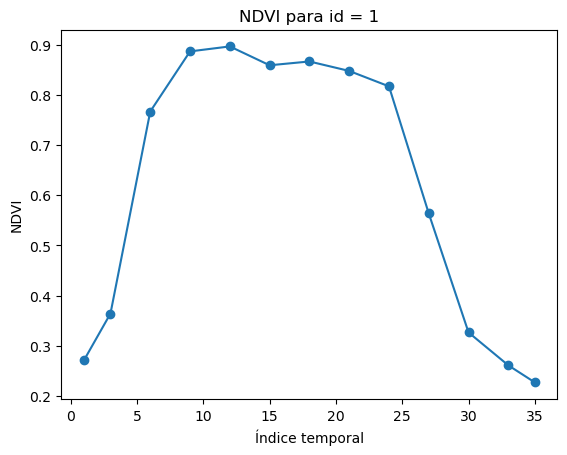

In [351]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Bodega2021[Bodega2021['id'] == 100].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Bodega2021.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()

In [353]:
import geopandas as gpd

# Cargar el shapefile
Bodega2021_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\bodegas_2021\Clean_Data2021/Puntos_Yield_Bodega2021_Final.shp")
Bodega2021_SHP = Bodega2021_SHP.drop(columns= 'geometry', axis=1)
Bodega2021_SHP

,id,value
0,1.0,10.997115
1,2.0,11.312577
2,3.0,11.646285
3,4.0,12.005125
4,5.0,15.620410
...,...,...
212,213.0,11.063690
213,214.0,11.967626
214,215.0,11.012983
215,216.0,10.854429


In [354]:
coe_Bodega2021 = (5.660640468097598 / 10) * 15

In [357]:
coe_Bodega2021

8.490960702146396

In [359]:
Bodega2021_SHP['biomasa'] = Bodega2021_SHP['value'] * coe_Bodega2021
Bodega2021_SHP = Bodega2021_SHP.drop('value', axis=1)
Bodega2021_SHP

,id,biomasa
0,1.0,93.376071
1,2.0,96.054647
2,3.0,98.888148
3,4.0,101.935045
4,5.0,132.632287
...,...,...
212,213.0,93.941357
213,214.0,101.616642
214,215.0,93.510806
215,216.0,92.164530


In [361]:
Bodega2021 = pd.merge(Bodega2021, Bodega2021_SHP, on='id', how='inner')
Bodega2021

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2021-06-05,0.316869,1.273514,0.105758,0.216567,0.487270,2021-06-10,0.334555,1.180258,...,0.153173,0.313559,0.239680,2021-11-07,0.398752,1.701061,0.109833,0.293421,0.312111,93.376071
1,2,2021-06-05,0.318507,1.261864,0.110300,0.200000,0.382015,2021-06-10,0.323276,1.163002,...,0.176573,0.341457,0.217334,2021-11-07,0.498051,1.592081,0.141529,0.304990,0.217089,96.054647
2,3,2021-06-05,0.314074,1.243799,0.107712,0.184641,0.320396,2021-06-10,0.332490,1.156174,...,0.186036,0.337486,0.190706,2021-11-07,0.490637,1.590681,0.138918,0.293162,0.208633,98.888148
3,4,2021-06-05,0.324831,1.249434,0.105477,0.185633,0.322925,2021-06-10,0.366885,1.157952,...,0.203106,0.309212,0.126196,2021-11-07,0.428821,1.703912,0.113986,0.257301,0.233645,101.935045
4,5,2021-06-05,0.344945,1.218750,0.127798,0.204885,0.264201,2021-06-10,0.385812,1.140159,...,0.228533,0.321944,0.096613,2021-11-07,0.424860,1.730902,0.125815,0.275699,0.237630,132.632287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2021-06-05,0.419523,1.231968,0.176344,0.253640,0.158314,2021-06-10,0.468872,1.119887,...,0.154002,0.282072,0.173550,2021-11-07,0.435360,1.845151,0.102140,0.237819,0.215733,93.941357
213,214,2021-06-05,0.425367,1.220036,0.181055,0.263963,0.177372,2021-06-10,0.458650,1.124554,...,0.156609,0.295618,0.174168,2021-11-07,0.438435,1.887467,0.090909,0.222693,0.210836,101.616642
214,215,2021-06-05,0.427454,1.213938,0.168356,0.269216,0.244651,2021-06-10,0.453626,1.141972,...,0.166453,0.279918,0.134727,2021-11-07,0.411809,1.886448,0.087820,0.243786,0.273030,93.510806
215,216,2021-06-05,0.425144,1.243454,0.156661,0.247278,0.206354,2021-06-10,0.458860,1.148221,...,0.181162,0.282887,0.116623,2021-11-07,0.427322,1.819040,0.105843,0.245193,0.227590,92.164530


### LST

In [363]:
LST_Bodega2021 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Bodega2021_2.csv')
LST_Bodega2021 = LST_Bodega2021.drop(columns=['.geo'], axis=1)
LST_Bodega2021

,id,date,LST
0,1,03/06/2021,27.922906
1,2,03/06/2021,27.922906
2,3,03/06/2021,27.856584
3,4,03/06/2021,27.856584
4,5,03/06/2021,27.690749
...,...,...,...
4335,213,12/11/2021,11.569784
4336,214,12/11/2021,11.569784
4337,215,12/11/2021,11.569784
4338,216,12/11/2021,11.569784


In [364]:
import numpy as np
import pandas as pd

df = LST_Bodega2021

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Bodega2021 = pd.DataFrame(rows_final)

In [367]:
LST_Bodega2021 = pd.merge(LST_Bodega2021, Bodega2021, on='id', how='inner')
LST_Bodega2021

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2021-06-03,27.922906,2021-06-12,30.661121,2021-07-05,24.999559,2021-07-13,18.587670,2021-07-14,...,0.153173,0.313559,0.239680,2021-11-07,0.398752,1.701061,0.109833,0.293421,0.312111,93.376071
1,2,2021-06-03,27.922906,2021-06-12,30.661121,2021-07-05,24.999559,2021-07-13,18.587670,2021-07-14,...,0.176573,0.341457,0.217334,2021-11-07,0.498051,1.592081,0.141529,0.304990,0.217089,96.054647
2,3,2021-06-03,27.856584,2021-06-12,31.030661,2021-07-05,24.966160,2021-07-13,18.075270,2021-07-14,...,0.186036,0.337486,0.190706,2021-11-07,0.490637,1.590681,0.138918,0.293162,0.208633,98.888148
3,4,2021-06-03,27.856584,2021-06-12,31.030661,2021-07-05,24.966160,2021-07-13,18.075270,2021-07-14,...,0.203106,0.309212,0.126196,2021-11-07,0.428821,1.703912,0.113986,0.257301,0.233645,101.935045
4,5,2021-06-03,27.690749,2021-06-12,31.507633,2021-07-05,25.164478,2021-07-13,17.068249,2021-07-14,...,0.228533,0.321944,0.096613,2021-11-07,0.424860,1.730902,0.125815,0.275699,0.237630,132.632287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2021-06-03,28.189499,2021-06-12,30.891535,2021-07-05,24.656770,2021-07-13,18.979406,2021-07-14,...,0.154002,0.282072,0.173550,2021-11-07,0.435360,1.845151,0.102140,0.237819,0.215733,93.941357
213,214,2021-06-03,28.189499,2021-06-12,30.891535,2021-07-05,24.656770,2021-07-13,18.979406,2021-07-14,...,0.156609,0.295618,0.174168,2021-11-07,0.438435,1.887467,0.090909,0.222693,0.210836,101.616642
214,215,2021-06-03,28.190338,2021-06-12,30.891535,2021-07-05,24.768167,2021-07-13,19.512472,2021-07-14,...,0.166453,0.279918,0.134727,2021-11-07,0.411809,1.886448,0.087820,0.243786,0.273030,93.510806
215,216,2021-06-03,28.190338,2021-06-12,30.891535,2021-07-05,24.768167,2021-07-13,19.512472,2021-07-14,...,0.181162,0.282887,0.116623,2021-11-07,0.427322,1.819040,0.105843,0.245193,0.227590,92.164530


## Bodega 2022

In [370]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Bodega2022.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Bodega2022 = pd.DataFrame(rows_final)

In [372]:
Bodega2022

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2022-05-29,0.328205,1.275217,0.118639,0.199942,0.262278,2022-06-13,0.409597,1.056809,...,1.073585,0.206373,0.341999,0.254604,2022-11-05,0.506223,1.513567,0.205651,0.374936,0.183103
1,2,2022-05-29,0.321788,1.260362,0.125394,0.191598,0.193665,2022-06-13,0.443012,1.020850,...,1.089249,0.206222,0.362324,0.272539,2022-11-05,0.546243,1.442455,0.222060,0.396233,0.169159
2,3,2022-05-29,0.314832,1.277205,0.119380,0.174170,0.134535,2022-06-13,0.439153,0.977444,...,1.081716,0.219463,0.363985,0.242342,2022-11-05,0.541651,1.460880,0.228782,0.410831,0.173714
3,4,2022-05-29,0.317221,1.275675,0.113238,0.164159,0.101406,2022-06-13,0.446696,0.994722,...,1.059171,0.230674,0.376686,0.252411,2022-11-05,0.538344,1.472291,0.211268,0.421238,0.200826
4,5,2022-05-29,0.331975,1.261801,0.098218,0.163488,0.183657,2022-06-13,0.475380,0.999090,...,1.069815,0.236250,0.398544,0.251673,2022-11-05,0.511828,1.399478,0.237132,0.412829,0.180934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2022-05-29,0.400390,1.429565,0.076871,0.170862,0.244489,2022-06-13,0.440075,1.250326,...,1.060778,0.216765,0.384314,0.267323,2022-11-05,0.436728,2.266335,0.072321,0.257266,0.256409
213,214,2022-05-29,0.387335,1.398441,0.087802,0.157171,0.112071,2022-06-13,0.464516,1.265749,...,1.067928,0.213561,0.373331,0.262309,2022-11-05,0.471084,2.428747,0.037824,0.263975,0.293386
214,215,2022-05-29,0.393412,1.369210,0.102235,0.170670,0.106288,2022-06-13,0.464458,1.265759,...,1.071964,0.223232,0.374046,0.243300,2022-11-05,0.524350,2.363779,0.080703,0.285462,0.221158
215,216,2022-05-29,0.416596,1.372504,0.101046,0.189584,0.194063,2022-06-13,0.449992,1.276129,...,1.076414,0.221263,0.380867,0.250910,2022-11-05,0.485604,2.247484,0.105708,0.254618,0.171095


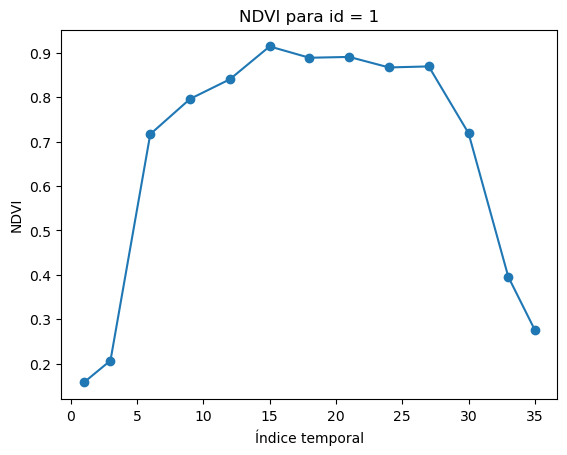

In [374]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Bodega2022[Bodega2022['id'] == 100].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Bodega2022.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()

In [376]:
import geopandas as gpd

# Cargar el shapefile
Bodega2022_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\bodegas_2022\Clean_Data2022/Puntos_Yield_Bodega2022_Final.shp")
Bodega2022_SHP = Bodega2022_SHP.drop(columns= 'geometry', axis=1)
Bodega2022_SHP

,id,value
0,1.0,13.741700
1,2.0,11.785415
2,3.0,12.917085
3,4.0,11.680167
4,5.0,13.251479
...,...,...
212,213.0,10.008514
213,214.0,10.830771
214,215.0,11.136921
215,216.0,10.700269


In [378]:
coe_Bodega2022 = (6.008073809241787 / 10) * 15

In [379]:
coe_Bodega2022

9.01211071386268

In [382]:
Bodega2022_SHP['biomasa'] = Bodega2022_SHP['value'] * coe_Bodega2022
Bodega2022_SHP = Bodega2022_SHP.drop('value', axis=1)
Bodega2022_SHP

,id,biomasa
0,1.0,123.841722
1,2.0,106.211465
2,3.0,116.410200
3,4.0,105.262958
4,5.0,119.423796
...,...,...
212,213.0,90.197836
213,214.0,97.608107
214,215.0,100.367165
215,216.0,96.432009


In [384]:
Bodega2022 = pd.merge(Bodega2022, Bodega2022_SHP, on='id', how='inner')
Bodega2022

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2022-05-29,0.328205,1.275217,0.118639,0.199942,0.262278,2022-06-13,0.409597,1.056809,...,0.206373,0.341999,0.254604,2022-11-05,0.506223,1.513567,0.205651,0.374936,0.183103,123.841722
1,2,2022-05-29,0.321788,1.260362,0.125394,0.191598,0.193665,2022-06-13,0.443012,1.020850,...,0.206222,0.362324,0.272539,2022-11-05,0.546243,1.442455,0.222060,0.396233,0.169159,106.211465
2,3,2022-05-29,0.314832,1.277205,0.119380,0.174170,0.134535,2022-06-13,0.439153,0.977444,...,0.219463,0.363985,0.242342,2022-11-05,0.541651,1.460880,0.228782,0.410831,0.173714,116.410200
3,4,2022-05-29,0.317221,1.275675,0.113238,0.164159,0.101406,2022-06-13,0.446696,0.994722,...,0.230674,0.376686,0.252411,2022-11-05,0.538344,1.472291,0.211268,0.421238,0.200826,105.262958
4,5,2022-05-29,0.331975,1.261801,0.098218,0.163488,0.183657,2022-06-13,0.475380,0.999090,...,0.236250,0.398544,0.251673,2022-11-05,0.511828,1.399478,0.237132,0.412829,0.180934,119.423796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2022-05-29,0.400390,1.429565,0.076871,0.170862,0.244489,2022-06-13,0.440075,1.250326,...,0.216765,0.384314,0.267323,2022-11-05,0.436728,2.266335,0.072321,0.257266,0.256409,90.197836
213,214,2022-05-29,0.387335,1.398441,0.087802,0.157171,0.112071,2022-06-13,0.464516,1.265749,...,0.213561,0.373331,0.262309,2022-11-05,0.471084,2.428747,0.037824,0.263975,0.293386,97.608107
214,215,2022-05-29,0.393412,1.369210,0.102235,0.170670,0.106288,2022-06-13,0.464458,1.265759,...,0.223232,0.374046,0.243300,2022-11-05,0.524350,2.363779,0.080703,0.285462,0.221158,100.367165
215,216,2022-05-29,0.416596,1.372504,0.101046,0.189584,0.194063,2022-06-13,0.449992,1.276129,...,0.221263,0.380867,0.250910,2022-11-05,0.485604,2.247484,0.105708,0.254618,0.171095,96.432009


### LST

In [387]:
LST_Bodega2022 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Bodega2022_2.csv')
LST_Bodega2022 = LST_Bodega2022.drop(columns=['.geo'], axis=1)
LST_Bodega2022

,id,date,LST
0,1,10/06/2022,25.511929
1,2,10/06/2022,25.511929
2,3,10/06/2022,25.539434
3,4,10/06/2022,25.539434
4,5,10/06/2022,26.586522
...,...,...,...
4335,213,05/11/2022,12.045299
4336,214,05/11/2022,12.045299
4337,215,05/11/2022,12.021428
4338,216,05/11/2022,12.021428


In [389]:
import numpy as np
import pandas as pd

df = LST_Bodega2022

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Bodega2022 = pd.DataFrame(rows_final)

In [391]:
LST_Bodega2022 = pd.merge(LST_Bodega2022, Bodega2022, on='id', how='inner')
LST_Bodega2022

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2022-06-10,25.511929,2022-06-15,28.175722,2022-06-27,21.457552,2022-07-02,25.841330,2022-07-09,...,0.206373,0.341999,0.254604,2022-11-05,0.506223,1.513567,0.205651,0.374936,0.183103,123.841722
1,2,2022-06-10,25.511929,2022-06-15,28.175722,2022-06-27,21.457552,2022-07-02,25.841330,2022-07-09,...,0.206222,0.362324,0.272539,2022-11-05,0.546243,1.442455,0.222060,0.396233,0.169159,106.211465
2,3,2022-06-10,25.539434,2022-06-15,28.341267,2022-06-27,21.450855,2022-07-02,25.793075,2022-07-09,...,0.219463,0.363985,0.242342,2022-11-05,0.541651,1.460880,0.228782,0.410831,0.173714,116.410200
3,4,2022-06-10,25.539434,2022-06-15,28.341267,2022-06-27,21.450855,2022-07-02,25.793075,2022-07-09,...,0.230674,0.376686,0.252411,2022-11-05,0.538344,1.472291,0.211268,0.421238,0.200826,105.262958
4,5,2022-06-10,26.586522,2022-06-15,28.346914,2022-06-27,20.930334,2022-07-02,25.556634,2022-07-09,...,0.236250,0.398544,0.251673,2022-11-05,0.511828,1.399478,0.237132,0.412829,0.180934,119.423796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2022-06-10,29.160614,2022-06-15,30.166257,2022-06-27,21.177139,2022-07-02,22.142311,2022-07-09,...,0.216765,0.384314,0.267323,2022-11-05,0.436728,2.266335,0.072321,0.257266,0.256409,90.197836
213,214,2022-06-10,29.160614,2022-06-15,30.166257,2022-06-27,21.177139,2022-07-02,22.142311,2022-07-09,...,0.213561,0.373331,0.262309,2022-11-05,0.471084,2.428747,0.037824,0.263975,0.293386,97.608107
214,215,2022-06-10,29.160614,2022-06-15,30.317121,2022-06-27,21.177139,2022-07-02,22.385091,2022-07-09,...,0.223232,0.374046,0.243300,2022-11-05,0.524350,2.363779,0.080703,0.285462,0.221158,100.367165
215,216,2022-06-10,29.160614,2022-06-15,30.317121,2022-06-27,21.177139,2022-07-02,22.385091,2022-07-09,...,0.221263,0.380867,0.250910,2022-11-05,0.485604,2.247484,0.105708,0.254618,0.171095,96.432009


In [395]:
LST_Bodega2022.isna().sum()

id               0
date_1_x         0
LST_1            0
date_2           0
LST_2            0
                ..
MSI_35           0
NDRE_35          0
NDVI_35          0
TCARIOSAVI_35    0
biomasa          0
Length: 120, dtype: int64

## Bodega Final

In [570]:
Bodega = pd.concat([Bodega2020, Bodega2021, Bodega2022])
Bodega

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-05,0.366031,1.279498,0.100531,0.252702,0.460497,2020-06-23,0.454062,1.097622,...,0.192333,0.289529,0.142698,2020-10-28,0.361783,1.302152,0.218234,0.279473,0.114502,98.138616
1,2,2020-06-05,0.371378,1.279770,0.103809,0.254618,0.443947,2020-06-23,0.455777,1.040377,...,0.208116,0.301313,0.106370,2020-10-28,0.393760,1.311970,0.214654,0.287621,0.124290,91.288667
2,3,2020-06-05,0.384801,1.223996,0.130729,0.253988,0.336813,2020-06-23,0.454906,0.992197,...,0.225601,0.327470,0.130043,2020-10-28,0.438442,1.180786,0.256861,0.328306,0.101983,94.097329
3,4,2020-06-05,0.389646,1.187745,0.138075,0.251726,0.301844,2020-06-23,0.516519,0.946592,...,0.231577,0.317555,0.093110,2020-10-28,0.448082,1.164513,0.263330,0.381321,0.192071,86.220574
4,5,2020-06-05,0.413333,1.149473,0.152499,0.278909,0.305446,2020-06-23,0.504879,0.939818,...,0.225687,0.325932,0.125153,2020-10-28,0.454914,1.168988,0.241499,0.390126,0.230421,109.109926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2022-05-29,0.400390,1.429565,0.076871,0.170862,0.244489,2022-06-13,0.440075,1.250326,...,0.216765,0.384314,0.267323,2022-11-05,0.436728,2.266335,0.072321,0.257266,0.256409,90.197836
213,214,2022-05-29,0.387335,1.398441,0.087802,0.157171,0.112071,2022-06-13,0.464516,1.265749,...,0.213561,0.373331,0.262309,2022-11-05,0.471084,2.428747,0.037824,0.263975,0.293386,97.608107
214,215,2022-05-29,0.393412,1.369210,0.102235,0.170670,0.106288,2022-06-13,0.464458,1.265759,...,0.223232,0.374046,0.243300,2022-11-05,0.524350,2.363779,0.080703,0.285462,0.221158,100.367165
215,216,2022-05-29,0.416596,1.372504,0.101046,0.189584,0.194063,2022-06-13,0.449992,1.276129,...,0.221263,0.380867,0.250910,2022-11-05,0.485604,2.247484,0.105708,0.254618,0.171095,96.432009


In [572]:
cols_to_drop = [c for c in Bodega.columns if c.startswith('date_')]
Bodega = Bodega.drop(cols_to_drop, axis=1)

In [574]:
Bodega

,id,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,GNDVI_3,MSI_3,NDRE_3,NDVI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,0.366031,1.279498,0.100531,0.252702,0.460497,0.454062,1.097622,0.200596,0.361081,...,1.252316,0.192333,0.289529,0.142698,0.361783,1.302152,0.218234,0.279473,0.114502,98.138616
1,2,0.371378,1.279770,0.103809,0.254618,0.443947,0.455777,1.040377,0.222043,0.384294,...,1.214020,0.208116,0.301313,0.106370,0.393760,1.311970,0.214654,0.287621,0.124290,91.288667
2,3,0.384801,1.223996,0.130729,0.253988,0.336813,0.454906,0.992197,0.243780,0.395678,...,1.179267,0.225601,0.327470,0.130043,0.438442,1.180786,0.256861,0.328306,0.101983,94.097329
3,4,0.389646,1.187745,0.138075,0.251726,0.301844,0.516519,0.946592,0.270347,0.436406,...,1.162962,0.231577,0.317555,0.093110,0.448082,1.164513,0.263330,0.381321,0.192071,86.220574
4,5,0.413333,1.149473,0.152499,0.278909,0.305446,0.504879,0.939818,0.280688,0.431829,...,1.174647,0.225687,0.325932,0.125153,0.454914,1.168988,0.241499,0.390126,0.230421,109.109926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,0.400390,1.429565,0.076871,0.170862,0.244489,0.440075,1.250326,0.166054,0.252828,...,1.060778,0.216765,0.384314,0.267323,0.436728,2.266335,0.072321,0.257266,0.256409,90.197836
213,214,0.387335,1.398441,0.087802,0.157171,0.112071,0.464516,1.265749,0.160087,0.264800,...,1.067928,0.213561,0.373331,0.262309,0.471084,2.428747,0.037824,0.263975,0.293386,97.608107
214,215,0.393412,1.369210,0.102235,0.170670,0.106288,0.464458,1.265759,0.166016,0.282355,...,1.071964,0.223232,0.374046,0.243300,0.524350,2.363779,0.080703,0.285462,0.221158,100.367165
215,216,0.416596,1.372504,0.101046,0.189584,0.194063,0.449992,1.276129,0.162046,0.264278,...,1.076414,0.221263,0.380867,0.250910,0.485604,2.247484,0.105708,0.254618,0.171095,96.432009


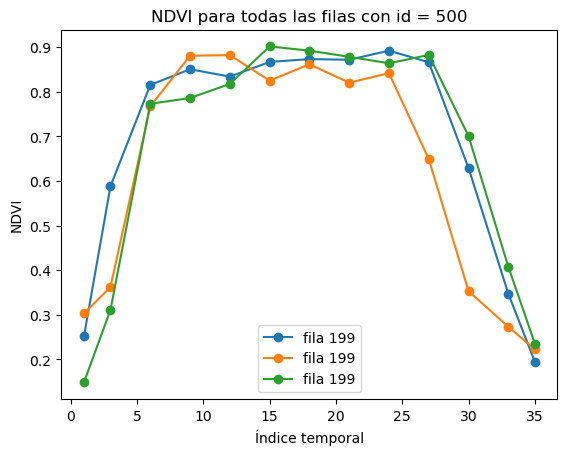

In [578]:
import matplotlib.pyplot as plt

# Filtrar todas las filas con id == 2000
rows = Bodega[Bodega['id'] == 200]

# Columnas NDVI_*
ndvi_cols = [c for c in Bodega.columns if c.startswith('NDVI_')]
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Eje X = número de NDVI
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Graficar todas las filas
plt.figure()
for idx, row in rows.iterrows():
    ndvi_values = row[ndvi_cols].values
    plt.plot(x, ndvi_values, marker='o', label=f'fila {idx}')

plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para todas las filas con id = 500')
plt.legend()
plt.show()

In [580]:
Bodega.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/Bodega_BiomasaIV.csv', index=False)

### LST

In [397]:
LST_Bodega = pd.concat([LST_Bodega2020, LST_Bodega2021, LST_Bodega2022])
LST_Bodega

,id,date_1_x,LST_1,date_2,LST_2,date_3_x,LST_3,date_4,LST_4,date_5,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2020-06-01,26.697537,2020-06-16,24.498526,2020-07-02,24.390802,2020-07-03,23.360582,2020-07-10,...,0.192333,0.289529,0.142698,2020-10-28,0.361783,1.302152,0.218234,0.279473,0.114502,98.138616
1,2,2020-06-01,26.697537,2020-06-16,24.498526,2020-07-02,24.390802,2020-07-03,23.360582,2020-07-10,...,0.208116,0.301313,0.106370,2020-10-28,0.393760,1.311970,0.214654,0.287621,0.124290,91.288667
2,3,2020-06-01,26.662817,2020-06-16,24.454817,2020-07-02,24.303648,2020-07-03,23.360582,2020-07-10,...,0.225601,0.327470,0.130043,2020-10-28,0.438442,1.180786,0.256861,0.328306,0.101983,94.097329
3,4,2020-06-01,26.662817,2020-06-16,24.454817,2020-07-02,24.303648,2020-07-03,23.360582,2020-07-10,...,0.231577,0.317555,0.093110,2020-10-28,0.448082,1.164513,0.263330,0.381321,0.192071,86.220574
4,5,2020-06-01,27.166333,2020-06-16,24.816498,2020-07-02,24.499253,2020-07-03,23.950617,2020-07-10,...,0.225687,0.325932,0.125153,2020-10-28,0.454914,1.168988,0.241499,0.390126,0.230421,109.109926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,2022-06-10,29.160614,2022-06-15,30.166257,2022-06-27,21.177139,2022-07-02,22.142311,2022-07-09,...,0.216765,0.384314,0.267323,2022-11-05,0.436728,2.266335,0.072321,0.257266,0.256409,90.197836
213,214,2022-06-10,29.160614,2022-06-15,30.166257,2022-06-27,21.177139,2022-07-02,22.142311,2022-07-09,...,0.213561,0.373331,0.262309,2022-11-05,0.471084,2.428747,0.037824,0.263975,0.293386,97.608107
214,215,2022-06-10,29.160614,2022-06-15,30.317121,2022-06-27,21.177139,2022-07-02,22.385091,2022-07-09,...,0.223232,0.374046,0.243300,2022-11-05,0.524350,2.363779,0.080703,0.285462,0.221158,100.367165
215,216,2022-06-10,29.160614,2022-06-15,30.317121,2022-06-27,21.177139,2022-07-02,22.385091,2022-07-09,...,0.221263,0.380867,0.250910,2022-11-05,0.485604,2.247484,0.105708,0.254618,0.171095,96.432009


In [399]:
cols_to_drop = [c for c in LST_Bodega.columns if c.startswith('date_')]
LST_Bodega = LST_Bodega.drop(cols_to_drop, axis=1)
LST_Bodega

,id,LST_1,LST_2,LST_3,LST_4,LST_5,LST_6,LST_7,LST_8,LST_9,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,26.697537,24.498526,24.390802,23.360582,23.597903,24.362548,26.743631,26.860875,28.649706,...,1.252316,0.192333,0.289529,0.142698,0.361783,1.302152,0.218234,0.279473,0.114502,98.138616
1,2,26.697537,24.498526,24.390802,23.360582,23.597903,24.362548,26.743631,26.860875,28.649706,...,1.214020,0.208116,0.301313,0.106370,0.393760,1.311970,0.214654,0.287621,0.124290,91.288667
2,3,26.662817,24.454817,24.303648,23.360582,23.597903,24.544803,26.740065,26.826289,28.720193,...,1.179267,0.225601,0.327470,0.130043,0.438442,1.180786,0.256861,0.328306,0.101983,94.097329
3,4,26.662817,24.454817,24.303648,23.360582,23.597903,24.544803,26.740065,26.826289,28.720193,...,1.162962,0.231577,0.317555,0.093110,0.448082,1.164513,0.263330,0.381321,0.192071,86.220574
4,5,27.166333,24.816498,24.499253,23.950617,23.906439,24.910529,26.968679,26.930123,28.959013,...,1.174647,0.225687,0.325932,0.125153,0.454914,1.168988,0.241499,0.390126,0.230421,109.109926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,213,29.160614,30.166257,21.177139,22.142311,31.062504,21.110629,29.335298,23.158069,27.301498,...,1.060778,0.216765,0.384314,0.267323,0.436728,2.266335,0.072321,0.257266,0.256409,90.197836
213,214,29.160614,30.166257,21.177139,22.142311,31.062504,21.110629,29.335298,23.158069,27.301498,...,1.067928,0.213561,0.373331,0.262309,0.471084,2.428747,0.037824,0.263975,0.293386,97.608107
214,215,29.160614,30.317121,21.177139,22.385091,31.062504,21.090695,29.702536,23.158069,27.699471,...,1.071964,0.223232,0.374046,0.243300,0.524350,2.363779,0.080703,0.285462,0.221158,100.367165
215,216,29.160614,30.317121,21.177139,22.385091,31.062504,21.090695,29.702536,23.158069,27.699471,...,1.076414,0.221263,0.380867,0.250910,0.485604,2.247484,0.105708,0.254618,0.171095,96.432009


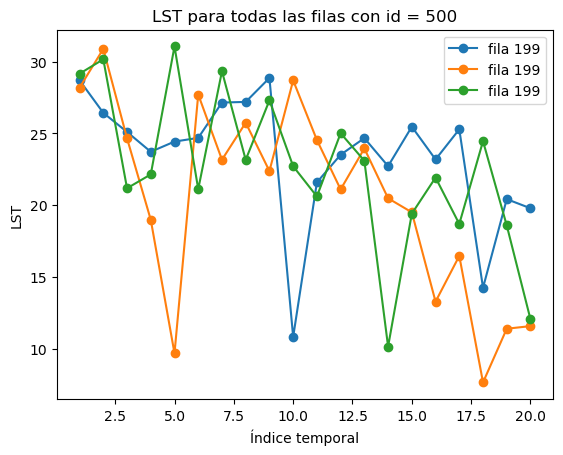

In [400]:
import matplotlib.pyplot as plt

# Filtrar todas las filas con id == 2000
rows = LST_Bodega[LST_Bodega['id'] == 200]

# Columnas NDVI_*
ndvi_cols = [c for c in LST_Bodega.columns if c.startswith('LST_')]
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Eje X = número de NDVI
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Graficar todas las filas
plt.figure()
for idx, row in rows.iterrows():
    ndvi_values = row[ndvi_cols].values
    plt.plot(x, ndvi_values, marker='o', label=f'fila {idx}')

plt.xlabel('Índice temporal')
plt.ylabel('LST')
plt.title('LST para todas las filas con id = 500')
plt.legend()
plt.show()

In [313]:
LST_Bodega.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/Bodega_BiomasaLST.csv', index=False)

## Datatset completo Arroto, Camino, Grande, Bodega

In [655]:
dataset_final = pd.concat([Arroto, Camino, Grande, Bodega])
dataset_final = dataset_final.drop(columns= 'id', axis=1)
dataset_final

,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,GNDVI_3,MSI_3,NDRE_3,NDVI_3,TCARIOSAVI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,0.403660,0.863289,0.243832,0.372619,0.331661,0.708623,0.551990,0.596162,0.776875,0.168028,...,1.179469,0.270348,0.409969,0.124428,0.371075,2.088133,0.122274,0.210416,0.123826,184.969031
1,0.409827,0.909288,0.255737,0.384997,0.318924,0.721810,0.530257,0.615556,0.777448,0.150659,...,1.172969,0.282731,0.423197,0.122831,0.344917,2.088687,0.113747,0.186658,0.102002,200.606397
2,0.374150,0.955743,0.232308,0.335096,0.284215,0.704790,0.540099,0.609813,0.786600,0.166663,...,1.164003,0.286257,0.422815,0.114455,0.337024,2.064182,0.119567,0.188923,0.097692,184.135412
3,0.386242,0.947306,0.241362,0.361014,0.312075,0.707925,0.567421,0.589571,0.779416,0.171705,...,1.262611,0.245553,0.377619,0.123177,0.357292,2.061155,0.072358,0.182626,0.206533,171.617496
4,0.413170,0.962560,0.233826,0.387709,0.359420,0.696555,0.576579,0.584324,0.764706,0.169509,...,1.283076,0.237984,0.374255,0.133900,0.364026,1.996360,0.088225,0.185796,0.164812,157.650701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,0.400390,1.429565,0.076871,0.170862,0.244489,0.440075,1.250326,0.166054,0.252828,0.168550,...,1.060778,0.216765,0.384314,0.267323,0.436728,2.266335,0.072321,0.257266,0.256409,90.197836
213,0.387335,1.398441,0.087802,0.157171,0.112071,0.464516,1.265749,0.160087,0.264800,0.210852,...,1.067928,0.213561,0.373331,0.262309,0.471084,2.428747,0.037824,0.263975,0.293386,97.608107
214,0.393412,1.369210,0.102235,0.170670,0.106288,0.464458,1.265759,0.166016,0.282355,0.246486,...,1.071964,0.223232,0.374046,0.243300,0.524350,2.363779,0.080703,0.285462,0.221158,100.367165
215,0.416596,1.372504,0.101046,0.189584,0.194063,0.449992,1.276129,0.162046,0.264278,0.214382,...,1.076414,0.221263,0.380867,0.250910,0.485604,2.247484,0.105708,0.254618,0.171095,96.432009


In [657]:
dataset_final.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/DatasetALL_IV.csv', index=False)

### LST

In [403]:
LST_dataset_final = pd.concat([LST_Arroto, LST_Camino, LST_Grande, LST_Bodega])
LST_dataset_final = LST_dataset_final.drop(columns= 'id', axis=1)
LST_dataset_final

,LST_1,LST_2,LST_3,LST_4,LST_5,LST_6,LST_7,LST_8,LST_9,LST_10,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,24.689748,19.737405,19.505084,20.049716,22.118897,23.487733,25.000370,24.151211,27.446460,10.595868,...,1.179469,0.270348,0.409969,0.124428,0.371075,2.088133,0.122274,0.210416,0.123826,184.969031
1,25.229318,20.377030,20.178973,20.531702,22.658056,23.607284,25.259192,24.157989,27.583861,10.720572,...,1.172969,0.282731,0.423197,0.122831,0.344917,2.088687,0.113747,0.186658,0.102002,200.606397
2,25.229318,20.377030,20.178973,20.531702,22.658056,23.607284,25.259192,24.157989,27.583861,10.720572,...,1.164003,0.286257,0.422815,0.114455,0.337024,2.064182,0.119567,0.188923,0.097692,184.135412
3,25.229318,20.377030,20.178973,20.531702,22.658056,23.607284,25.259192,24.157989,27.583861,10.720572,...,1.262611,0.245553,0.377619,0.123177,0.357292,2.061155,0.072358,0.182626,0.206533,171.617496
4,25.746245,21.030291,21.139827,21.103983,23.269788,23.799664,25.852171,24.695416,27.632876,11.191139,...,1.283076,0.237984,0.374255,0.133900,0.364026,1.996360,0.088225,0.185796,0.164812,157.650701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,29.160614,30.166257,21.177139,22.142311,31.062504,21.110629,29.335298,23.158069,27.301498,22.710259,...,1.060778,0.216765,0.384314,0.267323,0.436728,2.266335,0.072321,0.257266,0.256409,90.197836
213,29.160614,30.166257,21.177139,22.142311,31.062504,21.110629,29.335298,23.158069,27.301498,22.710259,...,1.067928,0.213561,0.373331,0.262309,0.471084,2.428747,0.037824,0.263975,0.293386,97.608107
214,29.160614,30.317121,21.177139,22.385091,31.062504,21.090695,29.702536,23.158069,27.699471,22.710259,...,1.071964,0.223232,0.374046,0.243300,0.524350,2.363779,0.080703,0.285462,0.221158,100.367165
215,29.160614,30.317121,21.177139,22.385091,31.062504,21.090695,29.702536,23.158069,27.699471,22.710259,...,1.076414,0.221263,0.380867,0.250910,0.485604,2.247484,0.105708,0.254618,0.171095,96.432009


In [407]:
LST_dataset_final.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/DatasetALL_LST.csv', index=False)

In [405]:
LST_dataset_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10992 entries, 0 to 216
Data columns (total 86 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LST_1          10992 non-null  float64
 1   LST_2          10992 non-null  float64
 2   LST_3          10992 non-null  float64
 3   LST_4          10992 non-null  float64
 4   LST_5          10992 non-null  float64
 5   LST_6          10992 non-null  float64
 6   LST_7          10992 non-null  float64
 7   LST_8          10992 non-null  float64
 8   LST_9          10992 non-null  float64
 9   LST_10         10992 non-null  float64
 10  LST_11         10992 non-null  float64
 11  LST_12         10992 non-null  float64
 12  LST_13         10992 non-null  float64
 13  LST_14         10992 non-null  float64
 14  LST_15         10992 non-null  float64
 15  LST_16         10992 non-null  float64
 16  LST_17         10992 non-null  float64
 17  LST_18         10992 non-null  float64
 18  LST_19       

## PREDECIR Grande 2022

In [671]:
import pandas as pd

# Cargar datos
df = pd.read_csv(
    r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Datos_Grande2022.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

indices = [
    'GNDVI_S2', 'MSI_S2', 'NDRE_S2',
    'NDVI_S2', 'TCARIOSAVI_S2'
]

idx_sel = [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 35]

rows_final = []

for id_val, g in df.groupby('id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['fecha_idx'] = g.index + 1
    g = g[g['fecha_idx'].isin(idx_sel)]

    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        for var in indices:
            base = var.replace('_S2', '')
            row[f'{base}_{i}'] = r[var]

    rows_final.append(row)

Grande2022 = pd.DataFrame(rows_final)

In [672]:
Grande2022

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35
0,1,2022-05-29,0.349899,1.146358,0.124220,0.214581,0.314818,2022-06-13,0.539409,0.900378,...,0.891228,0.293355,0.467991,0.231276,2022-11-05,0.422990,1.841954,0.138909,0.230407,0.104350
1,2,2022-05-29,0.342469,1.149920,0.121562,0.203131,0.281483,2022-06-13,0.496231,0.905915,...,0.900026,0.287678,0.469058,0.233683,2022-11-05,0.441733,1.820943,0.144875,0.245714,0.113660
2,3,2022-05-29,0.332621,1.153067,0.115572,0.198318,0.304974,2022-06-13,0.444056,0.951354,...,0.906193,0.288371,0.445203,0.206261,2022-11-05,0.430864,1.889182,0.131977,0.231519,0.116168
3,4,2022-05-29,0.322936,1.163618,0.111425,0.199415,0.346891,2022-06-13,0.428661,0.958306,...,0.881475,0.304377,0.446659,0.190562,2022-11-05,0.431786,1.891290,0.133210,0.246276,0.141819
4,5,2022-05-29,0.342646,1.166871,0.115041,0.205756,0.328116,2022-06-13,0.561839,0.792203,...,0.929198,0.284714,0.465969,0.238583,2022-11-05,0.445688,1.721311,0.186386,0.241613,0.015865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2022-05-29,0.313375,1.077687,0.130229,0.184103,0.147505,2022-06-13,0.458110,1.001996,...,0.879140,0.292652,0.445645,0.198746,2022-11-05,0.404899,1.738023,0.156179,0.226478,0.067170
467,468,2022-05-29,0.310295,1.087212,0.134880,0.169518,0.009269,2022-06-13,0.449909,1.009003,...,0.920490,0.282221,0.421245,0.191270,2022-11-05,0.420309,1.764520,0.140799,0.222930,0.084847
468,469,2022-05-29,0.312716,1.218321,0.106765,0.152802,0.064254,2022-06-13,0.419534,1.008478,...,0.918198,0.272491,0.421368,0.213439,2022-11-05,0.421560,1.808261,0.127759,0.220467,0.110903
469,470,2022-05-29,0.306521,1.204844,0.076117,0.164010,0.378848,2022-06-13,0.428658,1.008500,...,0.896933,0.285610,0.429393,0.201022,2022-11-05,0.406621,1.754677,0.165055,0.217264,0.019580


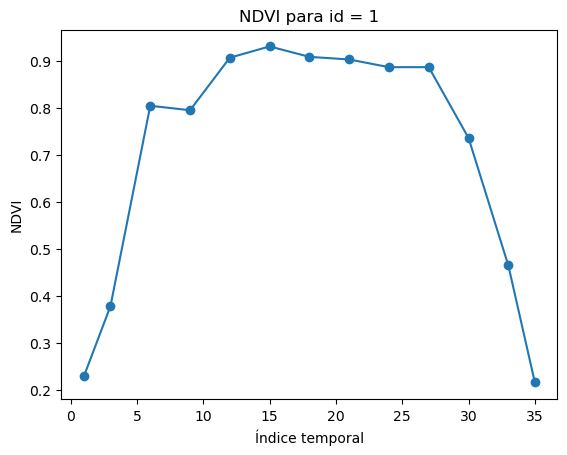

In [675]:
import matplotlib.pyplot as plt

# Filtrar fila id == 1
row = Grande2022[Grande2022['id'] == 100].iloc[0]

# Extraer columnas NDVI_*
ndvi_cols = [c for c in Grande2022.columns if c.startswith('NDVI_')]

# Ordenarlas por el número (1, 3, 6, ...)
ndvi_cols = sorted(ndvi_cols, key=lambda x: int(x.split('_')[1]))

# Valores NDVI
ndvi_values = row[ndvi_cols].values

# Eje X = índice de fecha (1, 3, 6, ...)
x = [int(c.split('_')[1]) for c in ndvi_cols]

# Gráfica
plt.figure()
plt.plot(x, ndvi_values, marker='o')
plt.xlabel('Índice temporal')
plt.ylabel('NDVI')
plt.title('NDVI para id = 1')
plt.show()

In [677]:
import geopandas as gpd

# Cargar el shapefile
Grande2022_SHP = gpd.read_file(r"C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\grande_2022\Clean_Data2022/Puntos_Yield_Grande2022_Final.shp")
Grande2022_SHP = Grande2022_SHP.drop(columns= 'geometry', axis=1)
Grande2022_SHP

,id,value
0,1.0,15.925817
1,2.0,13.578354
2,3.0,13.453711
3,4.0,17.204151
4,5.0,16.682207
...,...,...
466,467.0,17.139431
467,468.0,16.147237
468,469.0,17.803672
469,470.0,15.835771


In [679]:
coe_Grande2022 = (5.998997815978862 / 10) * 15

In [681]:
coe_Grande2022

8.998496723968294

In [683]:
Grande2022_SHP['biomasa'] = Grande2022_SHP['value'] * coe_Grande2022
Grande2022_SHP = Grande2022_SHP.drop('value', axis=1)
Grande2022_SHP

,id,biomasa
0,1.0,143.308412
1,2.0,122.184774
2,3.0,121.063174
3,4.0,154.811496
4,5.0,150.114785
...,...,...
466,467.0,154.229114
467,468.0,145.300859
468,469.0,160.206284
469,470.0,142.498133


In [685]:
Grande2022 = pd.merge(Grande2022, Grande2022_SHP, on='id', how='inner')
Grande2022

,id,date_1,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,date_3,GNDVI_3,MSI_3,...,NDRE_33,NDVI_33,TCARIOSAVI_33,date_35,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2022-05-29,0.349899,1.146358,0.124220,0.214581,0.314818,2022-06-13,0.539409,0.900378,...,0.293355,0.467991,0.231276,2022-11-05,0.422990,1.841954,0.138909,0.230407,0.104350,143.308412
1,2,2022-05-29,0.342469,1.149920,0.121562,0.203131,0.281483,2022-06-13,0.496231,0.905915,...,0.287678,0.469058,0.233683,2022-11-05,0.441733,1.820943,0.144875,0.245714,0.113660,122.184774
2,3,2022-05-29,0.332621,1.153067,0.115572,0.198318,0.304974,2022-06-13,0.444056,0.951354,...,0.288371,0.445203,0.206261,2022-11-05,0.430864,1.889182,0.131977,0.231519,0.116168,121.063174
3,4,2022-05-29,0.322936,1.163618,0.111425,0.199415,0.346891,2022-06-13,0.428661,0.958306,...,0.304377,0.446659,0.190562,2022-11-05,0.431786,1.891290,0.133210,0.246276,0.141819,154.811496
4,5,2022-05-29,0.342646,1.166871,0.115041,0.205756,0.328116,2022-06-13,0.561839,0.792203,...,0.284714,0.465969,0.238583,2022-11-05,0.445688,1.721311,0.186386,0.241613,0.015865,150.114785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2022-05-29,0.313375,1.077687,0.130229,0.184103,0.147505,2022-06-13,0.458110,1.001996,...,0.292652,0.445645,0.198746,2022-11-05,0.404899,1.738023,0.156179,0.226478,0.067170,154.229114
467,468,2022-05-29,0.310295,1.087212,0.134880,0.169518,0.009269,2022-06-13,0.449909,1.009003,...,0.282221,0.421245,0.191270,2022-11-05,0.420309,1.764520,0.140799,0.222930,0.084847,145.300859
468,469,2022-05-29,0.312716,1.218321,0.106765,0.152802,0.064254,2022-06-13,0.419534,1.008478,...,0.272491,0.421368,0.213439,2022-11-05,0.421560,1.808261,0.127759,0.220467,0.110903,160.206284
469,470,2022-05-29,0.306521,1.204844,0.076117,0.164010,0.378848,2022-06-13,0.428658,1.008500,...,0.285610,0.429393,0.201022,2022-11-05,0.406621,1.754677,0.165055,0.217264,0.019580,142.498133


In [691]:
cols_to_drop = [c for c in Grande2022.columns if c.startswith('date_')]
Grande2022 = Grande2022.drop(cols_to_drop, axis=1)

In [693]:
Grande2022

,id,GNDVI_1,MSI_1,NDRE_1,NDVI_1,TCARIOSAVI_1,GNDVI_3,MSI_3,NDRE_3,NDVI_3,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,0.349899,1.146358,0.124220,0.214581,0.314818,0.539409,0.900378,0.289555,0.480250,...,0.891228,0.293355,0.467991,0.231276,0.422990,1.841954,0.138909,0.230407,0.104350,143.308412
1,2,0.342469,1.149920,0.121562,0.203131,0.281483,0.496231,0.905915,0.290095,0.402458,...,0.900026,0.287678,0.469058,0.233683,0.441733,1.820943,0.144875,0.245714,0.113660,122.184774
2,3,0.332621,1.153067,0.115572,0.198318,0.304974,0.444056,0.951354,0.263612,0.353090,...,0.906193,0.288371,0.445203,0.206261,0.430864,1.889182,0.131977,0.231519,0.116168,121.063174
3,4,0.322936,1.163618,0.111425,0.199415,0.346891,0.428661,0.958306,0.256532,0.331880,...,0.881475,0.304377,0.446659,0.190562,0.431786,1.891290,0.133210,0.246276,0.141819,154.811496
4,5,0.342646,1.166871,0.115041,0.205756,0.328116,0.561839,0.792203,0.404023,0.513023,...,0.929198,0.284714,0.465969,0.238583,0.445688,1.721311,0.186386,0.241613,0.015865,150.114785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,0.313375,1.077687,0.130229,0.184103,0.147505,0.458110,1.001996,0.236765,0.344443,...,0.879140,0.292652,0.445645,0.198746,0.404899,1.738023,0.156179,0.226478,0.067170,154.229114
467,468,0.310295,1.087212,0.134880,0.169518,0.009269,0.449909,1.009003,0.220547,0.352208,...,0.920490,0.282221,0.421245,0.191270,0.420309,1.764520,0.140799,0.222930,0.084847,145.300859
468,469,0.312716,1.218321,0.106765,0.152802,0.064254,0.419534,1.008478,0.244336,0.303670,...,0.918198,0.272491,0.421368,0.213439,0.421560,1.808261,0.127759,0.220467,0.110903,160.206284
469,470,0.306521,1.204844,0.076117,0.164010,0.378848,0.428658,1.008500,0.233794,0.324887,...,0.896933,0.285610,0.429393,0.201022,0.406621,1.754677,0.165055,0.217264,0.019580,142.498133


In [695]:
Grande2022.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/Grande2022_PredecirIV.csv', index=False)

### LST

In [697]:
LST_Grande2022 = pd.read_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\LST_Grande2022_2.csv')
LST_Grande2022 = LST_Grande2022.drop(columns=['.geo'], axis=1)
LST_Grande2022

,id,date,LST
0,1,30/05/2022,9.097116
1,2,30/05/2022,9.097116
2,3,30/05/2022,9.097116
3,4,30/05/2022,9.038110
4,5,30/05/2022,9.536231
...,...,...,...
9415,467,13/11/2022,12.963417
9416,468,13/11/2022,12.963417
9417,469,13/11/2022,12.959336
9418,470,13/11/2022,12.964317


In [699]:
import numpy as np
import pandas as pd

df = LST_Grande2022

# Convertir fechas (robusto a formatos mezclados)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# Índices de fecha: 1 a 20
idx_sel = np.arange(1, 21)

rows_final = []

for id_val, g in df.groupby('id'):
    # Ordenar por fecha
    g = g.sort_values('date').reset_index(drop=True)

    # Índice temporal por id
    g['fecha_idx'] = g.index + 1

    # Seleccionar solo fechas 1 a 20
    g = g[g['fecha_idx'].isin(idx_sel)]

    # Fila final por id
    row = {'id': id_val}

    for _, r in g.iterrows():
        i = int(r['fecha_idx'])
        row[f'date_{i}'] = r['date']
        row[f'LST_{i}'] = r['LST']

    rows_final.append(row)

# DataFrame final
LST_Grande2022 = pd.DataFrame(rows_final)

In [701]:
LST_Grande2022 = pd.merge(LST_Grande2022, Grande2022, on='id', how='inner')
LST_Grande2022

,id,date_1,LST_1,date_2,LST_2,date_3,LST_3,date_4,LST_4,date_5,...,MSI_33,NDRE_33,NDVI_33,TCARIOSAVI_33,GNDVI_35,MSI_35,NDRE_35,NDVI_35,TCARIOSAVI_35,biomasa
0,1,2022-05-30,9.097116,2022-06-06,19.560313,2022-06-14,19.739090,2022-06-30,21.617748,2022-07-08,...,0.891228,0.293355,0.467991,0.231276,0.422990,1.841954,0.138909,0.230407,0.104350,143.308412
1,2,2022-05-30,9.097116,2022-06-06,19.560313,2022-06-14,19.739090,2022-06-30,21.617748,2022-07-08,...,0.900026,0.287678,0.469058,0.233683,0.441733,1.820943,0.144875,0.245714,0.113660,122.184774
2,3,2022-05-30,9.097116,2022-06-06,19.560313,2022-06-14,19.739090,2022-06-30,21.617748,2022-07-08,...,0.906193,0.288371,0.445203,0.206261,0.430864,1.889182,0.131977,0.231519,0.116168,121.063174
3,4,2022-05-30,9.038110,2022-06-06,19.752068,2022-06-14,19.771385,2022-06-30,21.941321,2022-07-08,...,0.881475,0.304377,0.446659,0.190562,0.431786,1.891290,0.133210,0.246276,0.141819,154.811496
4,5,2022-05-30,9.536231,2022-06-06,19.751302,2022-06-14,20.261934,2022-06-30,21.293025,2022-07-08,...,0.929198,0.284714,0.465969,0.238583,0.445688,1.721311,0.186386,0.241613,0.015865,150.114785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,2022-05-30,9.813993,2022-06-06,21.037880,2022-06-14,19.936658,2022-06-30,22.997389,2022-07-08,...,0.879140,0.292652,0.445645,0.198746,0.404899,1.738023,0.156179,0.226478,0.067170,154.229114
467,468,2022-05-30,9.813993,2022-06-06,21.037880,2022-06-14,19.936658,2022-06-30,22.997389,2022-07-08,...,0.920490,0.282221,0.421245,0.191270,0.420309,1.764520,0.140799,0.222930,0.084847,145.300859
468,469,2022-05-30,10.013239,2022-06-06,21.572126,2022-06-14,20.067476,2022-06-30,22.398311,2022-07-08,...,0.918198,0.272491,0.421368,0.213439,0.421560,1.808261,0.127759,0.220467,0.110903,160.206284
469,470,2022-05-30,10.013239,2022-06-06,21.365463,2022-06-14,20.031812,2022-06-30,22.593539,2022-07-08,...,0.896933,0.285610,0.429393,0.201022,0.406621,1.754677,0.165055,0.217264,0.019580,142.498133


In [703]:
cols_to_drop = [c for c in LST_Grande2022.columns if c.startswith('date_')]
LST_Grande2022 = LST_Grande2022.drop(cols_to_drop, axis=1)

In [ ]:
LST_Grande2022.to_csv(r'C:\Users\Rodolfo\Documents\VIU\Tesis\Shapes\1.Datos_Indices\Arroto\Nuevo/Grande2022_PredecirLST.csv', index=False)